# AVF model development and validation

Sections 1–9 present the five models, holdout performance, and calibration. Sections 10–15 cover repeated cross-validation, sensitivity analyses, SHAP, the controlled interaction comparison, and all manuscript and supplementary figures.

Place `data.csv` beside this notebook, restart the kernel, and run all cells in order. Alternatively, set `AVF_DATA_CSV` to the dataset path. Outputs are saved in a new `avf_analysis_*` folder. Model fitting and probability-scale SHAP may take several hours. Patient-level intermediate results stay in the run folder and require the same access controls as the input data.


## 1. Model evaluation

Five classifiers are evaluated: logistic regression, random forest, XGBoost, AdaBoost, and support vector machines. Each selects a subset from the same 25 candidate variables. All use the 70:30 split with seed 0. 

Selection and preprocessing are fitted on training observations. Final estimator settings are fixed. Evaluation includes discrimination, threshold-based classification, and calibration. Training performance is descriptive. Repeated internal validation and sensitivity analyses follow in Section 10.


### Configuration

Select the input dataset and create a fresh output folder.


In [1]:
# %pip install numpy pandas scipy scikit-learn xgboost statsmodels matplotlib shap patsy threadpoolctl

In [2]:
# Hide only the known SVC probability-parameter deprecation message.
import warnings
warnings.filterwarnings(
    "ignore",
    message=r"The `probability` parameter was deprecated.*",
    category=FutureWarning,
    module=r"sklearn\.svm\._base",
)

if not hasattr(warnings, "_avf_original_showwarning"):
    warnings._avf_original_showwarning = warnings.showwarning
def show_analysis_warning(message, category, filename, lineno, file=None, line=None):
    if issubclass(category, FutureWarning) and str(message).startswith("The `probability` parameter was deprecated"):
        return
    warnings._avf_original_showwarning(message, category, filename, lineno, file=file, line=line)
warnings.showwarning = show_analysis_warning

from pathlib import Path
import os, sys, json, time, uuid
from datetime import datetime, timezone
DATA_CSV = Path(os.environ.get("AVF_DATA_CSV", "data.csv")).expanduser().resolve()

assert DATA_CSV.is_file(), "Place data.csv beside the notebook or set AVF_DATA_CSV to its absolute path."
NOTEBOOK_DIR = Path.cwd()
STARTED = time.time()
RUN_DIR = Path.cwd() / ("avf_analysis_" +
                        datetime.now().strftime("%Y%m%d_%H%M%S") + "_" + uuid.uuid4().hex[:6])
(RUN_DIR / "revision_work").mkdir(parents=True)
(RUN_DIR / "output").mkdir()
os.environ["AVF_DATA_CSV"] = str(DATA_CSV)
os.chdir(RUN_DIR)
sys.path.insert(0, str(RUN_DIR / "revision_work"))
import numpy as np, pandas as pd
print("Fresh run folder:", RUN_DIR)
from threadpoolctl import threadpool_limits
from IPython.display import display, Image

# Ensure helper imports belong to this run when reusing a kernel.
for module in ["model_specific_selection", "publication_style", "reanalyze", "extend_shap", "summarize_shap_extension", "figure6_experiment", "plot_final_figure6"]:
    sys.modules.pop(module, None)

WALKTHROUGH_RUN_DIR = RUN_DIR
import matplotlib.pyplot as plt
plt.rcParams.update({"axes.linewidth": 0.75, "xtick.major.width": 0.65, "ytick.major.width": 0.65})


Fresh run folder: C:\workspace\avf\avf_analysis_20261002_191208_03c93d


## Model-specific selection protocol

All models start with the same 25 source variables, excluding the outcomes ArteriovenousFistula, CarbonDioxide and broad PrimaryDisease. Model-specific permutation thresholds are Logit 0.0025, RF 0.001, XGBoost 0.0025, AdaBoost 0.0005 and SVM 0.000001. Three stratified inner folds, without shuffling, estimate mean validation ROC-AUC loss from one permutation per variable per fold (shuffle seed 1). Keep variables with mean loss strictly above the threshold; if none qualify, retain the largest-loss variable and record this fallback.

Baseline selector models retain the original settings. Imputation, categorical encoding and any scaling are fitted inside each inner training fold. Categorical variables are permuted as whole source variables. Logit, RF and AdaBoost keep their permutation-selected variables. SVM applies ANOVA selection if more than 12 remain, retaining 12 source variables; categorical indicators stay together and their maximum F statistic is used. XGBoost uses five-fold stratified recursive elimination, deleting one source variable at a time using summed encoded tree importance. Each fold fits its own elimination path and preprocessing; the retained count maximizes mean AUC, with ties favoring fewer variables. The permutation screen precedes this internal count selection within the outer training data; only the outer evaluation estimates full-procedure performance.

The entire selection procedure is repeated in every outer training partition. The historical 70:30 split and three repeats of five-fold stratified outer CV are retained. Final estimator settings remain fixed. The resulting lists may differ across folds. Selection logs report the fitted lists, encoded counts, stage scores and outer-fold selection frequencies. SHAP values for unselected inputs are zero because those inputs are not used by that fitted model; this does not establish absence of a clinical association. 


In [3]:
%%writefile revision_work/model_specific_selection.py
"""Select source variables within each training partition."""
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.feature_selection import f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

THRESHOLDS = {'Logit': .0025, 'RF': .001, 'XGBoost': .0025,
              'AdaBoost': .0005, 'SVM': .000001}

def preprocess(cols, name, method='median', indicators=False):
    categorical = [c for c in cols if c in ['Gender', 'PrimaryDiseaseDet', 'PrimaryDisease']]
    numerical = [c for c in cols if c not in categorical]
    if method == 'iterative':
        from sklearn.experimental import enable_iterative_imputer
        from sklearn.impute import IterativeImputer
        imputer = IterativeImputer(random_state=20260915, max_iter=20,
                                  initial_strategy='median', skip_complete=True)
    else:
        imputer = SimpleImputer(strategy=method, add_indicator=indicators)
    steps = [('impute', imputer)]
    if name in ['Logit', 'SVM']:
        steps.append(('scale', StandardScaler()))
    return ColumnTransformer([
        ('num', Pipeline(steps), numerical),
        ('cat', Pipeline([('impute', SimpleImputer(strategy='most_frequent')),
                          ('encode', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), categorical)
    ], verbose_feature_names_out=False)

def baseline(name, recursive=False):
    if name == 'Logit':
        return LogisticRegression(random_state=42, max_iter=2000, solver='liblinear')
    if name == 'RF':
        return RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42, n_jobs=4)
    if name == 'AdaBoost':
        return AdaBoostClassifier(n_estimators=50, learning_rate=.1, random_state=42)
    if name == 'SVM':
        return SVC(probability=True, random_state=42)
    return XGBClassifier(n_estimators=100 if recursive else 50,
                         max_depth=3 if recursive else 5,
                         learning_rate=.05 if recursive else .1,
                         subsample=.8 if recursive else 1,
                         colsample_bytree=.8 if recursive else 1,
                         random_state=42, n_jobs=4, eval_metric='logloss')

def grouped_scores(pre, values, cols, reduction='sum'):
    names = pre.get_feature_names_out()
    result = {}
    for c in cols:
        mask = [n == c or n.startswith(c + '_') or n == 'missingindicator_' + c for n in names]
        v = np.asarray(values)[mask]
        result[c] = float(np.max(v) if reduction == 'max' and len(v) else np.sum(v))
    return result

class SelectedPreprocessor(TransformerMixin, BaseEstimator):
    """Select source variables during fit, then expose selected encoded columns to SHAP."""
    def __init__(self, name, method='median', indicators=False):
        self.name = name
        self.method = method
        self.indicators = indicators

    def fitted_pipeline(self, X, y, cols, recursive=False):
        p = Pipeline([('preprocess', preprocess(cols, self.name, self.method, self.indicators)),
                      ('model', baseline(self.name, recursive))])
        return p.fit(X[cols], y)

    def fit(self, X, y):
        X = X.copy()
        y = np.asarray(y)
        self.feature_names_in_ = np.asarray(X.columns, dtype=object)
        self.n_features_in_ = len(X.columns)
        cols = list(X.columns)
        self.audit_ = []
        losses = {c: [] for c in cols}
        # One permutation per source variable in each inner validation fold.
        folds = StratifiedKFold(3, shuffle=False)
        for fold, (train, valid) in enumerate(folds.split(X, y), 1):
            p = self.fitted_pipeline(X.iloc[train], y[train], cols)
            score = roc_auc_score(y[valid], p.predict_proba(X.iloc[valid][cols])[:, 1])
            for c in cols:
                shuffled = X.iloc[valid][cols].copy()
                shuffled[c] = np.random.RandomState(1).permutation(shuffled[c].to_numpy())
                loss = score - roc_auc_score(y[valid], p.predict_proba(shuffled)[:, 1])
                losses[c].append(loss)
                self.audit_.append(dict(stage='permutation', fold=fold, variable=c,
                                        AUC_loss=loss, threshold=THRESHOLDS[self.name]))
        means = {c: float(np.mean(v)) for c, v in losses.items()}
        selected = [c for c in cols if means[c] > THRESHOLDS[self.name]]
        self.fallback_used_ = not selected
        if not selected:
            selected = [max(cols, key=lambda c: means[c])]
        self.permutation_features_ = selected.copy()
        if self.name == 'SVM' and len(selected) > 12:
            pre = preprocess(selected, self.name, self.method, self.indicators)
            z = pre.fit_transform(X[selected], y)
            scores = np.nan_to_num(f_classif(z, y)[0], nan=0, posinf=np.finfo(float).max)
            # Keep all indicators of a source variable together. Use its largest indicator F score.
            grouped = grouped_scores(pre, scores, selected, 'max')
            top = sorted(selected, key=lambda c: (-grouped[c], cols.index(c)))[:12]
            self.audit_ += [dict(stage='ANOVA', variable=c, F_score=grouped[c]) for c in selected]
            selected = [c for c in selected if c in top]
        if self.name == 'XGBoost' and len(selected) > 1:
            # Each inner fold builds its own elimination path and refits preprocessing.
            curves = {k: [] for k in range(1, len(selected) + 1)}
            for fold, (train, valid) in enumerate(StratifiedKFold(5, shuffle=False).split(X, y), 1):
                active = selected.copy()
                while active:
                    p = self.fitted_pipeline(X.iloc[train], y[train], active, recursive=True)
                    score = roc_auc_score(y[valid], p.predict_proba(X.iloc[valid][active])[:, 1])
                    curves[len(active)].append(score)
                    self.audit_.append(dict(stage='recursive_CV', fold=fold,
                                            n_features=len(active), AUC=score))
                    imp = grouped_scores(p['preprocess'], p['model'].feature_importances_, active)
                    active.remove(min(active, key=lambda c: (imp[c], cols.index(c))))
            best = max(sorted(curves), key=lambda k: np.mean(curves[k]))
            while len(selected) > best:
                p = self.fitted_pipeline(X, y, selected, recursive=True)
                imp = grouped_scores(p['preprocess'], p['model'].feature_importances_, selected)
                selected.remove(min(selected, key=lambda c: (imp[c], cols.index(c))))
        self.selected_features_ = selected
        self.preprocessor_ = preprocess(selected, self.name, self.method, self.indicators)
        self.preprocessor_.fit(X[selected], y)
        return self

    def transform(self, X):
        return self.preprocessor_.transform(X[self.selected_features_])

    def get_feature_names_out(self, input_features=None):
        return self.preprocessor_.get_feature_names_out()


Writing revision_work/model_specific_selection.py


In [4]:
import pandas as pd
import numpy as np

# The machine learning models.
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.svm import SVC

# To evaluate the models.
from sklearn.metrics import roc_curve, roc_auc_score, f1_score

# To separate data into train and test.
from sklearn.model_selection import train_test_split

from sklearn.pipeline import make_pipeline
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample

import matplotlib.pyplot as plt


In [5]:
%config InlineBackend.figure_format = 'retina'

In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder


def load_analysis_data():
    """Preserve source values on disk; flag implausible hematocrit in memory."""
    frame = pd.read_csv(DATA_CSV)
    frame.loc[frame.Hematocrit > 100, 'Hematocrit'] = np.nan
    return frame


PRIMARY_FEATURES = [c for c in pd.read_csv(DATA_CSV, nrows=0).columns
                    if c not in ['ArteriovenousFistula', 'CarbonDioxide', 'PrimaryDisease']]
assert len(PRIMARY_FEATURES) == 25


from model_specific_selection import SelectedPreprocessor

def make_preprocessor(name):
    return SelectedPreprocessor(name)


## 2. Random Forests

In [7]:
# let's load the dataset.

data_rf = load_analysis_data()
data_rf.shape


(2106, 28)

In [8]:
print(data_rf.isnull().sum())

Gender                    0
Age                       0
DialysisVintage           0
PrimaryDisease            0
PrimaryDiseaseDet         0
Systolic                  0
Diastolic                 0
BMI                      34
Hemoglobin                0
WhiteBloodCell            0
Hematocrit              121
Platelets                 0
ALB                       0
ALT                       0
AST                       0
CR                        0
KA                        0
NA                        0
BUN                       0
CA                        0
P                         0
PTH                       0
Ferritin                  0
TSAT                      0
CarbonDioxide           835
CRP                       2
B2M                     261
ArteriovenousFistula      0
dtype: int64


In [9]:
use_cols_rf = PRIMARY_FEATURES.copy()

X_train, X_test, y_train, y_test = train_test_split(
    data_rf[use_cols_rf], 
    data_rf['ArteriovenousFistula'], 
    test_size=0.3, 
    random_state=0
)

X_train.shape, X_test.shape

((1474, 25), (632, 25))

In [10]:
# build a model with Random Forest Algorithm
# RF estimator settings.

rf = RandomForestClassifier(
    n_estimators=1800,
    max_depth=7,
    min_samples_leaf=12,
    min_samples_split=30,
    max_features='sqrt',
    max_samples=0.78,
    n_jobs=4,
    random_state=39,
)

# Candidate variables for model-specific selection.
data_rf_1 = PRIMARY_FEATURES.copy()


In [11]:
# Fit selection, encoding, and imputation within the training pipeline.
X_train_encoded = X_train[data_rf_1]
X_test_encoded = X_test[data_rf_1]
rf = Pipeline([('preprocess', make_preprocessor("RF")), ('model', rf)])
rf.fit(X_train_encoded, y_train)
pred_train = rf.predict_proba(X_train_encoded)
pred_test = rf.predict_proba(X_test_encoded)
print('Train set')
print('RF roc-auc: {}'.format(roc_auc_score(y_train, pred_train[:, 1])))
print('Test set')
print('RF roc-auc: {}'.format(roc_auc_score(y_test, pred_test[:, 1])))


Train set
RF roc-auc: 0.8686678881914935
Test set
RF roc-auc: 0.8199606765783237


In [12]:
# 1. Regenerate the correct RF probabilities so they aren't overwritten
rf_pred_train = rf.predict_proba(X_train_encoded)
rf_pred_test = rf.predict_proba(X_test_encoded)

# 2. Generate hard binary predictions (0 or 1) using the 0.5 threshold
y_pred_train = (rf_pred_train[:, 1] >= 0.5).astype(int)
y_pred_test = (rf_pred_test[:, 1] >= 0.5).astype(int)

train_f1 = f1_score(y_train, y_pred_train)
test_f1 = f1_score(y_test, y_pred_test)

# 3. Create function to calculate 95% CI
def calculate_auc_ci(y_true, y_probs, seed=20260915, n_iterations=2000):
    # Same patient resamples across models; intervals condition on fitted predictions.
    rng = np.random.default_rng(seed)
    yy = np.asarray(y_true)
    pp = np.asarray(y_probs)
    scores = []
    for _ in range(n_iterations):
        ids = rng.integers(0, len(yy), len(yy))
        if len(np.unique(yy[ids])) == 2:
            scores.append(roc_auc_score(yy[ids], pp[ids]))
    return tuple(np.quantile(scores, [0.025, 0.975]))

# 4. Compute CIs using the correct RF probabilities
train_lower, train_upper = calculate_auc_ci(y_train, rf_pred_train[:, 1])
test_lower, test_upper = calculate_auc_ci(y_test, rf_pred_test[:, 1])

# 5. Print the RF metrics
print('Random Forests Train Evaluation ')
print('RF Train F1-Score: {:.4f}'.format(train_f1))
print('RF Train ROC-AUC: {:.4f}'.format(roc_auc_score(y_train, rf_pred_train[:, 1])))
print('Train AUC 95% Confidence Interval: [{:.4f} to {:.4f}]'.format(train_lower, train_upper))
print()
print('Random Forests Test (Validation) Evaluation ')
print('RF Test F1-Score: {:.4f}'.format(test_f1))
print('RF Test ROC-AUC: {:.4f}'.format(roc_auc_score(y_test, rf_pred_test[:, 1])))
print('Test AUC 95% Confidence Interval: [{:.4f} to {:.4f}]'.format(test_lower, test_upper))

Random Forests Train Evaluation 
RF Train F1-Score: 0.8859
RF Train ROC-AUC: 0.8687
Train AUC 95% Confidence Interval: [0.8484 to 0.8898]

Random Forests Test (Validation) Evaluation 
RF Test F1-Score: 0.8728
RF Test ROC-AUC: 0.8200
Test AUC 95% Confidence Interval: [0.7797 to 0.8594]


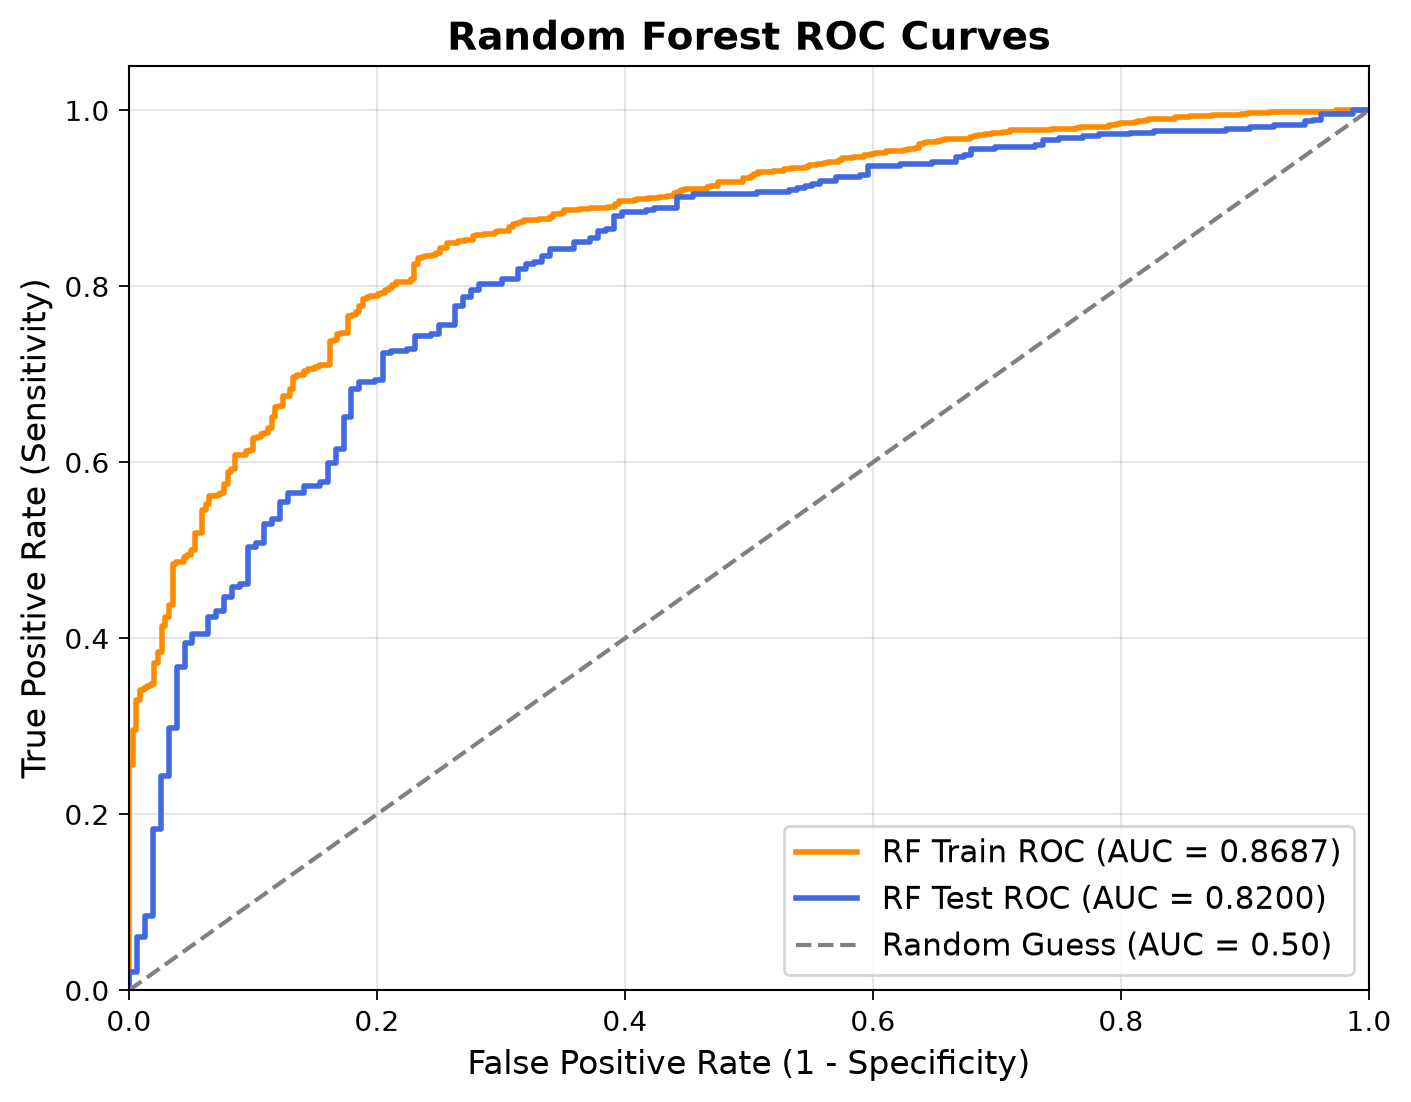

In [13]:
# 1. Regenerate probabilities to ensure they reflect the RF model
rf_pred_train = rf.predict_proba(X_train_encoded)[:, 1]
rf_pred_test = rf.predict_proba(X_test_encoded)[:, 1]

# 2. Calculate ROC curve coordinates
fpr_train, tpr_train, _ = roc_curve(y_train, rf_pred_train)
fpr_test, tpr_test, _ = roc_curve(y_test, rf_pred_test)

# 3. Fetch the exact AUC scores for the legend labels
auc_train = roc_auc_score(y_train, rf_pred_train)
auc_test = roc_auc_score(y_test, rf_pred_test)

# 4. Generate the plot
plt.figure(figsize=(8, 6))
plt.plot(fpr_train, tpr_train, color='darkorange', lw=2, label=f'RF Train ROC (AUC = {auc_train:.4f})')
plt.plot(fpr_test, tpr_test, color='royalblue', lw=2, label=f'RF Test ROC (AUC = {auc_test:.4f})')

# 5. Add baseline random guess line and plot diagrams
plt.plot([0, 1], [0, 1], color='gray', lw=1.5, linestyle='--', label='Random Guess (AUC = 0.50)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12)
plt.title('Random Forest ROC Curves', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.show()

## 3. AdaBoost

In [14]:
# let's load the dataset.

data_ada = load_analysis_data()
data_ada.shape

(2106, 28)

In [15]:
use_cols_ada = PRIMARY_FEATURES.copy()

X_train_ada, X_test_ada, y_train_ada, y_test_ada = train_test_split(
    data_ada[use_cols_ada], 
    data_ada['ArteriovenousFistula'], 
    test_size=0.3, 
    random_state=0
)

X_train_ada.shape, X_test_ada.shape

((1474, 25), (632, 25))

In [16]:
# 1. Fixed AdaBoost settings; the current implementation uses SAMME.
ada = Pipeline([('preprocess', make_preprocessor("AdaBoost")),
                ('model', AdaBoostClassifier(n_estimators=200, random_state=39))])

# 2. Train the model on the training data
ada.fit(X_train_ada, y_train_ada)

# 3. Make predictions
pred_train_ada = ada.predict_proba(X_train_ada)
pred_test_ada = ada.predict_proba(X_test_ada)

# 4. Print results
print('Train set')
print('AdaBoost roc-auc: {}'.format(roc_auc_score(y_train_ada, pred_train_ada[:, 1])))
print('Test set')
print('AdaBoost roc-auc: {}'.format(roc_auc_score(y_test_ada, pred_test_ada[:, 1])))


Train set
AdaBoost roc-auc: 0.798697906514366
Test set
AdaBoost roc-auc: 0.8046353156647275


In [17]:
# 1. Regenerate the correct AdaBoost probabilities
ada_pred_train = ada.predict_proba(X_train_ada)
ada_pred_test = ada.predict_proba(X_test_ada)

# 2. Generate hard binary predictions (0 or 1) using the standard 0.5 threshold
y_pred_train_ada = (ada_pred_train[:, 1] >= 0.5).astype(int)
y_pred_test_ada = (ada_pred_test[:, 1] >= 0.5).astype(int)

ada_train_f1 = f1_score(y_train_ada, y_pred_train_ada)
ada_test_f1 = f1_score(y_test_ada, y_pred_test_ada)

# 3. Create function to calculate the 95% Confidence Interval for AUC
def calculate_auc_ci(y_true, y_probs, seed=20260915, n_iterations=2000):
    # Same patient resamples across models; intervals condition on fitted predictions.
    rng = np.random.default_rng(seed)
    yy = np.asarray(y_true)
    pp = np.asarray(y_probs)
    scores = []
    for _ in range(n_iterations):
        ids = rng.integers(0, len(yy), len(yy))
        if len(np.unique(yy[ids])) == 2:
            scores.append(roc_auc_score(yy[ids], pp[ids]))
    return tuple(np.quantile(scores, [0.025, 0.975]))

# 4. Compute CIs
train_lower, train_upper = calculate_auc_ci(y_train_ada, ada_pred_train[:, 1])
test_lower, test_upper = calculate_auc_ci(y_test_ada, ada_pred_test[:, 1])

# 5. Print the AdaBoost metrics
print('AdaBoost Train Evaluation ')
print('AdaBoost Train F1-Score: {:.4f}'.format(ada_train_f1))
print('AdaBoost Train ROC-AUC: {:.4f}'.format(roc_auc_score(y_train_ada, ada_pred_train[:, 1])))
print('Train AUC 95% Confidence Interval: [{:.4f} to {:.4f}]'.format(train_lower, train_upper))
print()
print('AdaBoost Test (Validation) Evaluation ')
print('AdaBoost Test F1-Score: {:.4f}'.format(ada_test_f1))
print('AdaBoost Test ROC-AUC: {:.4f}'.format(roc_auc_score(y_test_ada, ada_pred_test[:, 1])))
print('Test AUC 95% Confidence Interval: [{:.4f} to {:.4f}]'.format(test_lower, test_upper))

AdaBoost Train Evaluation 
AdaBoost Train F1-Score: 0.8721
AdaBoost Train ROC-AUC: 0.7987
Train AUC 95% Confidence Interval: [0.7730 to 0.8231]

AdaBoost Test (Validation) Evaluation 
AdaBoost Test F1-Score: 0.8695
AdaBoost Test ROC-AUC: 0.8046
Test AUC 95% Confidence Interval: [0.7620 to 0.8446]


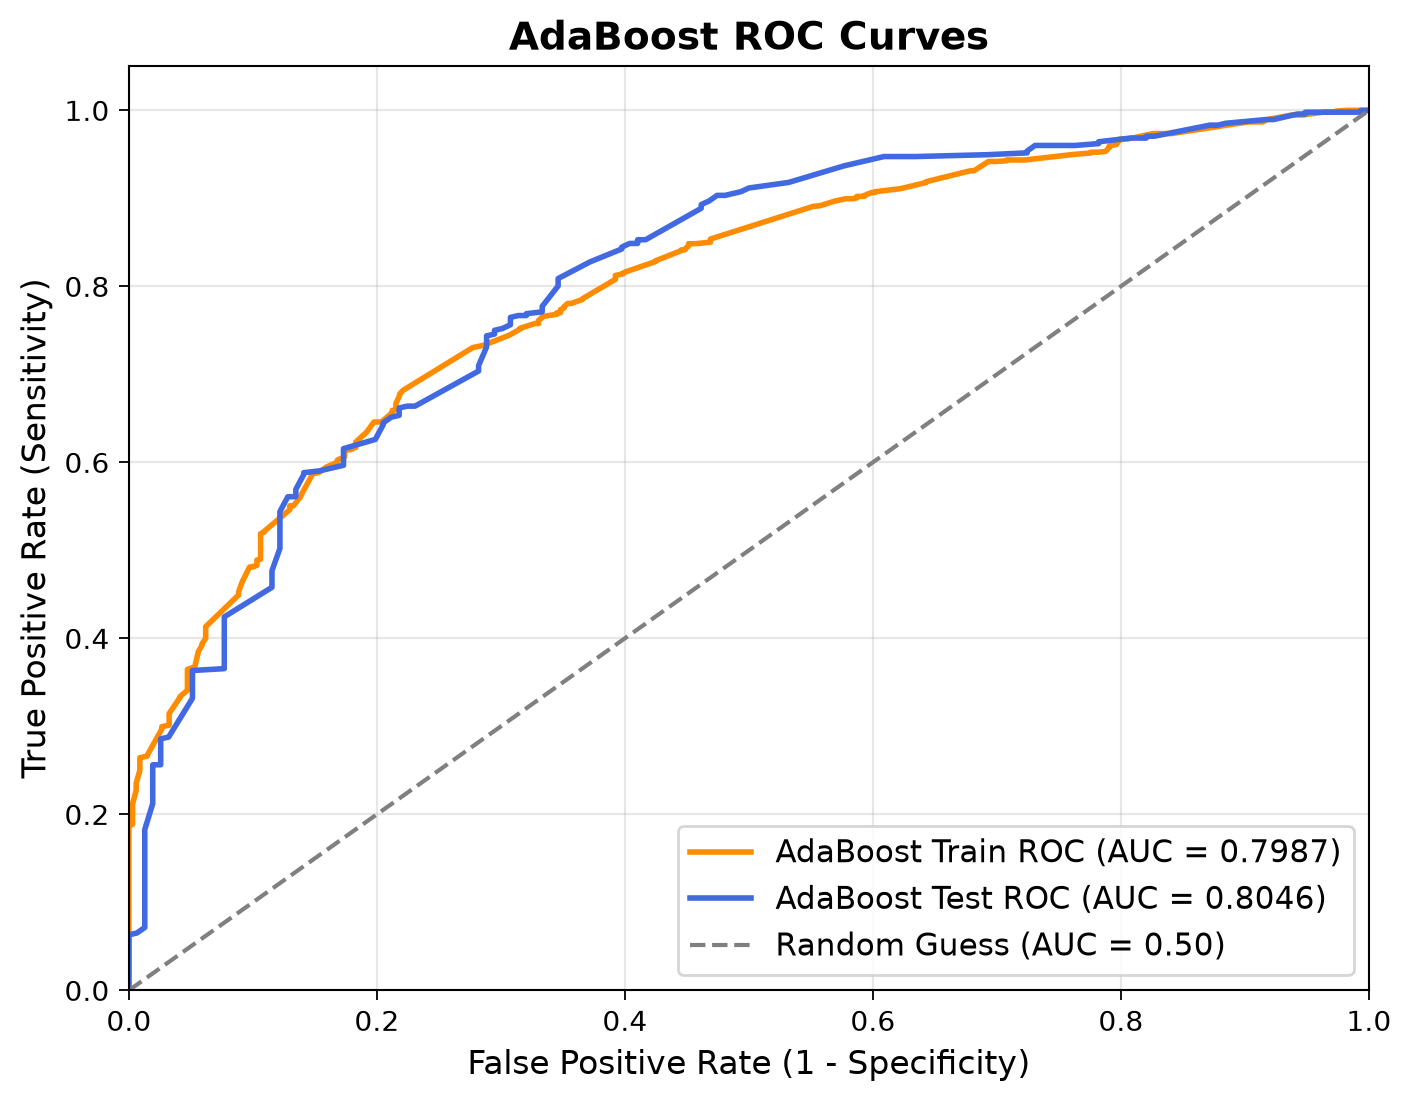

In [18]:
# 1. Regenerate probabilities to ensure they reflect the AdaBoost model
ada_pred_train = ada.predict_proba(X_train_ada)[:, 1]
ada_pred_test = ada.predict_proba(X_test_ada)[:, 1]

# 2. Calculate ROC curve coordinates
fpr_train, tpr_train, _ = roc_curve(y_train_ada, ada_pred_train)
fpr_test, tpr_test, _ = roc_curve(y_test_ada, ada_pred_test)

# 3. Fetch the exact AUC scores for the legend labels
auc_train = roc_auc_score(y_train_ada, ada_pred_train)
auc_test = roc_auc_score(y_test_ada, ada_pred_test)

# 4. Generate the plot
plt.figure(figsize=(8, 6))
plt.plot(fpr_train, tpr_train, color='darkorange', lw=2, label=f'AdaBoost Train ROC (AUC = {auc_train:.4f})')
plt.plot(fpr_test, tpr_test, color='royalblue', lw=2, label=f'AdaBoost Test ROC (AUC = {auc_test:.4f})')

# 5. Add baseline random guess line and plot diagrams
plt.plot([0, 1], [0, 1], color='gray', lw=1.5, linestyle='--', label='Random Guess (AUC = 0.50)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12)
plt.title('AdaBoost ROC Curves', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.show()

## 4. Logistic Regression

In [19]:
# let's load the  dataset.
data_logit = load_analysis_data()
data_logit.shape

(2106, 28)

In [20]:
use_cols_logit = PRIMARY_FEATURES.copy()

X_train_logit, X_test_logit, y_train_logit, y_test_logit = train_test_split(
    data_logit[use_cols_logit], 
    data_logit['ArteriovenousFistula'], 
    test_size=0.3, 
    random_state=0
)

X_train_logit.shape, X_test_logit.shape

((1474, 25), (632, 25))

In [21]:
# 1. Create a pipeline that scales the data first, then applies logit
logit = Pipeline([
    ('preprocess', make_preprocessor("Logit")),
    ('model', LogisticRegression(
        C=1,
        random_state=39,
        max_iter=3000,
    ))
])

# 2. Train the pipeline on  encoded training features
logit.fit(X_train_logit, y_train_logit)

# 3. Generate risk probabilities for both sets using the pipeline
pred_train = logit.predict_proba(X_train_logit)
pred_test = logit.predict_proba(X_test_logit)

# 4. Print clean performance metrics
print('Train set')
print('Logit roc-auc: {:.4f}'.format(roc_auc_score(y_train_logit, pred_train[:, 1])))
print('Test set')
print('Logit roc-auc: {:.4f}'.format(roc_auc_score(y_test_logit, pred_test[:, 1])))


Train set
Logit roc-auc: 0.7945
Test set
Logit roc-auc: 0.8159


In [22]:
# 1. Generate risk probabilities using trained Logit pipeline
logit_pred_train = logit.predict_proba(X_train_logit)
logit_pred_test = logit.predict_proba(X_test_logit)

# 2. Generate hard binary predictions (0 or 1) using the standard 0.5 threshold
y_pred_train_logit = (logit_pred_train[:, 1] >= 0.5).astype(int)
y_pred_test_logit = (logit_pred_test[:, 1] >= 0.5).astype(int)

logit_train_f1 = f1_score(y_train_logit, y_pred_train_logit)
logit_test_f1 = f1_score(y_test_logit, y_pred_test_logit)

# 3. Create function to calculate the 95% Confidence Interval for AUC
def calculate_auc_ci(y_true, y_probs, seed=20260915, n_iterations=2000):
    # Same patient resamples across models; intervals condition on fitted predictions.
    rng = np.random.default_rng(seed)
    yy = np.asarray(y_true)
    pp = np.asarray(y_probs)
    scores = []
    for _ in range(n_iterations):
        ids = rng.integers(0, len(yy), len(yy))
        if len(np.unique(yy[ids])) == 2:
            scores.append(roc_auc_score(yy[ids], pp[ids]))
    return tuple(np.quantile(scores, [0.025, 0.975]))

# 4. Compute CIs 
train_lower, train_upper = calculate_auc_ci(y_train_logit, logit_pred_train[:, 1])
test_lower, test_upper = calculate_auc_ci(y_test_logit, logit_pred_test[:, 1])

# 5. Print the formatted Logit metrics
print('Logit Train Evaluation ')
print('Logit Train F1-Score: {:.4f}'.format(logit_train_f1))
print('Logit Train ROC-AUC: {:.4f}'.format(roc_auc_score(y_train_logit, logit_pred_train[:, 1])))
print('Train AUC 95% Confidence Interval: [{:.4f} to {:.4f}]'.format(train_lower, train_upper))
print()
print('Logit Test (Validation) Evaluation ')
print('Logit Test F1-Score: {:.4f}'.format(logit_test_f1))
print('Logit Test ROC-AUC: {:.4f}'.format(roc_auc_score(y_test_logit, logit_pred_test[:, 1])))
print('Test AUC 95% Confidence Interval: [{:.4f} to {:.4f}]'.format(test_lower, test_upper))

Logit Train Evaluation 
Logit Train F1-Score: 0.8744
Logit Train ROC-AUC: 0.7945
Train AUC 95% Confidence Interval: [0.7687 to 0.8199]

Logit Test (Validation) Evaluation 
Logit Test F1-Score: 0.8656
Logit Test ROC-AUC: 0.8159
Test AUC 95% Confidence Interval: [0.7765 to 0.8534]


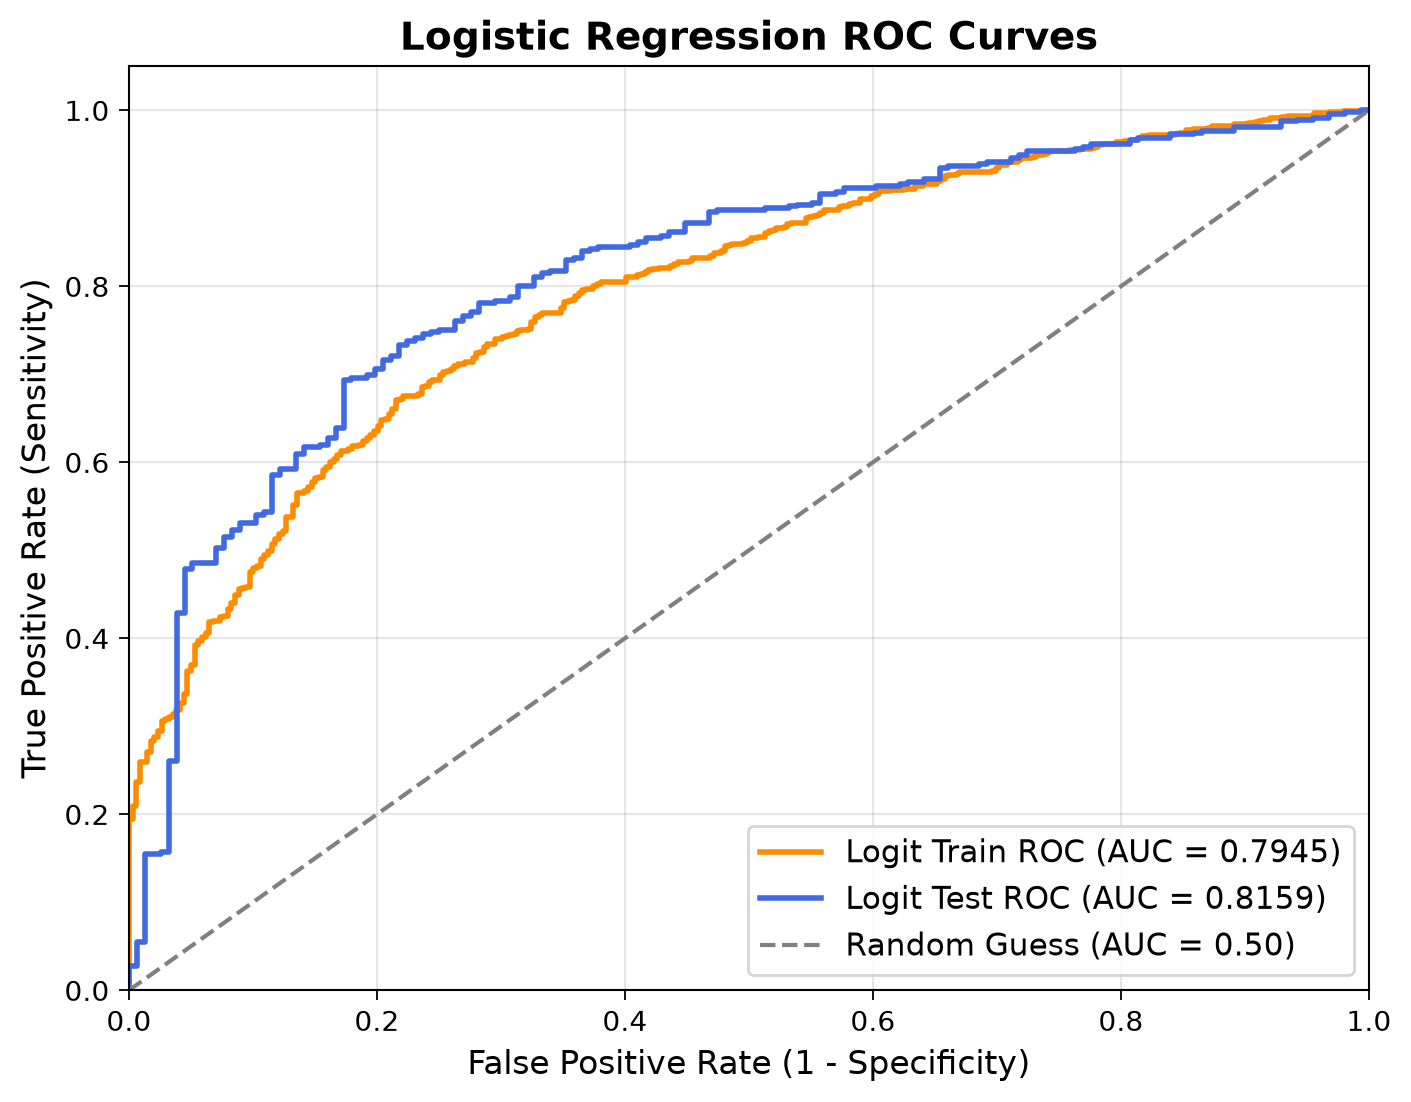

In [23]:
# 1. Generate risk probabilities using trained pipeline (logit)
logit_pred_train = logit.predict_proba(X_train_logit)[:, 1]
logit_pred_test = logit.predict_proba(X_test_logit)[:, 1]

# 2. Calculate ROC curve coordinates
fpr_train, tpr_train, _ = roc_curve(y_train_logit, logit_pred_train)
fpr_test, tpr_test, _ = roc_curve(y_test_logit, logit_pred_test)

# 3. Fetch the exact AUC scores for the legend labels
auc_train = roc_auc_score(y_train_logit, logit_pred_train)
auc_test = roc_auc_score(y_test_logit, logit_pred_test)

# 4. Generate the plot
plt.figure(figsize=(8, 6))
plt.plot(fpr_train, tpr_train, color='darkorange', lw=2, label=f'Logit Train ROC (AUC = {auc_train:.4f})')
plt.plot(fpr_test, tpr_test, color='royalblue', lw=2, label=f'Logit Test ROC (AUC = {auc_test:.4f})')

# 5. Add baseline random guess line and plot diagrams
plt.plot([0, 1], [0, 1], color='gray', lw=1.5, linestyle='--', label='Random Guess (AUC = 0.50)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12)
plt.title('Logistic Regression ROC Curves', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.show()

## 5. XGBoost Classifier

In [24]:
# let's load the dataset.
data_xgb = load_analysis_data()
data_xgb.shape

(2106, 28)

In [25]:
use_cols_xgb = PRIMARY_FEATURES.copy()

X_train_xgb, X_test_xgb, y_train_xgb, y_test_xgb = train_test_split(
    data_xgb[use_cols_xgb], 
    data_xgb['ArteriovenousFistula'], 
    test_size=0.3, 
    random_state=0
)

X_train_xgb.shape, X_test_xgb.shape

((1474, 25), (632, 25))

**XGBoost fitting**

Permutation screening is followed by grouped recursive feature elimination with five-fold cross-validation within the training partition. Final estimator settings are fixed.


In [26]:
# XGBoost pipeline with permutation screening and recursive selection.
pipeline_xgb = Pipeline([
    ('preprocess', make_preprocessor("XGBoost")),
    ('model', XGBClassifier(
        n_estimators=400,
        max_depth=3,
        learning_rate=0.01,
        subsample=0.6,
        colsample_bytree=0.6,
        gamma=2.0,
        reg_alpha=0.5,
        reg_lambda=2.0,
        random_state=39,
        n_jobs=4,
        eval_metric='logloss',
        objective='binary:logistic',
    ))
])
pipeline_xgb.fit(X_train_xgb, y_train_xgb)
train_probs = pipeline_xgb.predict_proba(X_train_xgb)[:, 1]
test_probs = pipeline_xgb.predict_proba(X_test_xgb)[:, 1]
print('Train XGBoost AUC:', roc_auc_score(y_train_xgb, train_probs))
print('Test XGBoost AUC:', roc_auc_score(y_test_xgb, test_probs))


Train XGBoost AUC: 0.8689979597936404
Test XGBoost AUC: 0.8316499676793796


In [27]:
# 1. Generate risk probabilities directly from trained pipeline object
xgb_pred_train = pipeline_xgb.predict_proba(X_train_xgb)[:, 1]
xgb_pred_test = pipeline_xgb.predict_proba(X_test_xgb)[:, 1]

# 2. Compute hard binary predictions (0 or 1) using the standard 0.5 threshold
xgb_y_pred_train = (xgb_pred_train >= 0.5).astype(int)
xgb_y_pred_test = (xgb_pred_test >= 0.5).astype(int)

# 3. Compute base evaluation metrics 
xgb_train_f1 = f1_score(y_train_xgb, xgb_y_pred_train)
xgb_test_f1 = f1_score(y_test_xgb, xgb_y_pred_test)

# 4. Create function to calculate the 95% CI
def calculate_auc_ci(y_true, y_probs, seed=20260915, n_iterations=2000):
    # Same patient resamples across models; intervals condition on fitted predictions.
    rng = np.random.default_rng(seed)
    yy = np.asarray(y_true)
    pp = np.asarray(y_probs)
    scores = []
    for _ in range(n_iterations):
        ids = rng.integers(0, len(yy), len(yy))
        if len(np.unique(yy[ids])) == 2:
            scores.append(roc_auc_score(yy[ids], pp[ids]))
    return tuple(np.quantile(scores, [0.025, 0.975]))

# 5. Run bootstrapping on both the training and testing sets
train_lower, train_upper = calculate_auc_ci(y_train_xgb, xgb_pred_train)
test_lower, test_upper = calculate_auc_ci(y_test_xgb, xgb_pred_test)

# 6. Print out the formal academic evaluation logs
print('XGBoost Train Evaluation ')
print('XGBoost Train F1-Score: {:.4f}'.format(xgb_train_f1))
print('XGBoost Train ROC-AUC: {:.4f}'.format(roc_auc_score(y_train_xgb, xgb_pred_train)))
print('Train AUC 95% Confidence Interval: [{:.4f} to {:.4f}]'.format(train_lower, train_upper))
print()
print('XGBoost Test (Validation) Evaluation ')
print('XGBoost Test F1-Score: {:.4f}'.format(xgb_test_f1))
print('XGBoost Test ROC-AUC: {:.4f}'.format(roc_auc_score(y_test_xgb, xgb_pred_test)))
print('Test AUC 95% Confidence Interval: [{:.4f} to {:.4f}]'.format(test_lower, test_upper))

XGBoost Train Evaluation 
XGBoost Train F1-Score: 0.8933
XGBoost Train ROC-AUC: 0.8690
Train AUC 95% Confidence Interval: [0.8484 to 0.8905]

XGBoost Test (Validation) Evaluation 
XGBoost Test F1-Score: 0.8707
XGBoost Test ROC-AUC: 0.8316
Test AUC 95% Confidence Interval: [0.7932 to 0.8666]


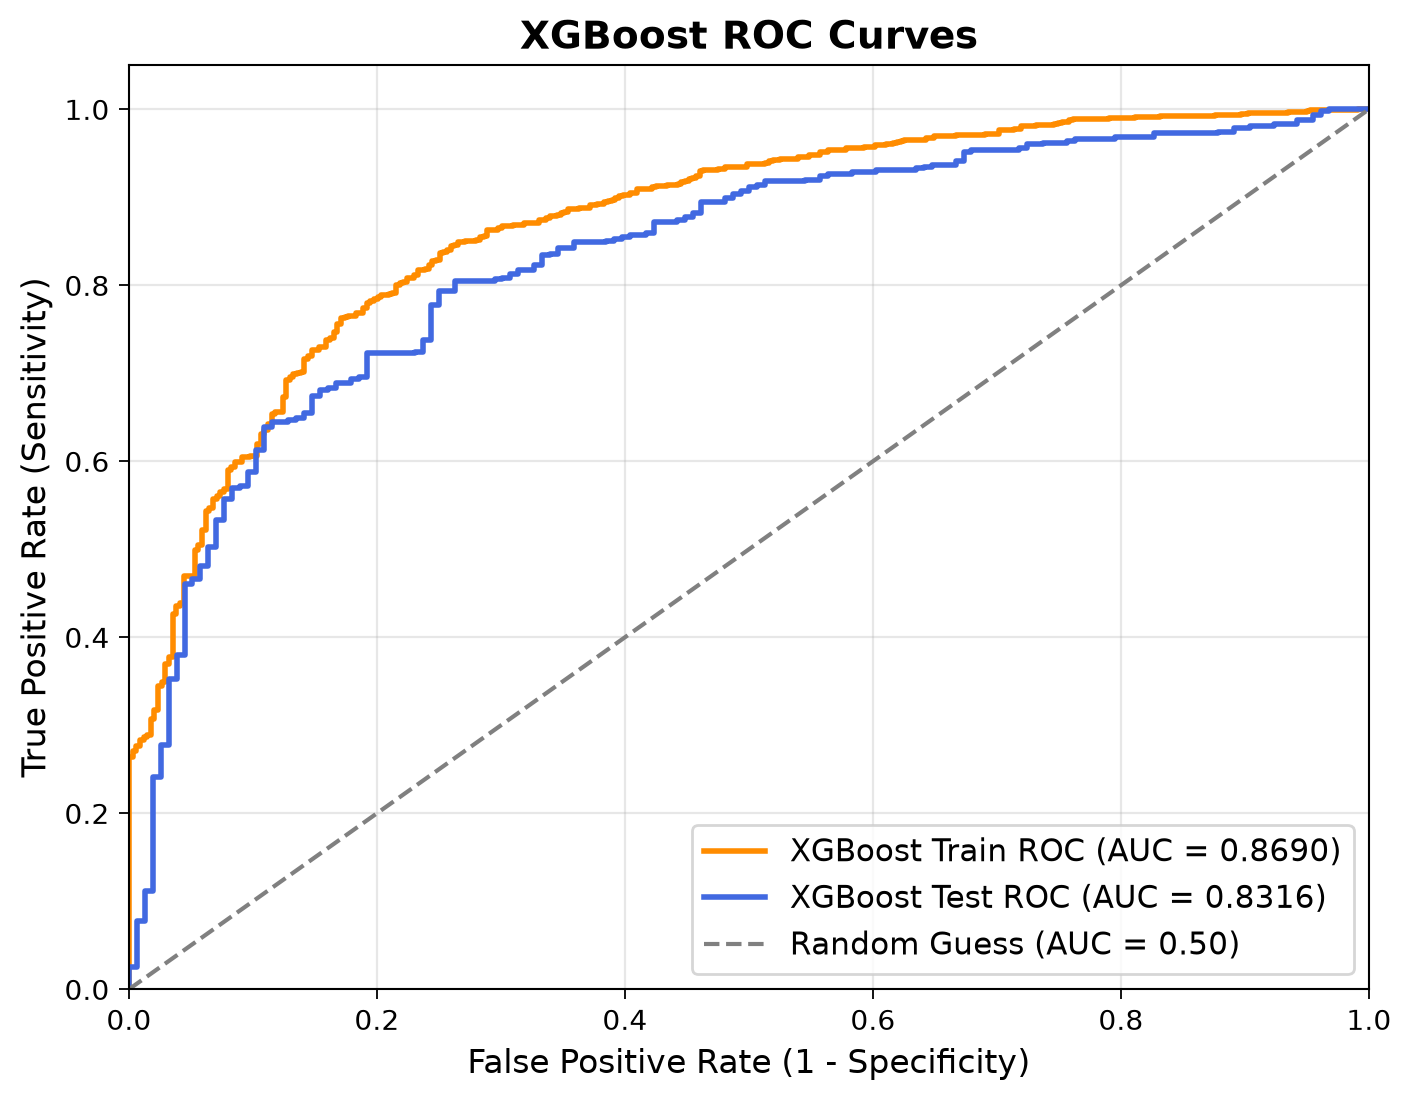

In [28]:
# 1. Generate risk probabilities using trained XGBoost model pipeline
xgb_pred_train = pipeline_xgb.predict_proba(X_train_xgb)[:, 1]
xgb_pred_test = pipeline_xgb.predict_proba(X_test_xgb)[:, 1]

# 2. Calculate ROC curve coordinates
fpr_train, tpr_train, _ = roc_curve(y_train_xgb, xgb_pred_train)
fpr_test, tpr_test, _ = roc_curve(y_test_xgb, xgb_pred_test)

# 3. Fetch the exact AUC scores
auc_train = roc_auc_score(y_train_xgb, xgb_pred_train)
auc_test = roc_auc_score(y_test_xgb, xgb_pred_test)

# 4. Generate the plot
plt.figure(figsize=(8, 6))
plt.plot(fpr_train, tpr_train, color='darkorange', lw=2, label=f'XGBoost Train ROC (AUC = {auc_train:.4f})')
plt.plot(fpr_test, tpr_test, color='royalblue', lw=2, label=f'XGBoost Test ROC (AUC = {auc_test:.4f})')

# 5. Add baseline random guess line and plot diagrams
plt.plot([0, 1], [0, 1], color='gray', lw=1.5, linestyle='--', label='Random Guess (AUC = 0.50)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12)
plt.title('XGBoost ROC Curves', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.show()

## 6. Support Vector Machines

In [29]:
# let's load the dataset.
data_svm = load_analysis_data()
data_svm.shape

(2106, 28)

In [30]:
use_cols_svm = PRIMARY_FEATURES.copy()

X_train_svm, X_test_svm, y_train_svm, y_test_svm = train_test_split(
    data_svm[use_cols_svm], 
    data_svm['ArteriovenousFistula'], 
    test_size=0.3, 
    random_state=0
)

X_train_svm.shape, X_test_svm.shape

((1474, 25), (632, 25))

**Fixed SVM settings and training-only preprocessing**

Permutation screening is followed by ANOVA selection of up to 12 source variables, with categorical indicators retained together. Continuous predictors are scaled; categorical predictors are one-hot encoded.


In [31]:
# SVM pipeline with permutation screening and ANOVA selection.
pipeline_svm = Pipeline([
    ('preprocess', make_preprocessor("SVM")),
    ('model', SVC(
        kernel='rbf',
        C=0.05,
        gamma='scale',
        class_weight='balanced',
        probability=True,
        random_state=39,
    ))
])
pipeline_svm.fit(X_train_svm, y_train_svm)
train_probs = pipeline_svm.predict_proba(X_train_svm)[:, 1]
test_probs = pipeline_svm.predict_proba(X_test_svm)[:, 1]
print('Train SVM AUC:', roc_auc_score(y_train_svm, train_probs))
print('Test SVM AUC:', roc_auc_score(y_test_svm, test_probs))


Train SVM AUC: 0.786512546619365
Test SVM AUC: 0.805887739711269


In [32]:
# 1. Generate probabilities using trained SVM pipeline correctly for both sets
svm_pred_train = pipeline_svm.predict_proba(X_train_svm)[:, 1]
svm_pred_test = pipeline_svm.predict_proba(X_test_svm)[:, 1]

# 2. Generate hard binary predictions (0 or 1) using the standard 0.5 threshold
y_pred_train_svm = (svm_pred_train >= 0.5).astype(int)
y_pred_test_svm = (svm_pred_test >= 0.5).astype(int)

svm_train_f1 = f1_score(y_train_svm, y_pred_train_svm)
svm_test_f1 = f1_score(y_test_svm, y_pred_test_svm)

# 3. Create function to calculate the 95% Confidence Interval for AUC
def calculate_auc_ci(y_true, y_probs, seed=20260915, n_iterations=2000):
    # Same patient resamples across models; intervals condition on fitted predictions.
    rng = np.random.default_rng(seed)
    yy = np.asarray(y_true)
    pp = np.asarray(y_probs)
    scores = []
    for _ in range(n_iterations):
        ids = rng.integers(0, len(yy), len(yy))
        if len(np.unique(yy[ids])) == 2:
            scores.append(roc_auc_score(yy[ids], pp[ids]))
    return tuple(np.quantile(scores, [0.025, 0.975]))

# 4. Compute CIs using the flat SVM probability arrays
train_lower, train_upper = calculate_auc_ci(y_train_svm, svm_pred_train)
test_lower, test_upper = calculate_auc_ci(y_test_svm, svm_pred_test)

# 5. Print the formatted SVM metrics
print('SVM Train Evaluation ')
print('SVM Train F1-Score: {:.4f}'.format(svm_train_f1))
print('SVM Train ROC-AUC: {:.4f}'.format(roc_auc_score(y_train_svm, svm_pred_train)))
print('Train AUC 95% Confidence Interval: [{:.4f} to {:.4f}]'.format(train_lower, train_upper))
print()
print('SVM Test (Validation) Evaluation ')
print('SVM Test F1-Score: {:.4f}'.format(svm_test_f1))
print('SVM Test ROC-AUC: {:.4f}'.format(roc_auc_score(y_test_svm, svm_pred_test)))
print('Test AUC 95% Confidence Interval: [{:.4f} to {:.4f}]'.format(test_lower, test_upper))

SVM Train Evaluation 
SVM Train F1-Score: 0.8783
SVM Train ROC-AUC: 0.7865
Train AUC 95% Confidence Interval: [0.7599 to 0.8137]

SVM Test (Validation) Evaluation 
SVM Test F1-Score: 0.8667
SVM Test ROC-AUC: 0.8059
Test AUC 95% Confidence Interval: [0.7676 to 0.8449]


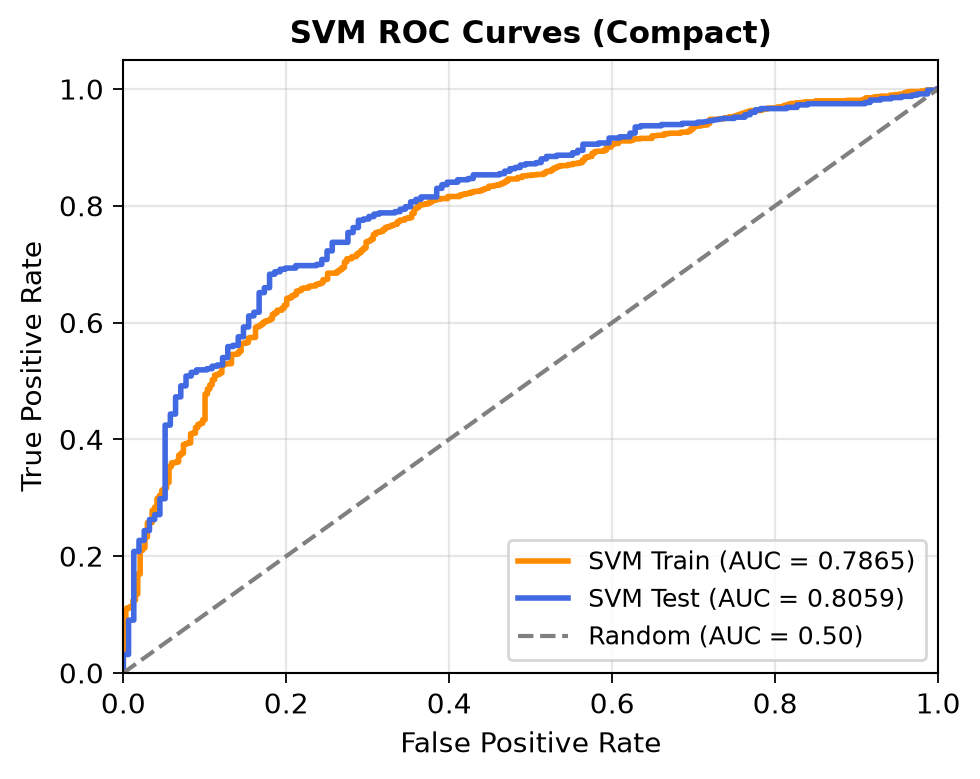

In [33]:
# 1. Generate risk probabilities using trained SVM pipeline
svm_pred_train = pipeline_svm.predict_proba(X_train_svm)[:, 1]
svm_pred_test = pipeline_svm.predict_proba(X_test_svm)[:, 1]

# 2. Calculate ROC curve coordinates
fpr_train, tpr_train, _ = roc_curve(y_train_svm, svm_pred_train)
fpr_test, tpr_test, _ = roc_curve(y_test_svm, svm_pred_test)

# 3. Fetch the exact AUC scoresz
auc_train = roc_auc_score(y_train_svm, svm_pred_train)
auc_test = roc_auc_score(y_test_svm, svm_pred_test)

# 4. Generate the compact plot
plt.figure(figsize=(5, 4)) # <-- Changed from (8, 6) to make it smaller
plt.plot(fpr_train, tpr_train, color='darkorange', lw=2, label=f'SVM Train (AUC = {auc_train:.4f})')
plt.plot(fpr_test, tpr_test, color='royalblue', lw=2, label=f'SVM Test (AUC = {auc_test:.4f})')

# 5. Add baseline random guess line and plot diagrams
plt.plot([0, 1], [0, 1], color='gray', lw=1.5, linestyle='--', label='Random (AUC = 0.50)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=10)
plt.ylabel('True Positive Rate', fontsize=10)
plt.title('SVM ROC Curves (Compact)', fontsize=11, fontweight='bold')
plt.legend(loc="lower right", fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Performance plots

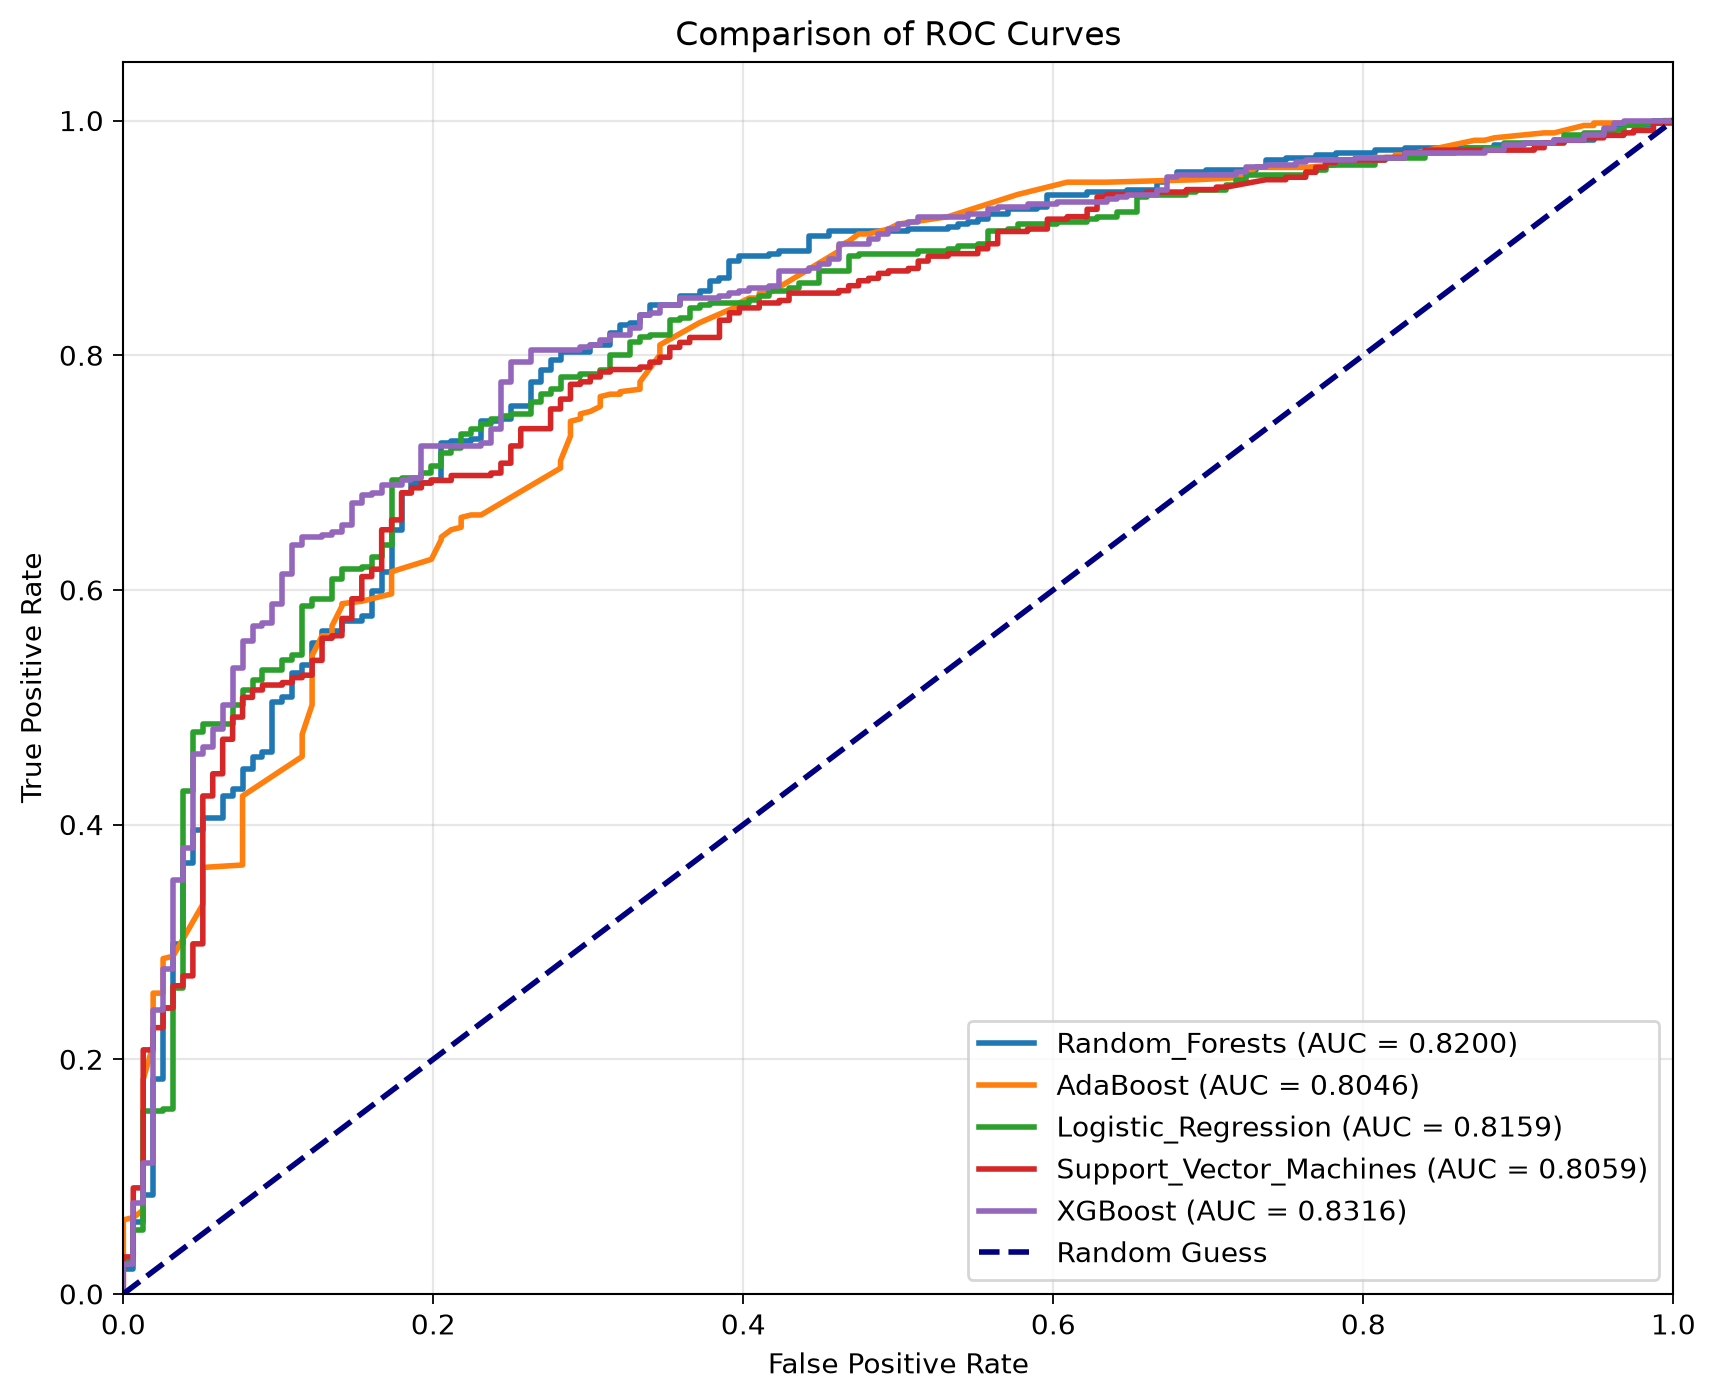

In [34]:
# 1. Map models to their specific required test data
plot_items = [
    {'label': 'Random_Forests', 'model': rf, 'x': X_test_encoded},
    {'label': 'AdaBoost', 'model': ada, 'x': X_test_ada},
    {'label': 'Logistic_Regression', 'model': logit, 'x': X_test_logit},
    {'label': 'Support_Vector_Machines', 'model': pipeline_svm, 'x': X_test_svm},
    {'label': 'XGBoost', 'model': pipeline_xgb, 'x': X_test_xgb},
]

plt.figure(figsize=(10, 8))

# 2. Loop and Plot
for item in plot_items:
    try:
        # Get probabilities for the positive class
        y_probs = item['model'].predict_proba(item['x'])[:, 1]
        
        # Calculate ROC metrics
        fpr, tpr, _ = roc_curve(y_test, y_probs)
        auc_score = roc_auc_score(y_test, y_probs)
        
        # Add to the plot
        plt.plot(fpr, tpr, lw=2, label=f"{item['label']} (AUC = {auc_score:.4f})")
    except Exception as e:
        print(f"Could not plot {item['label']}: {e}")

# 3. plot digrams
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Comparison of ROC Curves')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

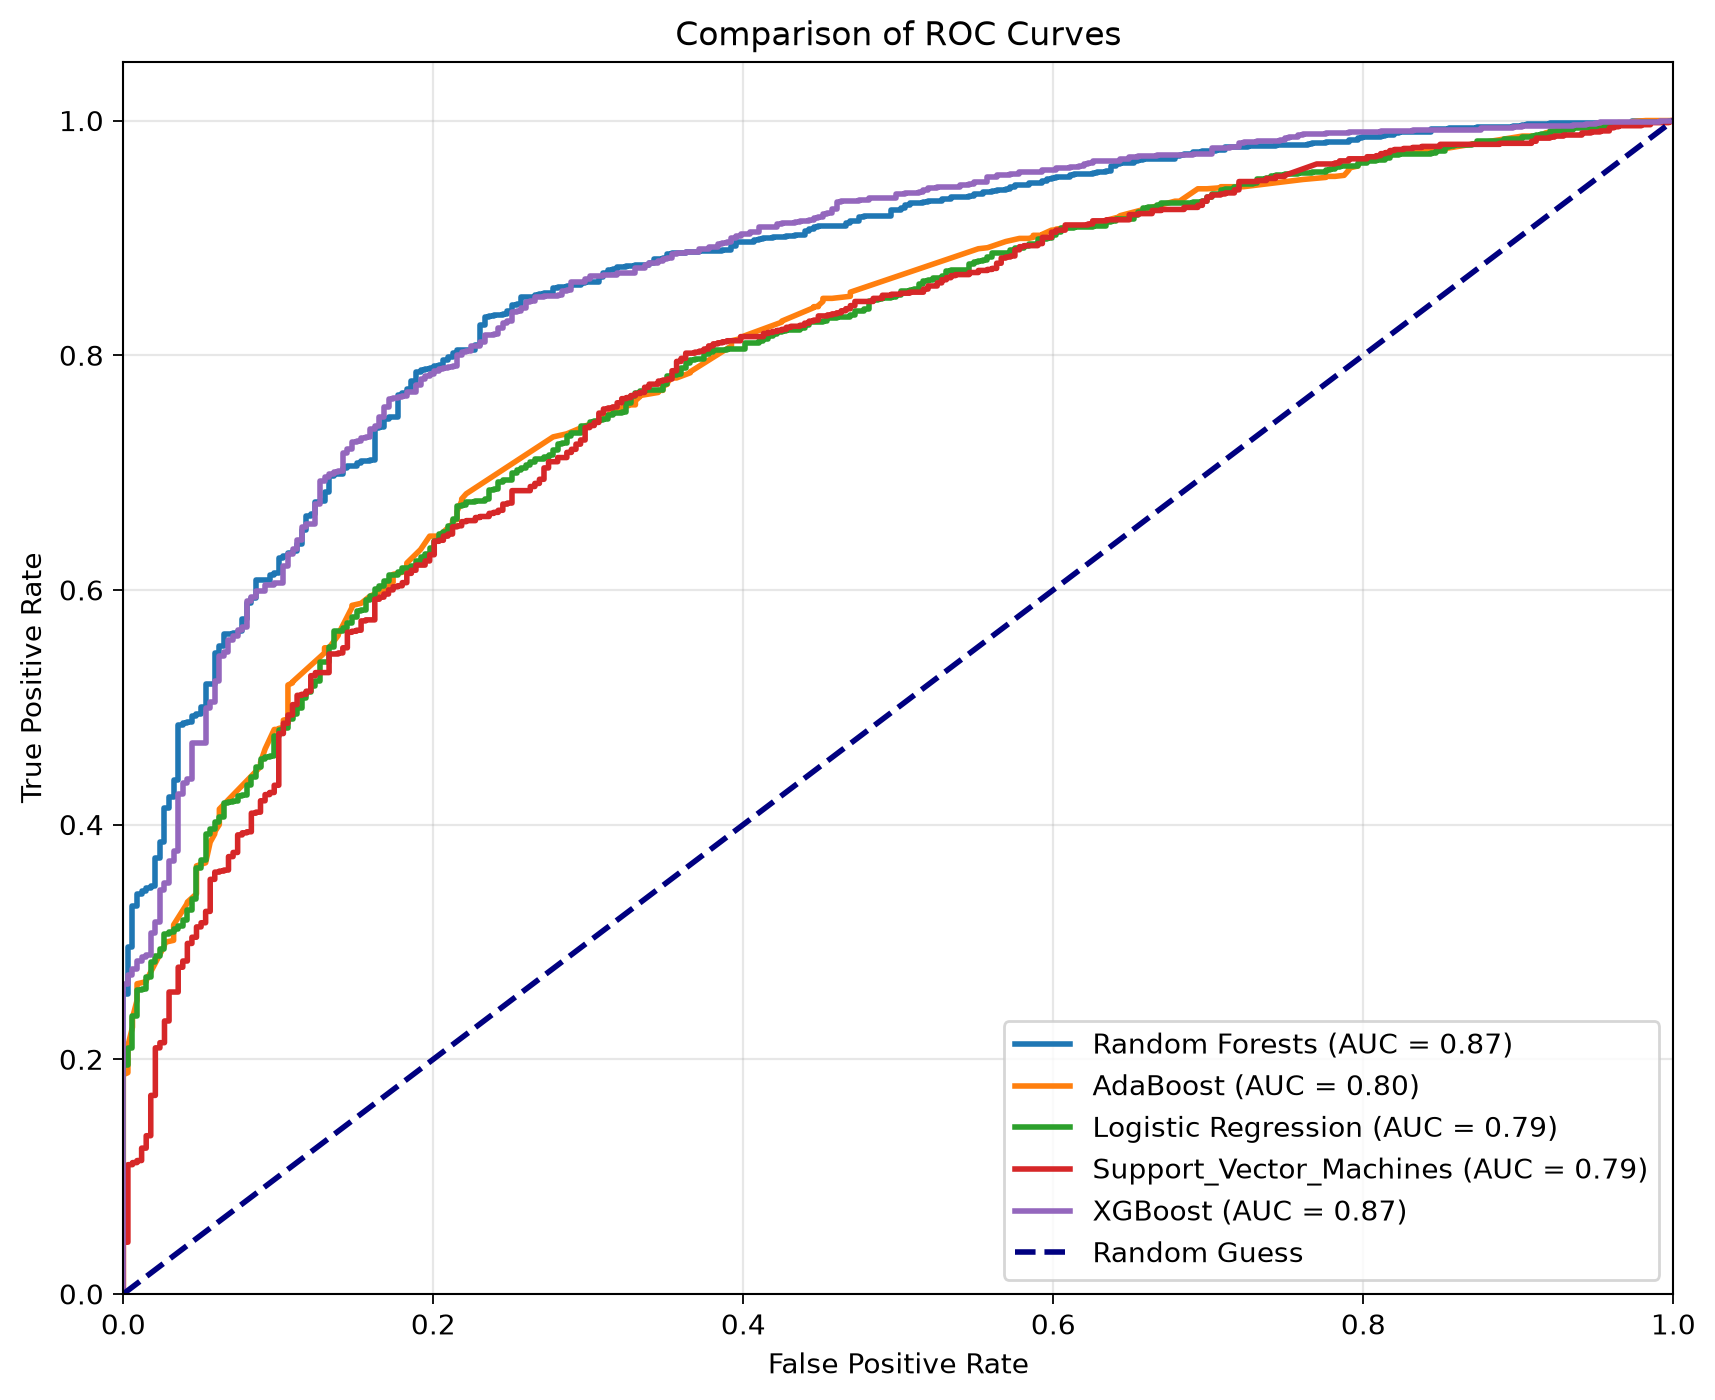

In [35]:
# 1. Map models to their specific required test data
plot_items = [
    {'label': 'Random Forests', 'model': rf, 'x': X_train_encoded},
    {'label': 'AdaBoost', 'model': ada, 'x': X_train_ada},
    {'label': 'Logistic Regression', 'model': logit, 'x': X_train_logit},
    {'label': 'Support_Vector_Machines', 'model': pipeline_svm, 'x': X_train_svm},
    {'label': 'XGBoost', 'model': pipeline_xgb, 'x': X_train_xgb}
]

plt.figure(figsize=(10, 8))

# 2. Loop and Plot
for item in plot_items:
    try:
        # Get probabilities for the positive class 
        y_probs = item['model'].predict_proba(item['x'])[:, 1]
        
        # Calculate ROC metrics
        fpr, tpr, _ = roc_curve(y_train, y_probs)
        auc_score = roc_auc_score(y_train, y_probs)
        
        # Add to the plot
        plt.plot(fpr, tpr, lw=2, label=f"{item['label']} (AUC = {auc_score:.2f})")
    except Exception as e:
        print(f"Could not plot {item['label']}: {e}")

# 3. plot diagrams
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Comparison of ROC Curves')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

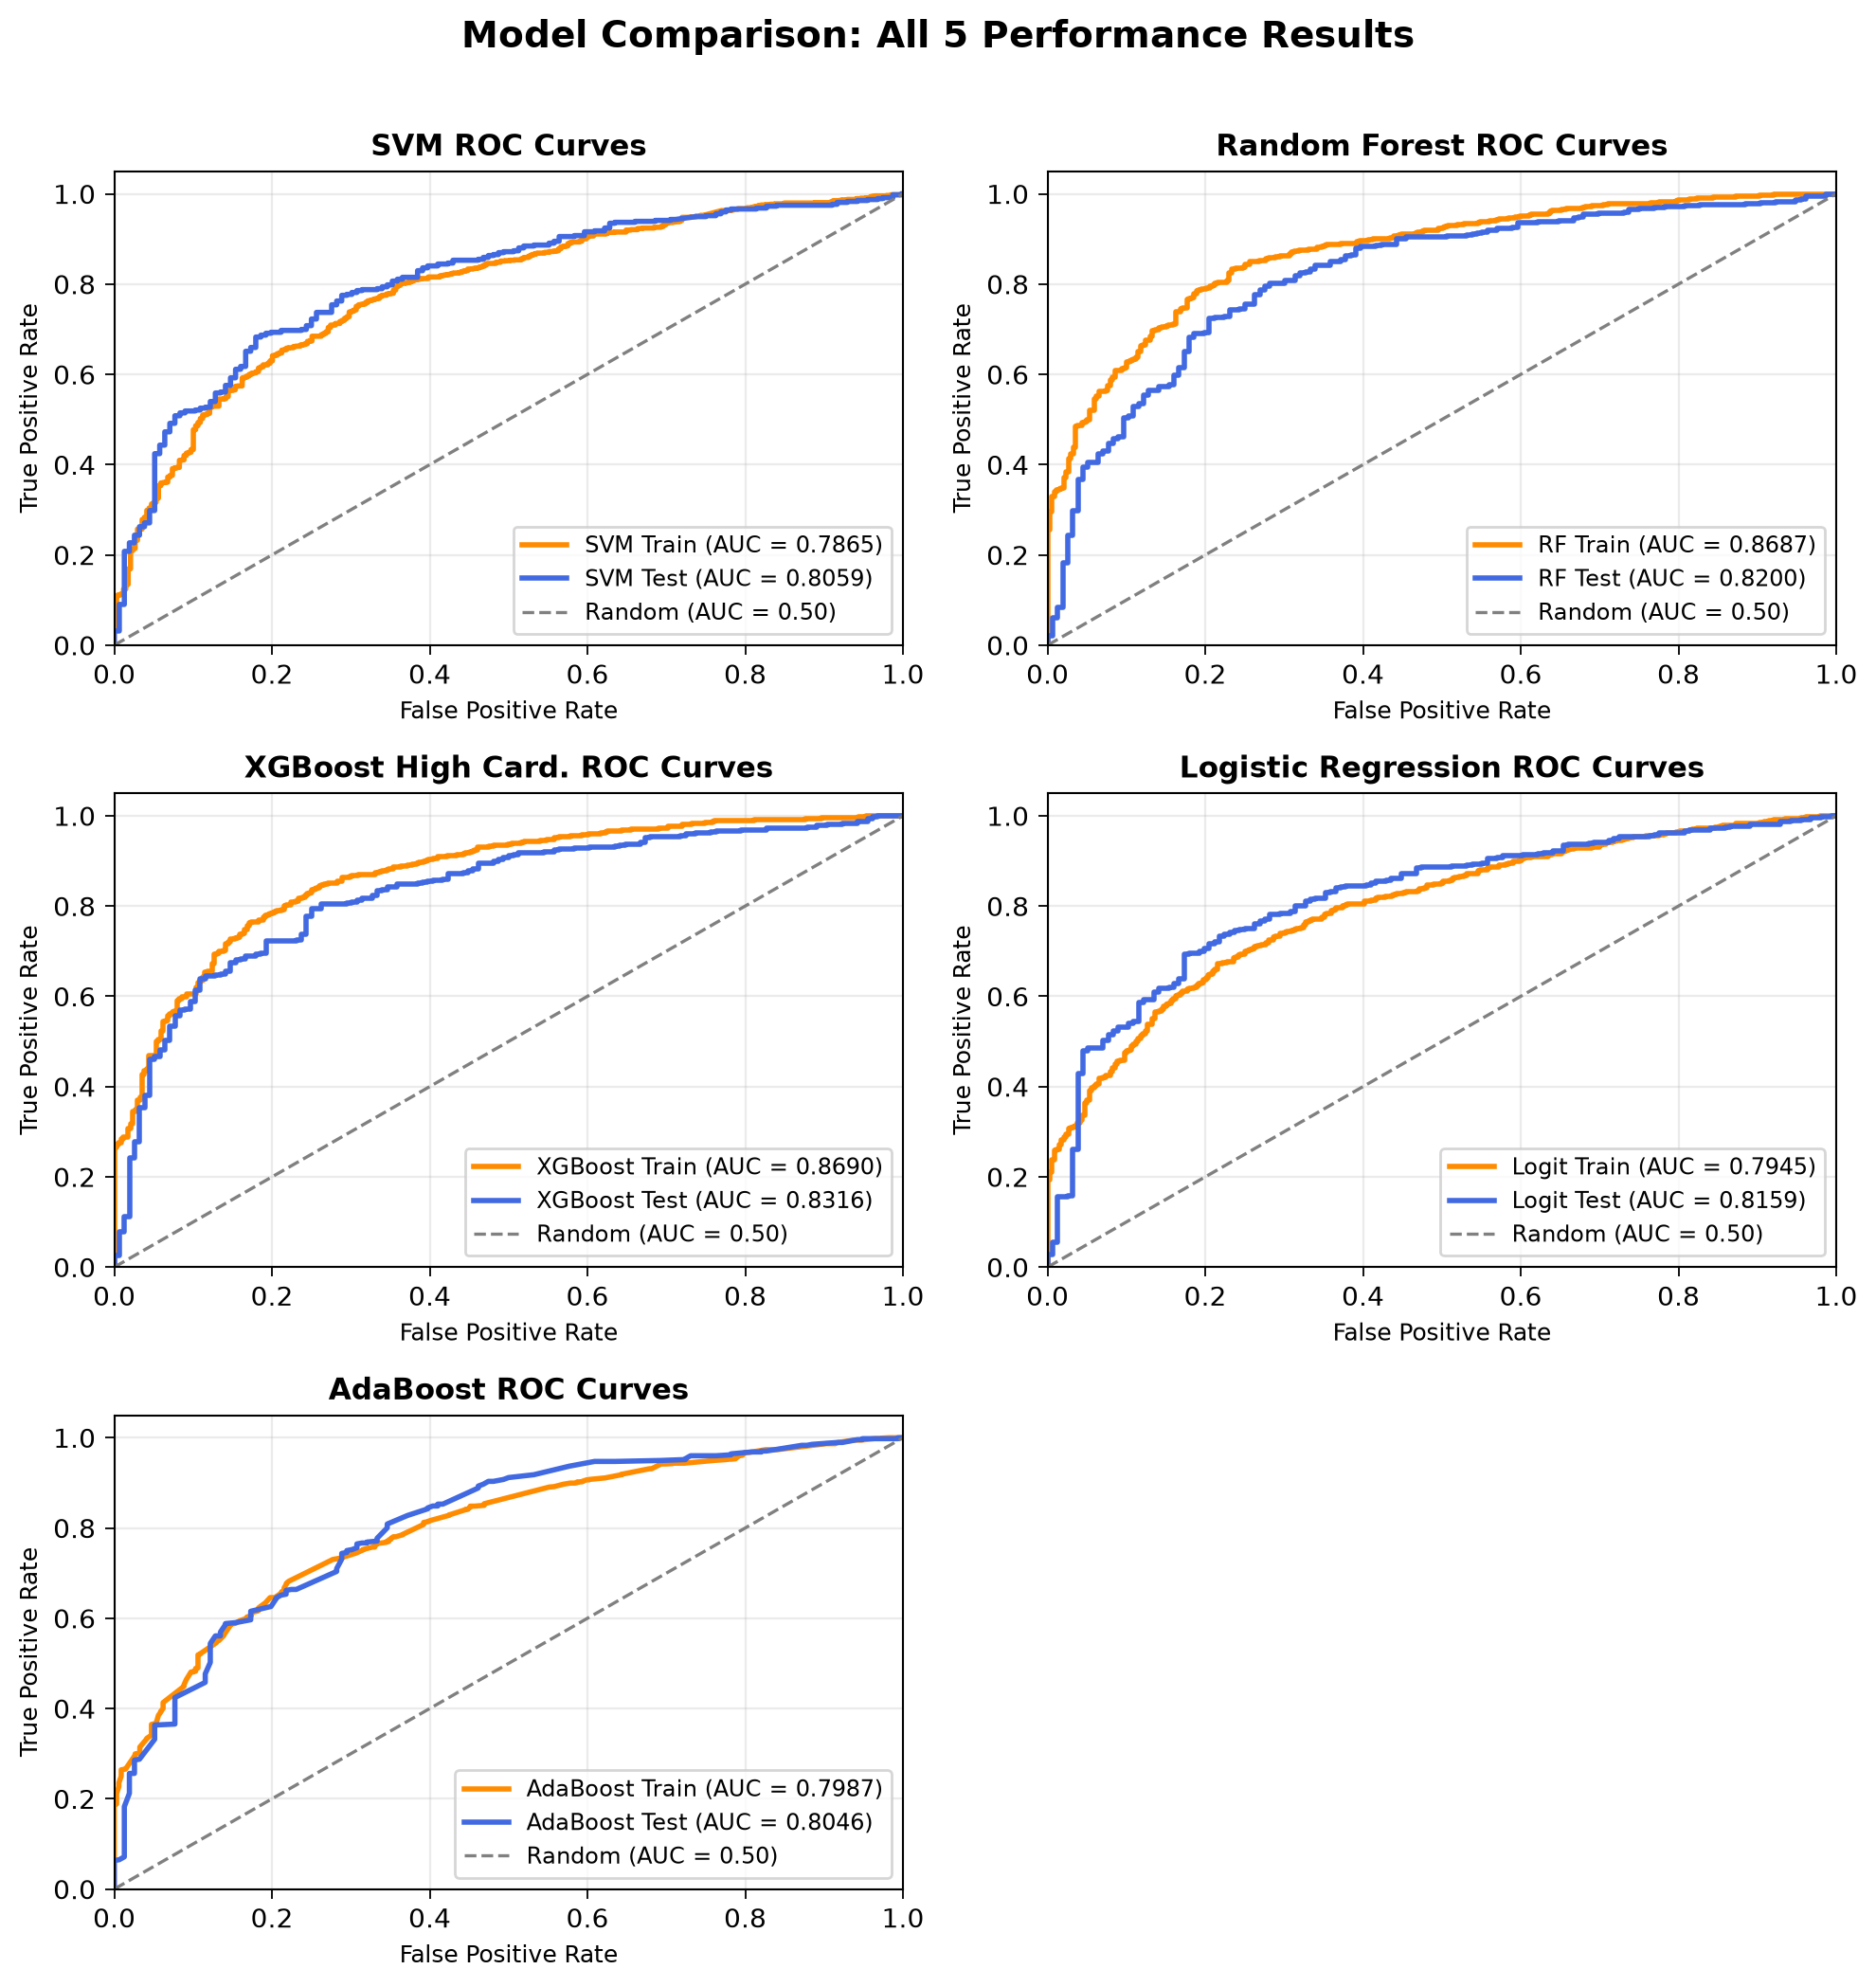

In [36]:
# 1. Generate risk probabilities for all 5 models in the notebook
# Panel 1: Support Vector Machines 
svm_p_train = pipeline_svm.predict_proba(X_train_svm)[:, 1]
svm_p_test = pipeline_svm.predict_proba(X_test_svm)[:, 1]

# Panel 2: Random Forest 
rf_p_train = rf.predict_proba(X_train_encoded)[:, 1]
rf_p_test = rf.predict_proba(X_test_encoded)[:, 1]

# Panel 3: XGBoost 
xgb_p_train = pipeline_xgb.predict_proba(X_train_xgb)[:, 1]
xgb_p_test = pipeline_xgb.predict_proba(X_test_xgb)[:, 1]

# Panel 4: Logit 
logit_p_train = logit.predict_proba(X_train_logit)[:, 1]
logit_p_test = logit.predict_proba(X_test_logit)[:, 1]

# Panel 5: AdaBoost
ada_p_train = ada.predict_proba(X_train_ada)[:, 1]
ada_p_test = ada.predict_proba(X_test_ada)[:, 1]


# 2. Setup a grid layout
fig, axes = plt.subplots(3, 2, figsize=(10, 11))
plt.suptitle('Model Comparison: All 5 Performance Results', fontsize=14, fontweight='bold', y=0.97)

# Configuration mapping array to automatically unpack metrics
plot_configs = [
    {
        'ax': axes[0, 0], 'title': 'SVM ROC Curves',
        'y_tr': y_train_svm, 'p_tr': svm_p_train, 'y_te': y_test_svm, 'p_te': svm_p_test,
        'lbl_tr': 'SVM Train', 'lbl_te': 'SVM Test'
    },
    {
        'ax': axes[0, 1], 'title': 'Random Forest ROC Curves',
        'y_tr': y_train, 'p_tr': rf_p_train, 'y_te': y_test, 'p_te': rf_p_test,
        'lbl_tr': 'RF Train', 'lbl_te': 'RF Test'
    },
    {
        'ax': axes[1, 0], 'title': 'XGBoost High Card. ROC Curves',
        'y_tr': y_train_xgb, 'p_tr': xgb_p_train, 'y_te': y_test_xgb, 'p_te': xgb_p_test,
        'lbl_tr': 'XGBoost Train', 'lbl_te': 'XGBoost Test'
    },
    {
        'ax': axes[1, 1], 'title': 'Logistic Regression ROC Curves',
        'y_tr': y_train_logit, 'p_tr': logit_p_train, 'y_te': y_test_logit, 'p_te': logit_p_test,
        'lbl_tr': 'Logit Train', 'lbl_te': 'Logit Test'
    },
    {
        'ax': axes[2, 0], 'title': 'AdaBoost ROC Curves',
        'y_tr': y_train_ada, 'p_tr': ada_p_train, 'y_te': y_test_ada, 'p_te': ada_p_test,
        'lbl_tr': 'AdaBoost Train', 'lbl_te': 'AdaBoost Test'
    }
]

# 3. Loop through and draw each active model subplot panel
for cfg in plot_configs:
    ax = cfg['ax']
    
    # Calculate coordinates
    fpr_tr, tpr_tr, _ = roc_curve(cfg['y_tr'], cfg['p_tr'])
    fpr_te, tpr_te, _ = roc_curve(cfg['y_te'], cfg['p_te'])
    
    auc_tr = roc_auc_score(cfg['y_tr'], cfg['p_tr'])
    auc_te = roc_auc_score(cfg['y_te'], cfg['p_te'])
    
    # Draw curves
    ax.plot(fpr_tr, tpr_tr, color='darkorange', lw=2, label=f"{cfg['lbl_tr']} (AUC = {auc_tr:.4f})")
    ax.plot(fpr_te, tpr_te, color='royalblue', lw=2, label=f"{cfg['lbl_te']} (AUC = {auc_te:.4f})")
    ax.plot([0, 1], [0, 1], color='gray', lw=1.2, linestyle='--', label='Random (AUC = 0.50)')
    
    # Format current frame boundaries
    ax.set_title(cfg['title'], fontsize=11, fontweight='bold')
    ax.set_xlabel('False Positive Rate', fontsize=9)
    ax.set_ylabel('True Positive Rate', fontsize=9)
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.legend(loc="lower right", fontsize=8.5)
    ax.grid(alpha=0.25)

# 4. Format or hide the remaining empty 6th panel (bottom right slot)
axes[2, 1].axis('off')

# 5. Compile layout safely without compression clipping
plt.tight_layout(rect=[0, 0.02, 1, 0.96])
plt.show()

**F1 scores**

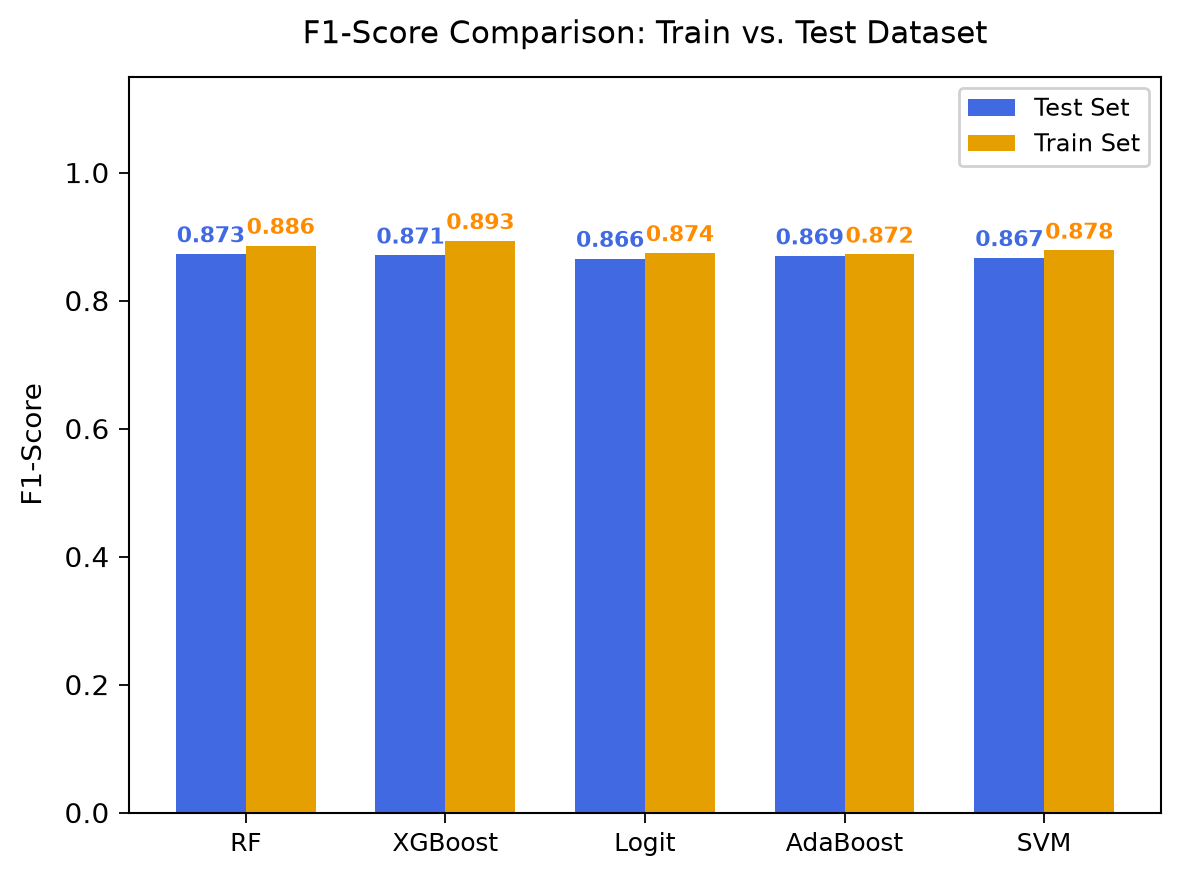

In [37]:
# 1. Aassemble metrics with shortened model names
f1_data = {
    'Model': ['RF', 'XGBoost', 'Logit', 'AdaBoost', 'SVM'],
    'Train F1-Score': [f1_score(y_train, p >= 0.5) for p in [rf_p_train, xgb_p_train, logit_p_train, ada_p_train, svm_p_train]],
    'Test F1-Score': [f1_score(y_test, p >= 0.5) for p in [rf_p_test, xgb_p_test, logit_p_test, ada_p_test, svm_p_test]]
}
df_f1 = pd.DataFrame(f1_data)

# 2. Construct vertical comparison chart
fig, ax = plt.subplots(figsize=(6, 4.5))

x_indices = np.arange(len(df_f1))
bar_width = 0.35

# Generate vertical paired bars
bars_val = ax.bar(x_indices - bar_width/2, df_f1['Test F1-Score'], bar_width, 
                  label='Test Set', color='royalblue')
bars_train = ax.bar(x_indices + bar_width/2, df_f1['Train F1-Score'], bar_width, 
                    label='Train Set', color='#E69F00')

# 3. format axes and labels
ax.set_xticks(x_indices)
ax.set_xticklabels(df_f1['Model'], fontsize=9)

ax.set_ylabel('F1-Score', fontsize=10, labelpad=6)
ax.set_title('F1-Score Comparison: Train vs. Test Dataset', fontsize=11,  pad=12)
ax.set_ylim(0, 1.15)  
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.grid(False)

# Place the legend inside the upper right corner of the diagram
ax.legend(loc='upper right', fontsize=8.5, framealpha=0.9)

# 4. place text labels just above the bars
for bar in bars_train:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.01, f'{height:.3f}', 
            va='bottom', ha='center', color='darkorange', fontsize=8, fontweight='bold')

for bar in bars_val:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.01, f'{height:.3f}', 
            va='bottom', ha='center', color='royalblue', fontsize=8, fontweight='bold')

# plt.savefig('f1.png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

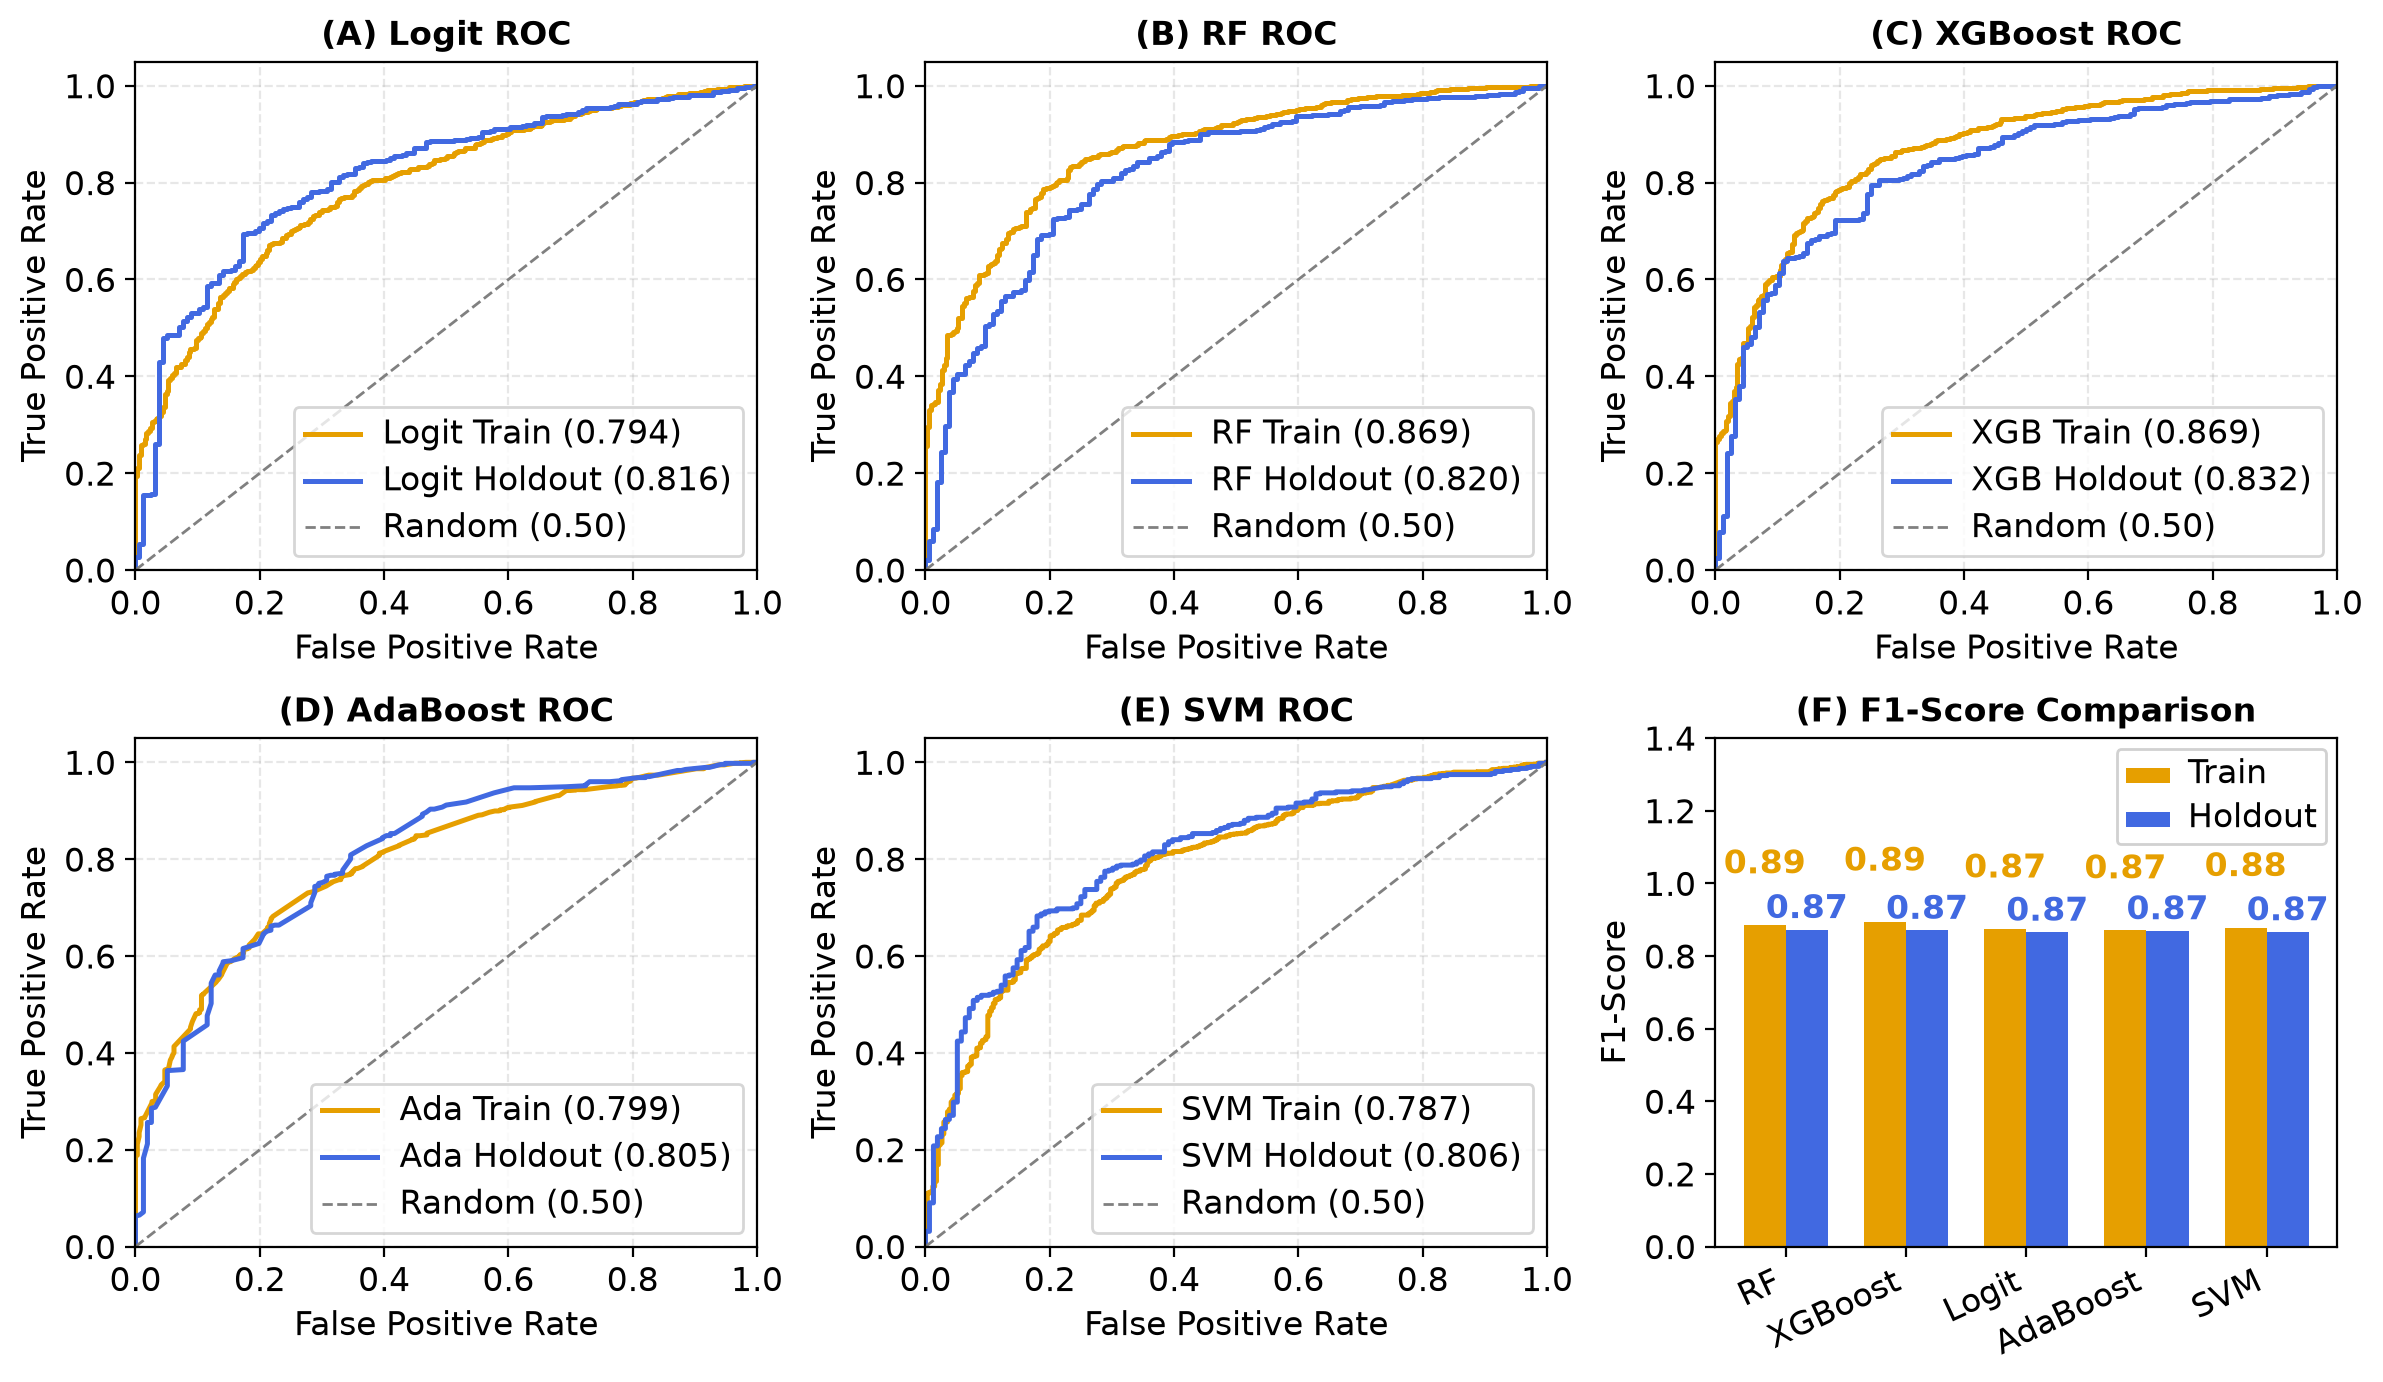

In [38]:
# 1. assemble metrics with shortened model names
f1_data = {
    'Model': ['RF', 'XGBoost', 'Logit', 'AdaBoost', 'SVM'],
    'Train F1-Score': [f1_score(y_train, p >= 0.5) for p in [rf_p_train, xgb_p_train, logit_p_train, ada_p_train, svm_p_train]],
    'Test F1-Score': [f1_score(y_test, p >= 0.5) for p in [rf_p_test, xgb_p_test, logit_p_test, ada_p_test, svm_p_test]]
}
df_f1 = pd.DataFrame(f1_data)

# 2. initial metrics canvas
fig, axes = plt.subplots(2, 3, figsize=(12, 7))

# Flatten the axes array to map configurations line-by-line cleanly
axes_flat = axes.flatten()

# PLOTS 1-5: individual roc
roc_configs = [
    {
        'ax': axes_flat[0], 'title': '(A) Logit ROC',
        'y_tr': y_train_logit, 'p_tr': logit_p_train, 'y_te': y_test_logit, 'p_te': logit_p_test,
        'lbl_tr': 'Logit Train', 'lbl_te': 'Logit Holdout'
    },
    
    {
        'ax': axes_flat[1], 'title': '(B) RF ROC',
        'y_tr': y_train, 'p_tr': rf_p_train, 'y_te': y_test, 'p_te': rf_p_test,
        'lbl_tr': 'RF Train', 'lbl_te': 'RF Holdout'
    },
    {
        'ax': axes_flat[2], 'title': '(C) XGBoost ROC',
        'y_tr': y_train_xgb, 'p_tr': xgb_p_train, 'y_te': y_test_xgb, 'p_te': xgb_p_test,
        'lbl_tr': 'XGB Train', 'lbl_te': 'XGB Holdout'
    },
    
    {
        'ax': axes_flat[3], 'title': '(D) AdaBoost ROC',
        'y_tr': y_train_ada, 'p_tr': ada_p_train, 'y_te': y_test_ada, 'p_te': ada_p_test,
        'lbl_tr': 'Ada Train', 'lbl_te': 'Ada Holdout'
    },
    {
        'ax': axes_flat[4], 'title': '(E) SVM ROC',
        'y_tr': y_train_svm, 'p_tr': svm_p_train, 'y_te': y_test_svm, 'p_te': svm_p_test,
        'lbl_tr': 'SVM Train', 'lbl_te': 'SVM Holdout'
    }
]

# Training and holdout colors
color_train = '#E69F00'  # Vibrant Orange
color_test = 'royalblue'   # Sky Blue

for cfg in roc_configs:
    ax = cfg['ax']
    fpr_tr, tpr_tr, _ = roc_curve(cfg['y_tr'], cfg['p_tr'])
    fpr_te, tpr_te, _ = roc_curve(cfg['y_te'], cfg['p_te'])
    
    auc_tr = roc_auc_score(cfg['y_tr'], cfg['p_tr'])
    auc_te = roc_auc_score(cfg['y_te'], cfg['p_te'])
    
    ax.plot(fpr_tr, tpr_tr, color=color_train, lw=1.8, label=f"{cfg['lbl_tr']} ({auc_tr:.3f})")
    ax.plot(fpr_te, tpr_te, color=color_test, lw=1.8, label=f"{cfg['lbl_te']} ({auc_te:.3f})")
    ax.plot([0, 1], [0, 1], color='gray', lw=1.0, linestyle='--', label='Random (0.50)')
    
    ax.set_title(cfg['title'], fontsize=10, fontweight='bold')
    ax.set_xlabel('False Positive Rate', fontsize=10)
    ax.set_ylabel('True Positive Rate', fontsize=10)
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.legend(loc="lower right", fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.3)

 
# PLOT 6: plot F1-SCORE comparision
ax_f1 = axes_flat[5]
x_indices = np.arange(len(df_f1))
bar_width = 0.35

bars_train = ax_f1.bar(x_indices - bar_width/2, df_f1['Train F1-Score'], bar_width, 
                    label='Train', color=color_train)
bars_val = ax_f1.bar(x_indices + bar_width/2, df_f1['Test F1-Score'], bar_width, 
                  label='Holdout', color=color_test)

ax_f1.set_xticks(x_indices)
ax_f1.set_xticklabels(df_f1['Model'], fontsize=9, rotation=25, ha='right')
ax_f1.set_ylabel('F1-Score', fontsize=10)
ax_f1.set_title('(F) F1-Score Comparison', fontsize=10, fontweight='bold')
ax_f1.set_ylim(0, 1.4)
ax_f1.grid(False)

ax_f1.legend(loc='upper right', fontsize=8, framealpha=0.9)

# Display F1 scores to two decimal places
for bar in bars_train:
    height = bar.get_height()
    ax_f1.text(bar.get_x() + bar.get_width()/2, height + 0.12, f'{height:.2f}', 
            va='bottom', ha='center', color=color_train, fontsize=6, fontweight='bold')

for bar in bars_val:
    height = bar.get_height()
    ax_f1.text(bar.get_x() + bar.get_width()/2, height + 0.01, f'{height:.2f}', 
            va='bottom', ha='center', color=color_test, fontsize=6, fontweight='bold')

# Export the same six-panel figure used in the manuscript.
from matplotlib.text import Text
from PIL import Image as PILImage
figure_dir = RUN_DIR / 'output/publication_figures'
figure_dir.mkdir(exist_ok=True)
export_scale = fig.get_figwidth() / (180 / 25.4)
for text in fig.findobj(Text):
    text.set_fontsize(max(text.get_fontsize(), 7 * export_scale))
for ax in axes_flat:
    for spine in ax.spines.values():
        spine.set_linewidth(0.8)
    ax.tick_params(width=0.8)
plt.tight_layout()
fig.savefig(figure_dir / 'Figure3.png', dpi=400 / export_scale, facecolor='white')
for extension in ['svg']:
    fig.savefig(figure_dir / ('Figure3.' + extension), facecolor='white')
with PILImage.open(figure_dir / 'Figure3.png') as image:
    rgb = image.convert('RGB')
    rgb.save(figure_dir / 'Figure3.png', dpi=(400, 400))
    rgb.save(figure_dir / 'Figure3.tiff', compression='tiff_lzw', dpi=(400, 400))
    rgb.save(figure_dir / 'Figure3.pdf', 'PDF', resolution=400.0)
plt.show()

## 8. Calibration Analysis

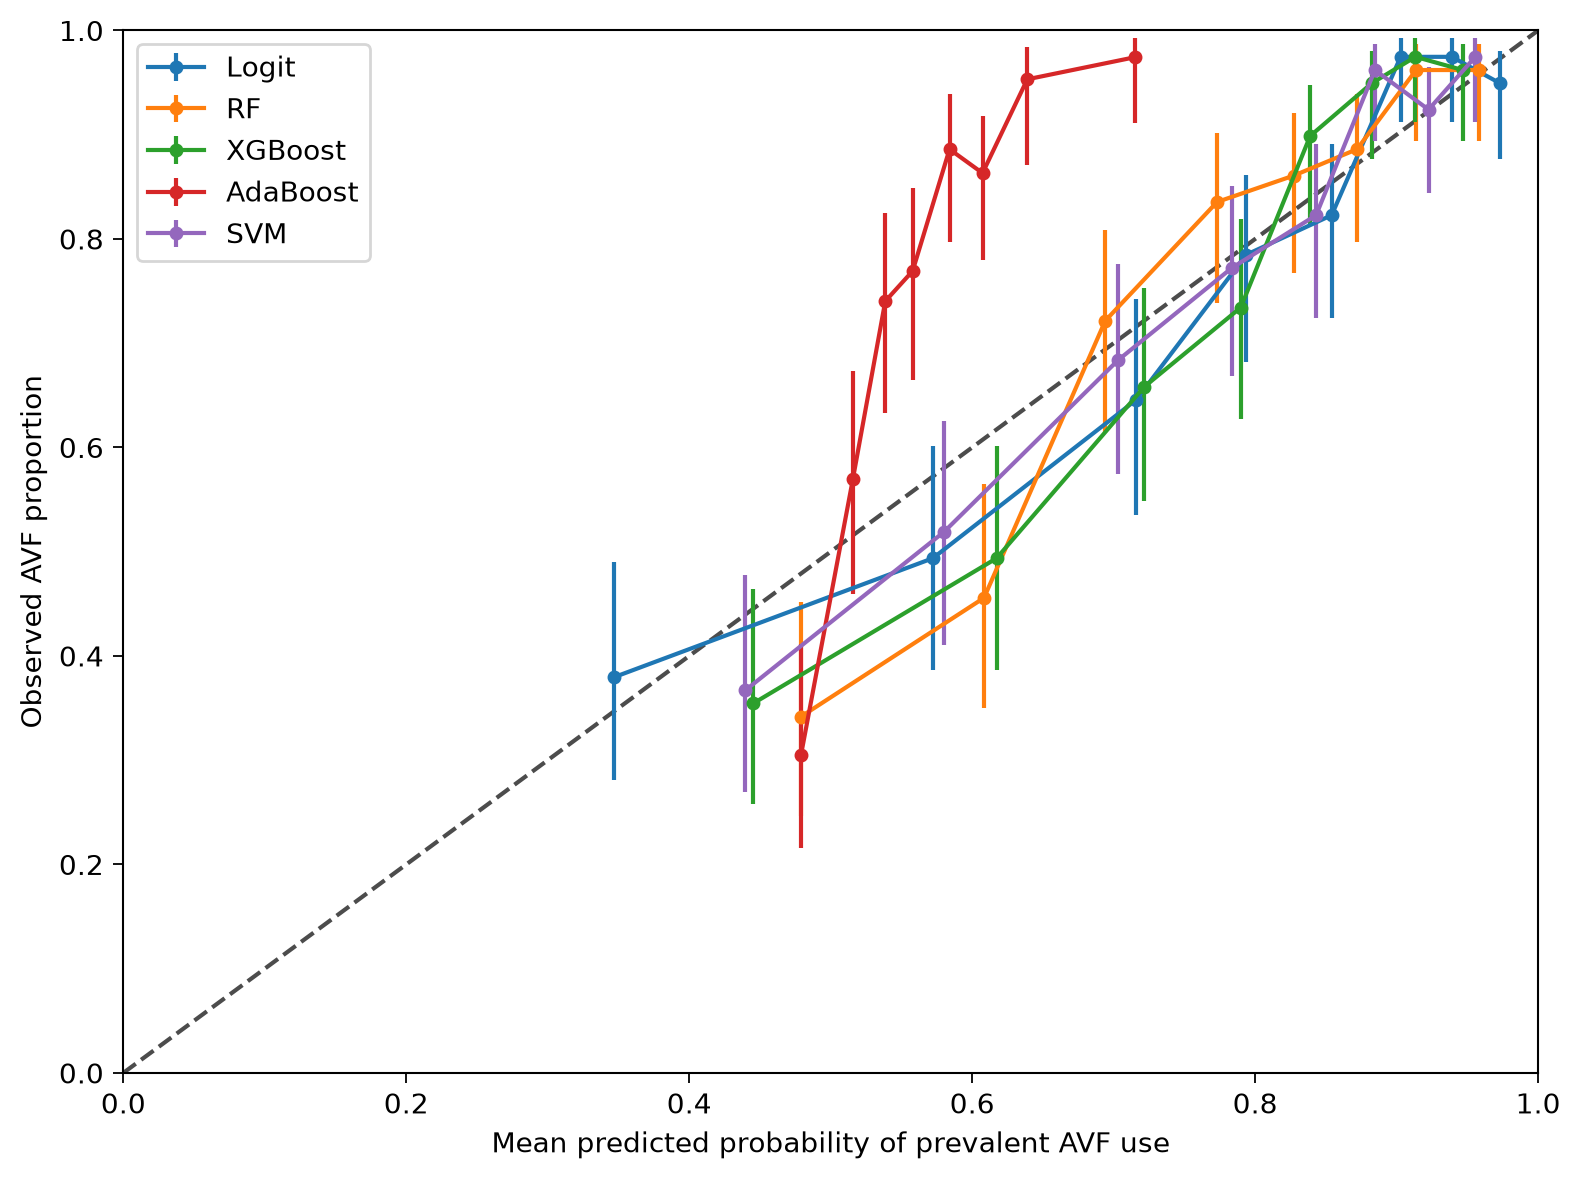

,model,mean_predicted_AVF_probability,observed_AVF_proportion,Brier
0,Logit,0.762208,0.753165,0.143250
1,RF,0.765732,0.753165,0.143081
2,XGBoost,0.769403,0.753165,0.141358
3,AdaBoost,0.578328,0.753165,0.195637
4,SVM,0.764014,0.753165,0.146107


In [39]:
from sklearn.metrics import brier_score_loss

# Collect the five models and their holdout probabilities.
cal_configs = [
    {'probs': logit_p_test, 'label': 'Logit'},
    {'probs': rf_p_test, 'label': 'RF'},
    {'probs': xgb_p_test, 'label': 'XGBoost'},
    {'probs': ada_p_test, 'label': 'AdaBoost'},
    {'probs': svm_p_test, 'label': 'SVM'}
]
fig, ax_cal = plt.subplots(figsize=(8, 6))
ax_cal.plot([0, 1], [0, 1], 'k--', alpha=0.7)
mean_probability_rows = []
for config in cal_configs:
    pp = config['probs']
    df_bin = pd.DataFrame({'y_true': np.asarray(y_test), 'y_prob': pp,
                           'bin': pd.qcut(pp, 8, duplicates='drop')})
    bin_stats = df_bin.groupby('bin', observed=True).agg(
        mean_prob=('y_prob', 'mean'), frac_pos=('y_true', 'mean'), n=('y_true', 'size'))
    # Wilson 95% intervals for each group's observed AVF proportion.
    z = 1.96
    n = bin_stats.n
    q = bin_stats.frac_pos
    den = 1 + z * z / n
    center = (q + z * z / (2 * n)) / den
    half = z * np.sqrt(q * (1 - q) / n + z * z / (4 * n * n)) / den
    ax_cal.errorbar(bin_stats.mean_prob, q, yerr=[q - center + half, center + half - q],
                    fmt='o-', label=config['label'], linewidth=1.5, markersize=4)
    mean_probability_rows.append({'model': config['label'],
                                  'mean_predicted_AVF_probability': float(np.mean(pp)),
                                  'observed_AVF_proportion': float(np.mean(y_test)),
                                  'Brier': brier_score_loss(y_test, pp)})
ax_cal.set_xlabel('Mean predicted probability of prevalent AVF use')
ax_cal.set_ylabel('Observed AVF proportion')
ax_cal.set_xlim(0, 1)
ax_cal.set_ylim(0, 1)
ax_cal.legend(loc='upper left')
plt.tight_layout()
plt.show()
display(pd.DataFrame(mean_probability_rows))


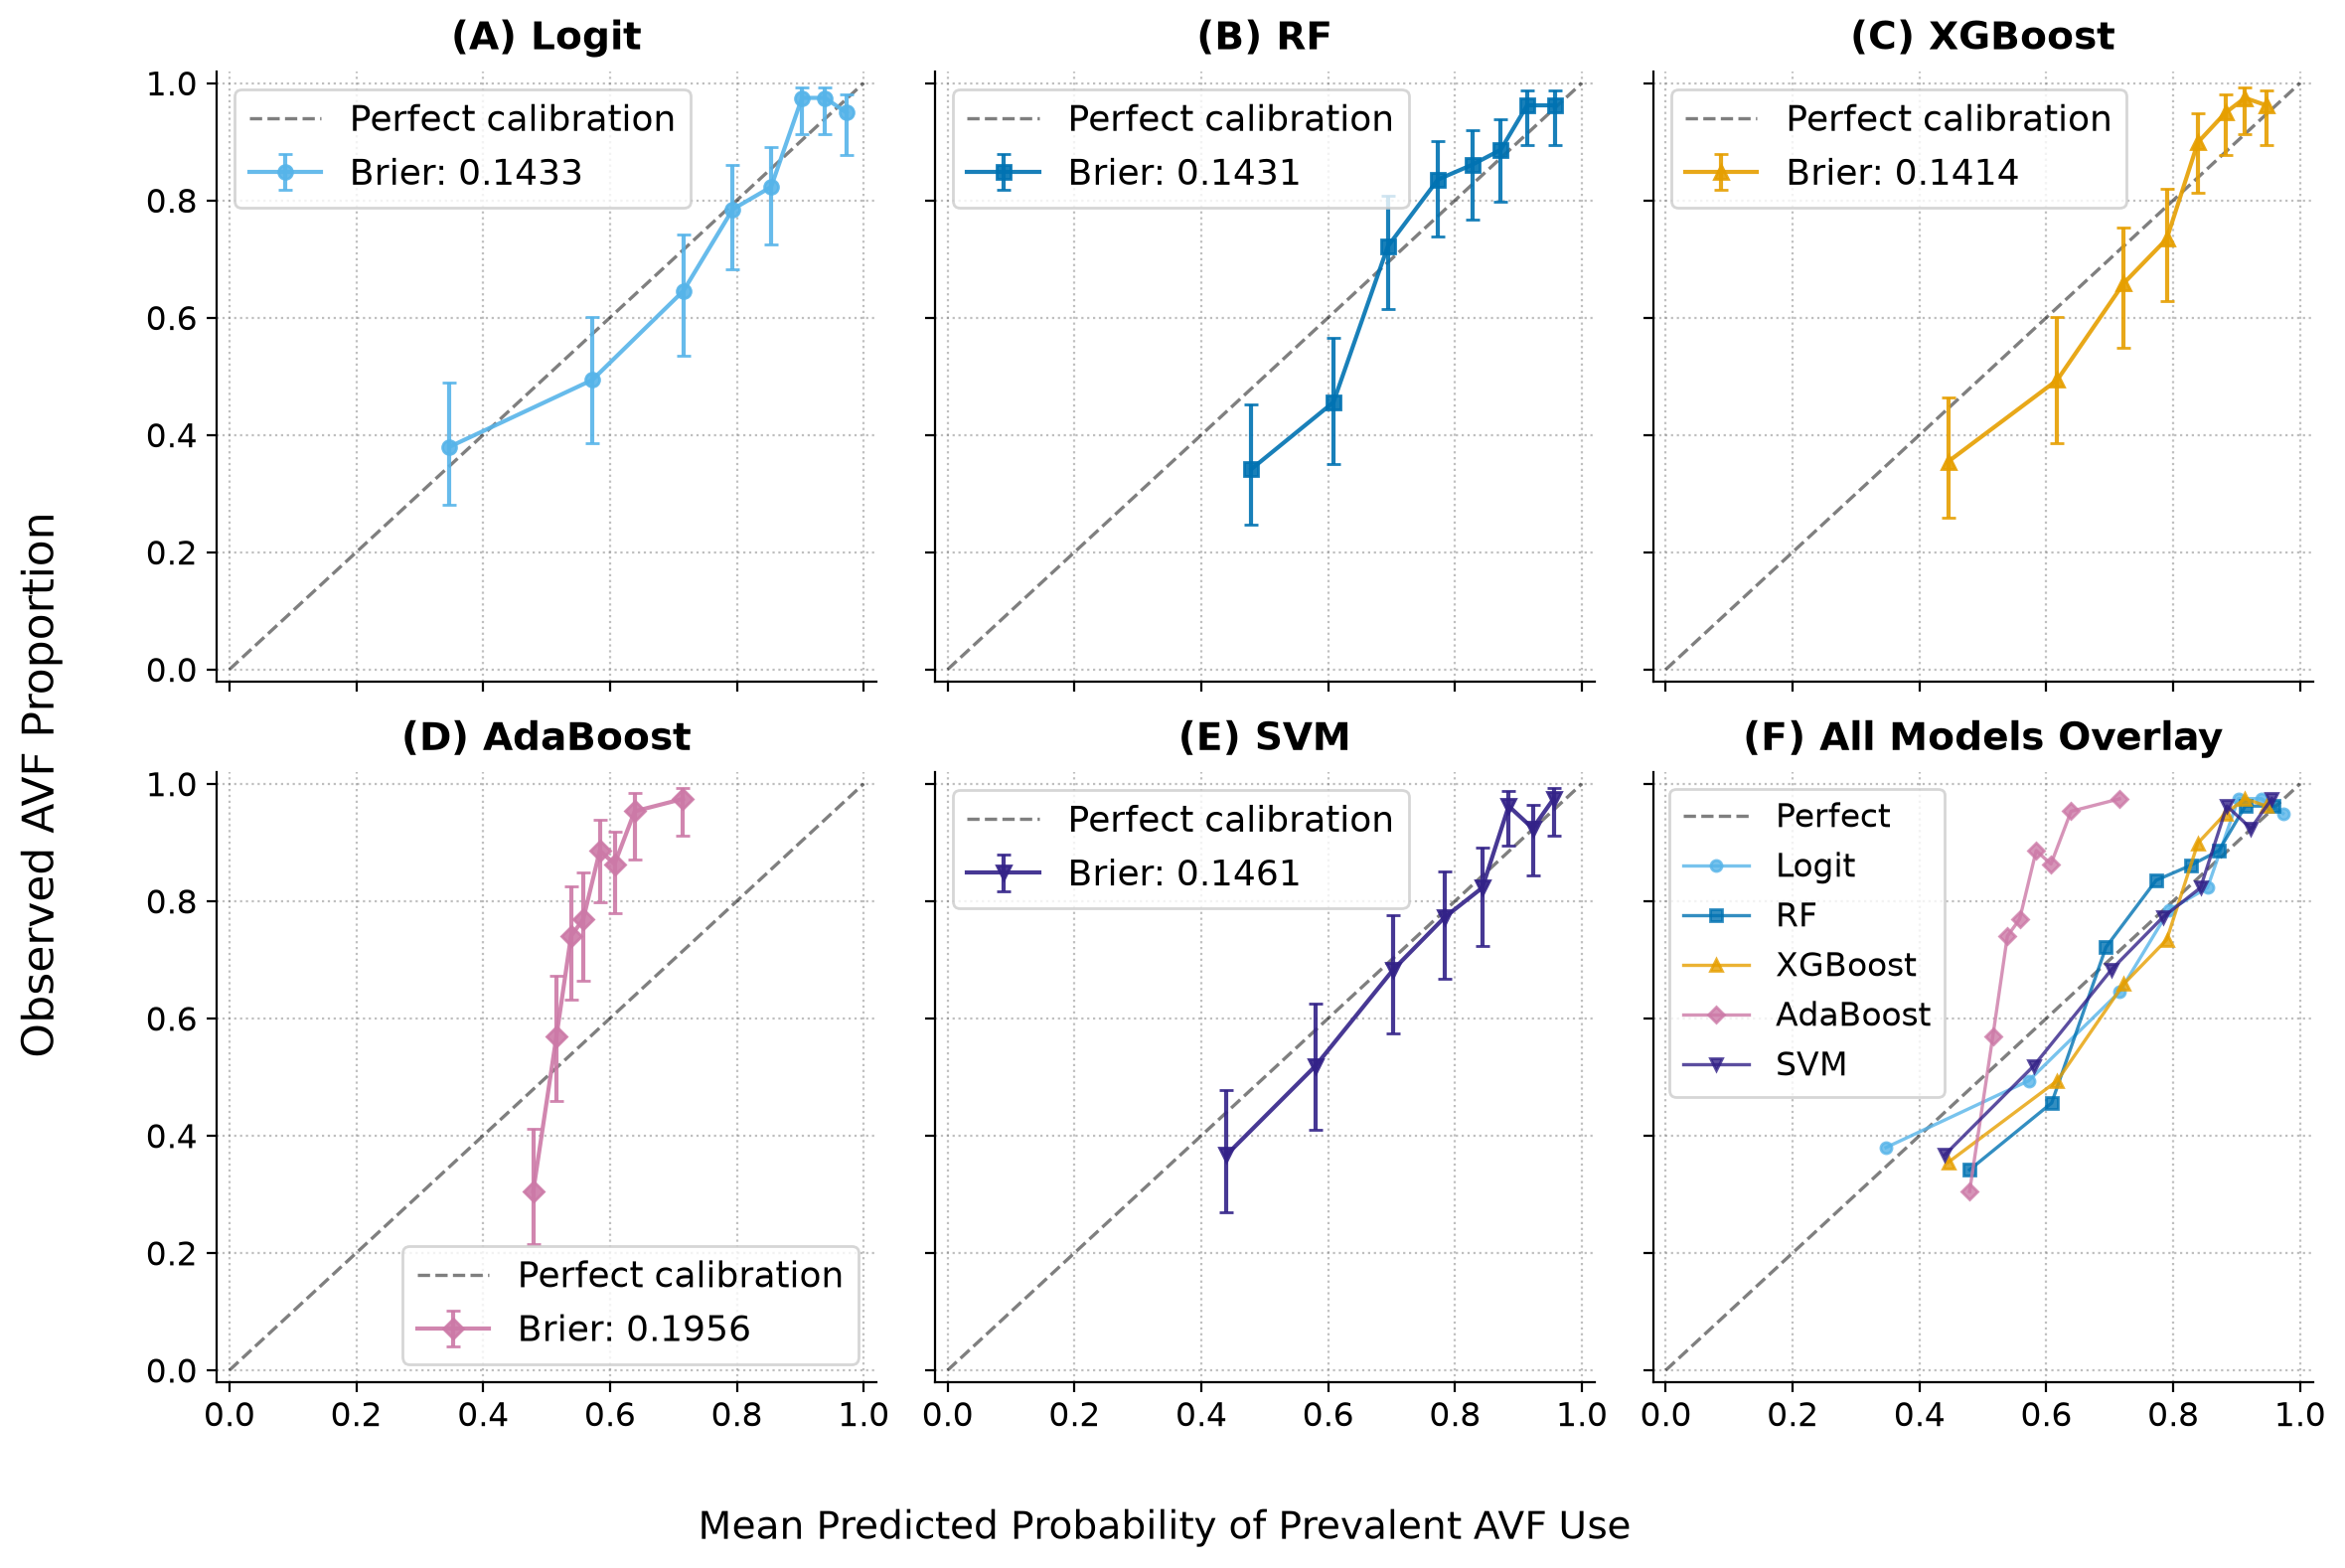

,model,mean_predicted_AVF_probability,observed_AVF_proportion,Brier,quantile_groups_used
0,Logit,0.762208,0.753165,0.143250,8
1,RF,0.765732,0.753165,0.143081,8
2,XGBoost,0.769403,0.753165,0.141358,8
3,AdaBoost,0.578328,0.753165,0.195637,8
4,SVM,0.764014,0.753165,0.146107,8


In [40]:
from IPython.display import display
from sklearn.metrics import brier_score_loss

# 1. Model Configuration
cal_configs = [
    {'probs': logit_p_test, 'label': 'Logit', 'color': '#56B4E9', 'marker': 'o'},
    {'probs': rf_p_test,    'label': 'RF',       'color': '#0072B2', 'marker': 's'},
    {'probs': xgb_p_test,   'label': 'XGBoost',  'color': '#E69F00', 'marker': '^'},
    {'probs': ada_p_test,   'label': 'AdaBoost', 'color': '#CC79A7', 'marker': 'D'},
    {'probs': svm_p_test,   'label': 'SVM',      'color': '#332288', 'marker': 'v'}
]

# Validate y_true
y_true = np.asarray(y_test, dtype=float).reshape(-1)
if y_true.size == 0 or not np.isin(y_true, [0, 1]).all():
    raise ValueError("y_test must contain nonmissing binary labels (0 or 1).")

# Validate all probability vectors
validated_configs = []
for config in cal_configs:
    pp = np.asarray(config['probs'], dtype=float).reshape(-1)
    if pp.size != y_true.size:
        raise ValueError(f"{config['label']}: provide one probability per test observation.")
    if not np.isfinite(pp).all() or ((pp < 0) | (pp > 1)).any():
        raise ValueError(f"{config['label']}: probabilities must be finite and between 0 and 1.")
    validated_configs.append({**config, 'probs': pp})

# 2. Setup Figure Layout (2 rows x 3 columns)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 10

fig, axes = plt.subplots(2, 3, figsize=(12, 8), sharex=True, sharey=True)
axes_flat = axes.flatten()

mean_probability_rows = []
observed_proportion = float(y_true.mean())
z = 1.959963984540054  # 95% Wilson interval multiplier

# 3. Plot Individual Model Panels
for idx, config in enumerate(validated_configs):
    ax = axes_flat[idx]
    pp = config['probs']
    df_bin = pd.DataFrame({'y_true': y_true, 'y_prob': pp})

    # Quantile binning
    if np.unique(pp).size == 1:
        df_bin['bin'] = 0
    else:
        df_bin['bin'] = pd.qcut(pp, q=min(8, pp.size), labels=False, duplicates='drop')

    bin_stats = df_bin.groupby('bin', observed=True, sort=True).agg(
        mean_prob=('y_prob', 'mean'),
        frac_pos=('y_true', 'mean'),
        n=('y_true', 'size')
    )

    mean_prob = bin_stats['mean_prob'].to_numpy(dtype=float)
    q = bin_stats['frac_pos'].to_numpy(dtype=float)
    n = bin_stats['n'].to_numpy(dtype=float)

    # Wilson 95% CI
    den = 1.0 + z**2 / n
    center = (q + z**2 / (2.0 * n)) / den
    half = z * np.sqrt(q * (1.0 - q) / n + z**2 / (4.0 * n**2)) / den
    lower = np.clip(center - half, 0.0, 1.0)
    upper = np.clip(center + half, 0.0, 1.0)
    yerr = np.maximum(np.vstack((q - lower, upper - q)), 0.0)

    # Reference line
    ax.plot([0, 1], [0, 1], 'k--', lw=1.2, alpha=0.5, label='Perfect calibration')

    # Calibration curve with error bars
    brier = brier_score_loss(y_true, pp)
    ax.errorbar(
        mean_prob, q, yerr=yerr, fmt='-',
        color=config['color'], marker=config['marker'],
        linewidth=1.5, markersize=5, capsize=2.5, capthick=1,
        alpha=0.9, label=f"Brier: {brier:.4f}"
    )

    # Subplot aesthetics
    ax.set_title('(' + chr(65 + idx) + ') ' + config['label'], fontsize=14, fontweight='bold', pad=8)
    ax.set_xlim([-0.02, 1.02])
    ax.set_ylim([-0.02, 1.02])
    ax.grid(True, linestyle=':', alpha=0.5, color='gray')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    # Keep the AdaBoost legend clear of its calibration curve.
    legend_position = 'lower right' if config['label'] == 'AdaBoost' else 'upper left'
    ax.legend(loc=legend_position, frameon=True, facecolor='white', framealpha=0.8, fontsize=13)

    mean_probability_rows.append({
        'model': config['label'],
        'mean_predicted_AVF_probability': float(pp.mean()),
        'observed_AVF_proportion': observed_proportion,
        'Brier': brier,
        'quantile_groups_used': len(bin_stats)
    })

# 4. Use the 6th Panel for an Overlay/Summary Comparison
ax_overlay = axes_flat[5]
ax_overlay.plot([0, 1], [0, 1], 'k--', lw=1.2, alpha=0.5, label='Perfect')

for config in validated_configs:
    pp = config['probs']
    df_bin = pd.DataFrame({'y_true': y_true, 'y_prob': pp})
    if np.unique(pp).size != 1:
        df_bin['bin'] = pd.qcut(pp, q=min(8, pp.size), labels=False, duplicates='drop')
    else:
        df_bin['bin'] = 0

    bin_stats = df_bin.groupby('bin', observed=True, sort=True).agg(
        mean_prob=('y_prob', 'mean'),
        frac_pos=('y_true', 'mean')
    )
    ax_overlay.plot(
        bin_stats['mean_prob'], bin_stats['frac_pos'],
        color=config['color'], marker=config['marker'],
        linewidth=1.2, markersize=4, label=config['label'], alpha=0.8
    )

ax_overlay.set_title('(F) All Models Overlay', fontsize=14, fontweight='bold', pad=8)
ax_overlay.set_xlim([-0.02, 1.02])
ax_overlay.set_ylim([-0.02, 1.02])
ax_overlay.grid(True, linestyle=':', alpha=0.5, color='gray')
ax_overlay.spines['top'].set_visible(False)
ax_overlay.spines['right'].set_visible(False)
ax_overlay.legend(loc='upper left', frameon=True, facecolor='white', framealpha=0.8, fontsize=12)

# Global axis labels
fig.supxlabel('Mean Predicted Probability of Prevalent AVF Use', fontsize=14, y=0.02)
fig.supylabel('Observed AVF Proportion', fontsize=16, x=0.02)

# Export the same six-panel figure used in the manuscript.
from matplotlib.text import Text
from PIL import Image as PILImage
figure_dir = RUN_DIR / 'output/publication_figures'
figure_dir.mkdir(exist_ok=True)
export_scale = fig.get_figwidth() / (180 / 25.4)
for text in fig.findobj(Text):
    text.set_fontsize(max(text.get_fontsize(), 7 * export_scale))
for ax in axes_flat:
    for spine in ax.spines.values():
        spine.set_linewidth(0.8)
    ax.tick_params(width=0.8)
fig.tight_layout(rect=[0.03, 0.03, 1, 1])
fig.savefig(figure_dir / 'Figure4.png', dpi=400 / export_scale, facecolor='white')
for extension in ['svg']:
    fig.savefig(figure_dir / ('Figure4.' + extension), facecolor='white')
with PILImage.open(figure_dir / 'Figure4.png') as image:
    rgb = image.convert('RGB')
    rgb.save(figure_dir / 'Figure4.png', dpi=(400, 400))
    rgb.save(figure_dir / 'Figure4.tiff', compression='tiff_lzw', dpi=(400, 400))
    rgb.save(figure_dir / 'Figure4.pdf', 'PDF', resolution=400.0)
plt.show()

# Display summary table
display(pd.DataFrame(mean_probability_rows))

## 9. Save holdout predictions

Save the model-by-model predictions for comparison with the evaluation routines in Section 10. These patient-level files remain in the local run folder.


In [42]:
# Save walkthrough predictions privately to verify the separate extended analysis uses identical models.
walkthrough_predictions = {c['label']: np.array(c['probs'], copy=True) for c in cal_configs}
walkthrough_rows = y_test.index.to_numpy().copy()
assert all(y_test.index.equals(yy.index)
           for yy in [y_test_ada, y_test_logit, y_test_xgb, y_test_svm])
(RUN_DIR / 'revision_work/walkthrough_private').mkdir(exist_ok=True)
np.savez(RUN_DIR / 'revision_work/walkthrough_private/predictions.npz',
         row=walkthrough_rows, y=np.asarray(y_test), **walkthrough_predictions)

manifest = {"dataset_file": str(DATA_CSV),
            "models": list(walkthrough_predictions), "holdout_n": len(walkthrough_rows)}
(RUN_DIR / "revision_work/walkthrough_private/manifest.json").write_text(json.dumps(manifest, indent=2))
print("Holdout predictions saved in:", RUN_DIR)

selection_rows = []
for name, fitted_model in [('RF',rf),('AdaBoost',ada),('Logit',logit),('XGBoost',pipeline_xgb),('SVM',pipeline_svm)]:
    pre = fitted_model.named_steps['preprocess']
    selection_rows.append(dict(model=name,n_selected=len(pre.selected_features_),n_encoded=len(pre.get_feature_names_out()),selected_features=', '.join(pre.selected_features_)))
selection_table = pd.DataFrame(selection_rows)
selection_table.to_csv(RUN_DIR / 'output/selected_features.csv',index=False)
display(selection_table)


Holdout predictions saved in: C:\workspace\avf\avf_analysis_20261002_191208_03c93d


,model,n_selected,n_encoded,selected_features
0,RF,8,12,"Gender, Age, DialysisVintage, PrimaryDiseaseDe..."
1,AdaBoost,5,9,"Gender, Age, DialysisVintage, PrimaryDiseaseDe..."
2,Logit,13,17,"Gender, Age, DialysisVintage, PrimaryDiseaseDe..."
3,XGBoost,13,17,"Gender, Age, DialysisVintage, PrimaryDiseaseDe..."
4,SVM,12,16,"Gender, Age, DialysisVintage, PrimaryDiseaseDe..."


# Validation and explanatory analyses

The following sections use the same dataset, selection rules, and final estimator settings. The holdout predictions are compared with those saved in Section 9. Repeated cross-validation refits selection and preprocessing within each training fold.


## 10. Descriptive analyses and the primary five-model comparison

The training/holdout split is unstratified with seed 0 (1,474/632 patients). Final estimator settings are fixed; model-specific feature subsets are selected within training data. Repeated internal evaluation uses three repeats of five-fold stratified CV (seeds 20260915–20260917); each repeat yields a full-cohort out-of-fold prediction vector. Model-specific feature selection is repeated within training partitions as specified above. The Logit and SVM continuous inputs are standardized; all categorical levels are retained when their source variable is selected.

Holdout intervals use 2,000 paired patient-bootstrap resamples, seed 20260915. The same resampled patients are used for all models. These intervals condition on fitted predictions and omit refitting and center dependence. Threshold measures use 0.5. Sensitivities include mean/iterative imputation, missingness indicators, omission of vintage, and complete cases on matched evaluation patients. Iterative imputation is single imputation, not pooled multiple imputation.

Adjusted association tests use the full cohort and are separate from classifier explanations. Tertiles are descriptive; continuous creatinine is used for inference. Nominal disease-by-creatinine terms test statistical effect modification under the stated association model, not an RF mechanism.


#### Helper code: Descriptive statistics, model pipelines, and validation

Run these cells in order. The first cell creates the Python module; subsequent cells append its functions. When rerunning this module, start with its first cell.


**Step 1. Imports and setup**


In [43]:
%%writefile revision_work/publication_style.py
from pathlib import Path
import json
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.text import Text
from matplotlib.lines import Line2D
from matplotlib.collections import LineCollection
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from cycler import cycler
from PIL import Image

# Logit: Sky Blue (#56B4E9), RF: Blue (#0072B2), XGBoost: Orange (#E69F00),
# AdaBoost: Magenta/Purple (#CC79A7), SVM: Dark Purple (#332288)
COLORS = ['#56B4E9', '#0072B2', '#E69F00', '#CC79A7', '#332288']
CATEGORY_COLORS = ['#0072B2', '#E69F00', '#CC79A7', '#332288']
BLUE = '#0072B2'
GOLD = '#E69F00'
MARKERS = ['o', 's', '^', 'D', 'v']
STYLES = ['-', '--', '-.', ':', (0, (5, 2, 1, 2, 1, 2))]

# Strictly Blue-to-Orange diverging correlation palette 
DIVERGING =  LinearSegmentedColormap.from_list(
    "CoolwarmBlueToPureOrange", 
    [
        "#3b4cc0",  # Dark coolwarm blue (-1.0)
        "#6788ee",  # Medium coolwarm blue
        "#9abbff",  # Light coolwarm blue
        "#c9d7f0",  # Very soft blue-gray (-0.25)
        "#ffffff",  # Neutral white (0.0)
        "#fff176",  # Light sunny yellow (+0.25)
        "#ffb74d",  # Soft orange (+0.5)
        "#ff9800",  # Pure vibrant orange (+0.75)
        "#f57c00"   # Rich deep orange (+1.0) - No red tones
    ]
)

# SHAP colormap: Blue (low feature value) -> Neutral Light Grey -> Orange/Gold (high feature value)
SHAP_CMAP = LinearSegmentedColormap.from_list('Frontiers_SHAP_Blue_Gold', [BLUE, '#F3F3F3', GOLD])

plt.rcParams.update({
    'axes.prop_cycle': cycler(color=COLORS),
    'font.family': 'DejaVu Sans',
    'pdf.fonttype': 3,
    'ps.fonttype': 42,
    'savefig.facecolor': 'white',
    'axes.linewidth': 0.8,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8
})


def contrast_text(rgba):
    """Choose black or white text from the actual background luminance."""
    linear = [c / 12.92 if c <= .04045 else ((c + .055) / 1.055) ** 2.4 for c in rgba[:3]]
    luminance = sum(a * b for a, b in zip(linear, [.2126, .7152, .0722]))
    return 'black' if (luminance + .05) / .05 >= 1.05 / (luminance + .05) else 'white'


def save_publication(fig, path, layout=True):
    """Render original vector artists, then export at 180 mm and 400 dpi.
    """
    path = Path(path).with_suffix('')
    scale = fig.get_figwidth() / (180 / 25.4)
    # Preserve plot-specific typography and the original default axis widths.
    # A small print-size floor keeps dense supplementary labels readable.
    for artist in fig.findobj(Text):
        artist.set_fontsize(max(artist.get_fontsize(), 7.0 * scale))
    for ax in fig.axes:
        for spine in ax.spines.values():
            spine.set_linewidth(0.8)
        ax.tick_params(width=0.8)
    if layout:
        fig.tight_layout(pad=1.1)
    # Render at the pixel density corresponding to 400 dpi at 180 mm.
    fig.savefig(path.with_suffix('.png'), dpi=400 / scale, facecolor='white')
    for ext in ['svg']:
        fig.savefig(path.with_suffix('.' + ext), facecolor='white')
    with Image.open(path.with_suffix('.png')) as im:
        rgb = im.convert('RGB')
        rgb.save(path.with_suffix('.png'), dpi=(400, 400))
        rgb.save(path.with_suffix('.tiff'), compression='tiff_lzw', dpi=(400, 400))
        rgb.save(path.with_suffix('.pdf'), 'PDF', resolution=400.0)

    audit = {
        'width_mm': 180,
        'dpi': 400,
        'mode': 'RGB',
        'minimum_font_pt_at_180mm': 7.0,
        'curve_line_widths': 'preserved from plotting code',
        'axis_line_pt_at_180mm': 0.8 / scale,
        'tick_line_pt_at_180mm': 0.8 / scale,
        'size_pixels': list(rgb.size)
    }
    path.with_suffix('.format.json').write_text(json.dumps(audit, indent=2))

Writing revision_work/publication_style.py


In [44]:
%%writefile revision_work/reanalyze.py
"""AVF descriptive analyses and model evaluation.
Raw patient data and row-level predictions stay in revision_work, not public outputs.
"""
from pathlib import Path
import sys, os, json, warnings, inspect
ROOT = Path(__file__).resolve().parents[1]

os.environ['MPLCONFIGDIR'] = str(ROOT / 'revision_work/mplconfig')
os.environ['NUMBA_CACHE_DIR'] = str(ROOT / 'revision_work/numba_cache')
import numpy as np, pandas as pd
import scipy, scipy.stats as st
import sklearn, xgboost, statsmodels
from statsmodels.genmod.generalized_linear_model import GLM
from statsmodels.genmod.families import Binomial
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss, roc_curve, precision_recall_curve
from sklearn.inspection import permutation_importance
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.proportion import proportion_confint
from patsy import dmatrix, build_design_matrices
from threadpoolctl import threadpool_limits
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from publication_style import CATEGORY_COLORS, BLUE, GOLD, SHAP_CMAP, COLORS, MARKERS, STYLES, DIVERGING, save_publication, contrast_text

OUT = ROOT / 'output/reanalysis'
OUT.mkdir(parents=True, exist_ok=True)
PRIVATE = ROOT / 'revision_work/reanalysis_private'
PRIVATE.mkdir(exist_ok=True)
SOURCE = Path(os.environ['AVF_DATA_CSV'])
raw = pd.read_csv(SOURCE)
data = raw.copy()
target = 'ArteriovenousFistula'
data.loc[data.Hematocrit > 100, 'Hematocrit'] = np.nan
features = [c for c in data if c not in [target, 'CarbonDioxide', 'PrimaryDisease']]
y = data[target].to_numpy()
tr, te = train_test_split(np.arange(len(data)), test_size=.3, random_state=0)
SEED = 20260915
NBOOT = 2000
NAMES = ['Logit', 'RF', 'XGBoost', 'AdaBoost', 'SVM']
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 10,
                    'axes.spines.top': False, 'axes.spines.right': False})


def save(df, name):
    df.to_csv(OUT / name, index=False)
def log(*args):
    print(*args, flush=True)


Writing revision_work/reanalyze.py


**Step 2. Define the preprocessing and model pipelines**


In [45]:
%%writefile -a revision_work/reanalyze.py


def pipe(name, cols=features, method='median', indicators=False, select=True):
    cat = [c for c in ['Gender', 'PrimaryDiseaseDet', 'PrimaryDisease'] if c in cols]
    num = [c for c in cols if c not in cat]
    imp = IterativeImputer(
        random_state=SEED,
        max_iter=20,
        initial_strategy='median',
        skip_complete=True,
    ) if method == 'iterative' else SimpleImputer(strategy=method, add_indicator=indicators)
    steps = [('impute', imp)]
    if name in ['Logit', 'SVM']:
        steps.append(('scale', StandardScaler()))
    pre = ColumnTransformer([('num', Pipeline(steps), num), ('cat', Pipeline([('impute', SimpleImputer(strategy='most_frequent')), (
        'encode', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), cat)], verbose_feature_names_out=False)
    if name == 'Logit':
        m = LogisticRegression(
            C=1,
            max_iter=3000,
            random_state=39,
        )
    elif name == 'RF':
        m = RandomForestClassifier(
            n_estimators=1800,
            max_depth=7,
            min_samples_leaf=12,
            min_samples_split=30,
            max_features='sqrt',
            max_samples=.78,
            n_jobs=4,
            random_state=39,
        )
    elif name == 'XGBoost':
        m = xgboost.XGBClassifier(
            n_estimators=400,
            max_depth=3,
            learning_rate=.01,
            subsample=.6,
            colsample_bytree=.6,
            gamma=2,
            reg_alpha=.5,
            reg_lambda=2,
            random_state=39,
            n_jobs=4,
            eval_metric='logloss',
            objective='binary:logistic',
        )
    elif name == 'AdaBoost':
        m = AdaBoostClassifier(n_estimators=200, random_state=39)
    else:
        m = SVC(
            kernel='rbf',
            C=.05,
            gamma='scale',
            class_weight='balanced',
            probability=True,
            random_state=39,
        )
    from model_specific_selection import SelectedPreprocessor
    if select:
        pre = SelectedPreprocessor(name, method=method, indicators=indicators)
    return Pipeline([('preprocess', pre), ('model', m)])

def record_selection(model, name, evaluation, repeat=0, fold=0):
    pre = model.named_steps['preprocess']
    rows = [dict(model=name, evaluation=evaluation, repeat=repeat, fold=fold,
                 variable=c, selected=c in pre.selected_features_,
                 n_selected=len(pre.selected_features_),
                 n_encoded=len(pre.get_feature_names_out()), fallback=pre.fallback_used_)
            for c in pre.feature_names_in_]
    path = OUT / 'selected_features_by_fit.csv'
    pd.DataFrame(rows).to_csv(path, mode='a', header=not path.exists(), index=False)
    stage = pd.DataFrame(pre.audit_).rename(columns={'fold':'inner_fold'}).assign(model=name,evaluation=evaluation,repeat=repeat,fold=fold)
    path = OUT / 'selection_stage_scores.csv'
    # Consistent columns across algorithms and stages.
    stage.reindex(columns=['model','evaluation','repeat','fold','inner_fold','stage','variable','n_features','AUC','AUC_loss','threshold','F_score']).to_csv(path, mode='a', header=not path.exists(), index=False)


Appending to revision_work/reanalyze.py


**Step 3. Calculate calibration intercepts and slopes**


In [46]:
%%writefile -a revision_work/reanalyze.py


def calibration(yy, p):
    z = np.log(np.clip(p, 1e-6, 1 - 1e-6) / (1 - np.clip(p, 1e-6, 1 - 1e-6)))

    def fit(x, off):
        beta = np.zeros(x.shape[1])
        for _ in range(60):
            eta = np.clip(x @ beta + off, -35, 35)
            mu = 1 / (1 + np.exp(-eta))
            w = np.clip(mu * (1 - mu), 1e-10, None)
            try:
                step = np.linalg.solve(x.T @ (w[:, None] * x), x.T @ (yy - mu))
            except np.linalg.LinAlgError:
                return np.full(x.shape[1], np.nan)
            if np.max(np.abs(step)) > 10:
                step *= 10 / np.max(np.abs(step))
            beta += step
            if np.max(np.abs(step)) < 1e-7:
                return beta
        return np.full(x.shape[1], np.nan)
    a = fit(np.ones((len(yy), 1)), z)[0]
    b = fit(np.column_stack([np.ones(len(yy)), z]), np.zeros(len(yy)))
    return a, b[1]


Appending to revision_work/reanalyze.py


**Step 4. Calculate classification and probability metrics**


In [47]:
%%writefile -a revision_work/reanalyze.py


def metrics(yy, p):
    yh = p >= .5
    pos = yy == 1
    neg = ~pos
    tp = np.sum(yh & pos)
    fp = np.sum(yh & neg)
    fn = np.sum(~yh & pos)
    tn = np.sum(~yh & neg)
    div = lambda a, b: float(a / b) if b else np.nan
    sens = div(tp, tp + fn)
    spec = div(tn, tn + fp)
    f1 = div(2 * tp, 2 * tp + fp + fn)
    f0 = div(2 * tn, 2 * tn + fp + fn)
    ci, cs = calibration(yy, p)
    return dict(AUC=roc_auc_score(yy, p), AP_AVF=average_precision_score(yy, p), AP_nonAVF=average_precision_score(1 - yy, 1 - p), sensitivity=sens, specificity=spec, PPV=div(tp, tp + fp), NPV=div(tn, tn + fn), balanced_accuracy=(sens + spec) / 2, F1_AVF=f1, F1_nonAVF=f0, macro_F1=(f1 + f0) / 2, Brier=brier_score_loss(yy, p), calibration_intercept=ci, calibration_slope=cs)


Appending to revision_work/reanalyze.py


**Step 5. Summarize the cohort, missingness, and correlations**


In [48]:
%%writefile -a revision_work/reanalyze.py


def baseline_test_statistics():
    """Table 1 test statistics, consistent with the existing p and q values.

    Z uses AVF as the first group, pooled tie correction, and the 0.5
    continuity correction. A positive Z denotes higher AVF ranks.
    Chi-square uses SciPy's default Yates correction when df equals 1.
    These are test statistics, not reduced chi-square statistics.
    """
    rows = []
    continuous = [c for c in features if c not in ['Gender', 'PrimaryDiseaseDet']]
    for c in continuous:
        a = data.loc[y == 1, c].dropna().to_numpy()
        b = data.loc[y == 0, c].dropna().to_numpy()
        u, p = st.mannwhitneyu(a, b, alternative='two-sided',
                              method='asymptotic', use_continuity=True)
        n1, n0 = len(a), len(b)
        total = n1 + n0
        _, counts = np.unique(np.concatenate([a, b]), return_counts=True)
        tie_term = np.sum(counts.astype(float) ** 3 - counts)
        sd = np.sqrt(n1 * n0 / 12 * (total + 1 - tie_term / (total * (total - 1))))
        delta = u - n1 * n0 / 2
        z = np.sign(delta) * max(abs(delta) - .5, 0) / sd if sd > 0 else 0.
        np.testing.assert_allclose(2 * st.norm.sf(abs(z)), p, rtol=1e-10, atol=0)
        rows.append(dict(variable=c, test='Mann-Whitney Z', statistic=z,
                         U_AVF=u, df=np.nan, p=p, n_AVF=n1, n_nonAVF=n0,
                         minimum_expected_count=np.nan))
    for c in ['Gender', 'PrimaryDisease', 'PrimaryDiseaseDet']:
        tab = pd.crosstab(raw[c], raw[target])
        chi, p, df, expected = st.chi2_contingency(tab, correction=True)
        rows.append(dict(variable=c, test='Chi-square (Yates)' if df == 1 else 'Pearson chi-square',
                         statistic=chi, U_AVF=np.nan, df=df, p=p,
                         n_AVF=tab[1].sum(), n_nonAVF=tab[0].sum(),
                         minimum_expected_count=expected.min()))
    result = pd.DataFrame(rows)
    save(result, 'baseline_test_statistics.csv')
    return result


def descriptive():
    rows = []
    for c in raw:
        r = {'variable': c, 'n': len(raw), 'missing': int(
            raw[c].isna().sum()), 'missing_pct': raw[c].isna().mean() * 100}
        for k in [0, 1]:
            v = raw.loc[y == k, c]
            r.update({f'n_class{k}': len(v), f'missing_class{k}': int(
                v.isna().sum()), f'missing_pct_class{k}': v.isna().mean() * 100})
        rows.append(r)
    save(pd.DataFrame(rows), 'missingness_original.csv')
    save(pd.crosstab(raw.PrimaryDisease, raw.PrimaryDiseaseDet).reset_index(),
         'disease_code_crosswalk.csv')
    save(pd.DataFrame([{'split': label, 'n': len(ids), 'AVF': int(y[ids].sum()), 'nonAVF': int((y[ids] == 0).sum(
    )), 'AVF_percent': y[ids].mean() * 100} for label, ids in [('training', tr), ('holdout', te)]]), 'original_split_counts.csv')
    flag = raw.Hematocrit > 100
    audit = {'n': len(data), 'n_columns': len(data.columns), 'complete_duplicate_rows': int(raw.duplicated().sum()), 'hct_above100': int(flag.sum()), 'hct_above100_AVF': int((flag & (y == 1)).sum()), 'hct_above100_nonAVF': int(
        (flag & (y == 0)).sum()), 'hct_missing_after_flag': int(data.Hematocrit.isna().sum()), 'age_below18': int((data.Age < 18).sum()), 'vintage_equal3': int((data.DialysisVintage == 3).sum()), 'center_dates_access_subtypes_available': False, 'features': features}
    (OUT / 'data_audit.json').write_text(json.dumps(audit, indent=2))
    cont = [c for c in features if c not in ['Gender', 'PrimaryDiseaseDet']]
    # Calculate Pearson correlations using pairwise observed values.
    corr = data[cont].corr(method='pearson')
    corr.to_csv(OUT / 'pearson_continuous.csv')
    pairs = [{'variable1': a, 'variable2': b, 'r': corr.loc[a, b]}
             for i, a in enumerate(cont) for b in cont[i + 1:]]
    save(pd.DataFrame(pairs).sort_values('r', key=abs, ascending=False), 'correlation_pairs.csv')
    rng = np.random.default_rng(SEED)
    rows = []
    for c in cont:
        a = data.loc[y == 1, c].dropna().to_numpy()
        b = data.loc[y == 0, c].dropna().to_numpy()
        u, p = st.mannwhitneyu(a, b)
        smd = (a.mean() - b.mean()) / np.sqrt((a.var(ddof=1) + b.var(ddof=1)) / 2)
        bd = np.array([np.median(rng.choice(a, len(a))) -
                      np.median(rng.choice(b, len(b))) for _ in range(1000)])
        rows.append(dict(variable=c, n_AVF=len(a), n_nonAVF=len(b), median_AVF=np.median(a), q25_AVF=np.quantile(a, .25), q75_AVF=np.quantile(a, .75), median_nonAVF=np.median(b), q25_nonAVF=np.quantile(
            b, .25), q75_nonAVF=np.quantile(b, .75), median_difference=np.median(a) - np.median(b), difference_lo=np.quantile(bd, .025), difference_hi=np.quantile(bd, .975), SMD=smd, rank_biserial=2 * u / (len(a) * len(b)) - 1, p=p))
    dt = pd.DataFrame(rows)
    dt['p_BH'] = multipletests(dt.p, method='fdr_bh')[1]
    save(dt, 'baseline_continuous_corrected.csv')
    r = []
    for c in ['Gender', 'PrimaryDisease', 'PrimaryDiseaseDet']:
        tab = pd.crosstab(raw[c], raw[target])
        chi, p, _, _ = st.chi2_contingency(tab)
        for lev in tab.index:
            p1 = tab.loc[lev, 1] / sum(y == 1)
            p0 = tab.loc[lev, 0] / sum(y == 0)
            se = np.sqrt(p1 * (1 - p1) / sum(y == 1) + p0 * (1 - p0) / sum(y == 0))
            r.append(dict(variable=c, level=lev, AVF=int(tab.loc[lev, 1]), nonAVF=int(
                tab.loc[lev, 0]), proportion_difference=p1 - p0, difference_lo=p1 - p0 - 1.96 * se, difference_hi=p1 - p0 + 1.96 * se, overall_chi2_p=p))
    save(pd.DataFrame(r), 'baseline_categorical.csv')
    br = []
    for c in cont:
        a = data.iloc[tr][c].dropna()
        b = data.iloc[te][c].dropna()
        br.append(dict(variable=c, training_median=a.median(), holdout_median=b.median(), SMD=(
            a.mean() - b.mean()) / np.sqrt((a.var(ddof=1) + b.var(ddof=1)) / 2)))
    for c in ['Gender', 'PrimaryDiseaseDet']:
        for lev in sorted(data[c].unique()):
            a = (data.iloc[tr][c] == lev).mean()
            b = (data.iloc[te][c] == lev).mean()
            br.append(dict(variable=f'{c}={lev}', training_proportion=a, holdout_proportion=b, SMD=(
                a - b) / np.sqrt((a * (1 - a) + b * (1 - b)) / 2)))
    save(pd.DataFrame(br), 'split_balance.csv')
    baseline_test_statistics()
    log('Descriptive audit complete', audit)


Appending to revision_work/reanalyze.py


**Step 6. Estimate adjusted disease–creatinine associations**


In [49]:
%%writefile -a revision_work/reanalyze.py


def associations():
    d = data.copy()
    d['CR100'] = d.CR / 100
    d['Age10'] = d.Age / 10
    d['Vintage12'] = d.DialysisVintage / 12
    base = 'C(PrimaryDiseaseDet) + CR100 + Age10 + C(Gender) + Vintage12'
    inter = 'C(PrimaryDiseaseDet)*CR100 + Age10 + C(Gender) + Vintage12'
    x = dmatrix(base, d, return_type='dataframe')
    xi = dmatrix(inter, d, return_type='dataframe')
    m = GLM(y, x, family=Binomial()).fit()
    mi = GLM(y, xi, family=Binomial()).fit()
    ndf = mi.df_model - m.df_model
    lr = 2 * (mi.llf - m.llf)
    pv = st.chi2.sf(lr, ndf)

    def results(fit, nm):
        ci = fit.conf_int()
        save(pd.DataFrame({'term': fit.params.index, 'beta': fit.params.values, 'OR': np.exp(
            fit.params.values), 'CI_low': np.exp(ci[0].values), 'CI_high': np.exp(ci[1].values), 'p': fit.pvalues.values}), nm)
    results(m, 'adjusted_main_effects.csv')
    results(mi, 'adjusted_interaction_coefficients.csv')
    ors = []
    for k in sorted(d.PrimaryDiseaseDet.unique()):
        v = np.zeros(len(mi.params))
        v[list(xi.columns).index('CR100')] = 1
        term = f'C(PrimaryDiseaseDet)[T.{k}]:CR100'
        if term in xi.columns:
            v[list(xi.columns).index(term)] = 1
        beta = float(v @ mi.params)
        se = float(np.sqrt(v @ mi.cov_params() @ v))
        ors.append({'disease_code': int(k), 'OR_per_100_CR': np.exp(beta),
                   'CI_low': np.exp(beta - 1.96 * se), 'CI_high': np.exp(beta + 1.96 * se)})
    save(pd.DataFrame(ors), 'disease_specific_creatinine_OR.csv')
    save(pd.DataFrame([{'term': c, 'VIF': variance_inflation_factor(x.to_numpy(), j)}
         for j, c in enumerate(x) if c != 'Intercept']), 'adjusted_design_VIF.csv')
    # Natural cubic spline main-effect and interaction comparison uses fixed full-cohort knots,
    # strictly an explanatory whole-sample analysis, not predictive validation.
    sf = 'cr(CR100, df=3, constraints="center")'
    xs = dmatrix(
        f'C(PrimaryDiseaseDet)+{sf}+Age10+C(Gender)+Vintage12', d, return_type='dataframe')
    xsi = dmatrix(
        f'C(PrimaryDiseaseDet)*{sf}+Age10+C(Gender)+Vintage12', d, return_type='dataframe')
    ms = GLM(y, xs, family=Binomial()).fit()
    msi = GLM(y, xsi, family=Binomial()).fit()
    slr = 2 * (msi.llf - ms.llf)
    sdf = msi.df_model - ms.df_model
    stats = {'linear_interaction_LR': lr, 'linear_df': ndf, 'linear_p': pv, 'spline_interaction_LR': slr, 'spline_df': sdf, 'spline_p': float(st.chi2.sf(slr, sdf)), 'adjusted_design_rank': int(
        np.linalg.matrix_rank(x)), 'adjusted_design_columns': x.shape[1], 'n': len(d), 'interpretation': 'Exploratory patient-independence analysis, no center adjustment or causal inference.'}
    (OUT / 'interaction_tests.json').write_text(json.dumps(stats, indent=2, default=float))
    tert, bins = pd.qcut(d.CR, 3, labels=['Low', 'Medium', 'High'], retbins=True)
    d['tertile'] = tert
    rr = []
    for (code, t), g in d.groupby(['PrimaryDiseaseDet', 'tertile'], observed=True):
        n = len(g)
        a = int(g[target].sum())
        lo, hi = proportion_confint(a, n, method='wilson')
        rr.append(dict(disease_code=int(code), tertile=str(t), AVF=a,
                  n=n, proportion=a / n, CI_low=lo, CI_high=hi))
    save(pd.DataFrame(rr), 'disease_creatinine_tertiles.csv')
    (OUT / 'tertile_cutpoints.json').write_text(json.dumps(bins.tolist()))
    log('Association models complete', stats)


Appending to revision_work/reanalyze.py


**Step 7. Evaluate the holdout and repeated cross-validation**


In [50]:
%%writefile -a revision_work/reanalyze.py


def model_analysis():
    fitted = {}
    pred = {}
    rr = []
    for name in NAMES:
        m = pipe(name)
        m.fit(data.iloc[tr][features], y[tr])
        record_selection(m, name, 'holdout')
        p = m.predict_proba(data.iloc[te][features])[:, 1]
        fitted[name] = m
        pred[name] = p
        rr.append({'model': name, **metrics(y[te], p)})
        log('Holdout', name, rr[-1]['AUC'])
    ref = np.repeat(y[tr].mean(), len(te))
    rr.append({'model': 'Training_prevalence_reference', **metrics(y[te], ref)})
    save(pd.DataFrame(rr), 'corrected_holdout_point_metrics.csv')
    np.savez(PRIVATE / 'holdout_predictions.npz', row=te, y=y[te], **pred)
    (OUT / 'model_parameters.json').write_text(json.dumps(
        {k: v.get_params() for k, v in fitted.items()}, default=str, indent=2))
    boots = {name: [] for name in NAMES}
    rng = np.random.default_rng(SEED)
    for b in range(NBOOT):
        ids = rng.integers(0, len(te), len(te))
        yb = y[te][ids]
        if len(np.unique(yb)) < 2:
            continue
        for name in NAMES:
            boots[name].append(metrics(yb, pred[name][ids]))
        if (b + 1) % 500 == 0:
            log('Bootstrap', b + 1)
    ci = []
    diff = []
    for name in NAMES:
        bd = pd.DataFrame(boots[name])
        pt = metrics(y[te], pred[name])
        for k in bd:
            finite = bd[k].dropna()
            ci.append(dict(model=name, metric=k, estimate=pt[k], lo=finite.quantile(
                .025), hi=finite.quantile(.975), valid_bootstrap=len(finite)))
        if name != 'RF':
            rf = pd.DataFrame(boots['RF'])
            for k in ['AUC', 'Brier']:
                delta = rf[k] - bd[k]
                diff.append(dict(comparison=f'RF minus {name}', metric=k, difference=metrics(
                    y[te], pred['RF'])[k] - pt[k], lo=delta.quantile(.025), hi=delta.quantile(.975)))
    save(pd.DataFrame(ci), 'corrected_holdout_metrics_CI.csv')
    save(pd.DataFrame(diff), 'paired_differences.csv')
    # Fixed settings; preprocessing and models are fitted separately within each training fold.
    cvrows = []
    for rep in range(3):
        folds = list(StratifiedKFold(n_splits=5, shuffle=True,
                     random_state=SEED + rep).split(data, y))
        for name in NAMES:
            oof = np.full(len(data), np.nan)
            for fold, (a, b) in enumerate(folds):
                m = pipe(name)
                m.fit(data.iloc[a][features], y[a])
                record_selection(m, name, 'outer_CV', rep + 1, fold + 1)
                oof[b] = m.predict_proba(data.iloc[b][features])[:, 1]
            assert np.isfinite(oof).all()
            cvrows.append(dict(repeat=rep + 1, model=name, **metrics(y, oof)))
            np.save(PRIVATE / f'oof_{name}_{rep + 1}.npy', oof)
            save(pd.DataFrame(cvrows), 'repeated_CV_metrics.csv')
            log('CV', rep + 1, name, cvrows[-1]['AUC'])
    selected = pd.read_csv(OUT / 'selected_features_by_fit.csv', keep_default_na=False)
    save(selected.query("evaluation == 'outer_CV'").groupby(['model','variable'], as_index=False).agg(selection_frequency=('selected','mean'), fits=('selected','size')), 'selection_stability.csv')
    sensitivities(fitted, pred)
    return pred


Appending to revision_work/reanalyze.py


**Step 8. Run the missing-data and predictor sensitivity analyses**


In [51]:
%%writefile -a revision_work/reanalyze.py


def sensitivities(fitted, pred):
    # Sensitivities use all five algorithms without selecting a winner from results.
    sens = []
    for name in NAMES:
        m = pipe(name, select=False).fit(data.iloc[tr][features], y[tr])
        p = m.predict_proba(data.iloc[te][features])[:, 1]
        sens.append(dict(analysis_variant='all_25_variables',model=name,n_holdout=len(te),**metrics(y[te],p)))
        for rep in range(3):
            oof = np.full(len(y), np.nan)
            for train, test in StratifiedKFold(5,shuffle=True,random_state=SEED+rep).split(data,y):
                full = pipe(name,select=False).fit(data.iloc[train][features],y[train])
                oof[test] = full.predict_proba(data.iloc[test][features])[:,1]
            np.save(PRIVATE / f'all25_oof_{name}_{rep+1}.npy',oof)
            comparison_path = OUT / 'all25_repeated_CV_metrics.csv'
            pd.DataFrame([dict(model=name,repeat=rep+1,**metrics(y,oof))]).to_csv(comparison_path,mode='a',header=not comparison_path.exists(),index=False)

    specs = [('mean', features, 'mean', False, data), ('iterative', features, 'iterative', False, data), ('missing_indicators', features, 'median', True, data),
             ('without_vintage', [c for c in features if c != 'DialysisVintage'], 'median', False, data)]
    for tag, cols, method, ind, d in specs:
        for name in NAMES:
            m = pipe(name, cols, method, ind)
            m.fit(d.iloc[tr][cols], y[tr])
            p = m.predict_proba(d.iloc[te][cols])[:, 1]
            sens.append(dict(analysis_variant=tag, model=name,
                        n_holdout=len(te), **metrics(y[te], p)))
        save(pd.DataFrame(sens), 'sensitivity_metrics.csv')
        log('Sensitivity', tag)
    ok = data[features].notna().all(axis=1).to_numpy()
    a = tr[ok[tr]]
    b = te[ok[te]]
    for name in NAMES:
        m = pipe(name)
        m.fit(data.iloc[a][features], y[a])
        p = m.predict_proba(data.iloc[b][features])[:, 1]
        sens.append(dict(analysis_variant='complete_case', model=name,
                    n_training=len(a), n_holdout=len(b), **metrics(y[b], p)))
        sens.append(dict(analysis_variant='primary_on_same_complete_cases', model=name,
                    n_training=len(tr), n_holdout=len(b), **metrics(y[b], pred[name][ok[te]])))
    save(pd.DataFrame(sens), 'sensitivity_metrics.csv')
    plotting(pred)
    # Common permutation AUC loss. Assessment used for description only, not refitting.
    imps = []
    for name, m in fitted.items():
        pi = permutation_importance(
            m, data.iloc[te][features], y[te], scoring='roc_auc', n_repeats=10, random_state=SEED, n_jobs=1)
        for c, mu, sd in zip(features, pi.importances_mean, pi.importances_std):
            imps.append(dict(model=name, variable=c, mean_AUC_loss=mu, shuffle_SD=sd))
        log('Permutation importance', name)
    save(pd.DataFrame(imps), 'common_permutation_importance.csv')
    explain(fitted['RF'])


Appending to revision_work/reanalyze.py


**Step 9. Prepare supporting model-performance plots**


In [52]:
%%writefile -a revision_work/reanalyze.py


def plotting(pred):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
    for name, p in pred.items():
        a, b, _ = roc_curve(y[te], p)
        axes[0].plot(a, b, label=f'{name} {roc_auc_score(y[te], p):.3f}')
        pr, re, _ = precision_recall_curve(1 - y[te], 1 - p)
        axes[1].plot(re, pr, label=name)
        # Quantile bins with binomial Wilson intervals; uncertainty doesn't include fitting.
        groups = pd.qcut(p, q=8, duplicates='drop')
        dt = pd.DataFrame({'p': p, 'y': y[te], 'bin': groups})
        rows = []
        for _, g in dt.groupby('bin', observed=True):
            lo, hi = proportion_confint(g.y.sum(), len(g), method='wilson')
            rows.append((g.p.mean(), g.y.mean(), lo, hi))
        q = np.array(rows)
        axes[2].plot(q[:, 0], q[:, 1], 'o-', label=name, ms=3)
        axes[2].errorbar(q[:, 0], q[:, 1], yerr=[q[:, 1] - q[:, 2],
                         q[:, 3] - q[:, 1]], fmt='none', alpha=.15)
    axes[0].plot([0, 1], [0, 1], 'k--', lw=1)
    axes[0].set(xlabel='False positive rate', ylabel='True positive rate',
                title='ROC on internal holdout')
    axes[0].legend(fontsize=8)
    axes[1].axhline((y[te] == 0).mean(), ls='--', c='gray')
    axes[1].set(xlabel='Non AVF recall', ylabel='Non AVF precision',
                title='Minority class precision recall')
    axes[2].plot([0, 1], [0, 1], 'k--', lw=1)
    axes[2].set(xlabel='Mean estimated AVF probability', ylabel='Observed AVF proportion',
                title='Quantile calibration and Wilson intervals', xlim=(0, 1), ylim=(0, 1))
    fig.tight_layout()
    fig.savefig(OUT / 'model_performance.png', dpi=180)
    plt.close(fig)


Appending to revision_work/reanalyze.py


**Step 10. Prepare supporting model explanations**


In [53]:
%%writefile -a revision_work/reanalyze.py


def explain(model):
    import shap
    x = model.named_steps['preprocess'].transform(data.iloc[te][features])
    names = model.named_steps['preprocess'].get_feature_names_out()
    # All holdout covariates; forest path-dependent attribution, explicitly descriptive.
    ex = shap.TreeExplainer(model.named_steps['model'])
    sv = np.asarray(ex.shap_values(x))
    if sv.ndim == 3:
        sv = sv[:, :, 1]
    p = model.named_steps['model'].predict_proba(x)[:, 1]
    base = np.asarray(ex.expected_value).reshape(-1)[1]
    assert np.max(np.abs(base + sv.sum(1) - p)) < 1e-5
    grouped = {}
    for c in features:
        ids = [j for j, n in enumerate(names) if n == c or (
            c in ['Gender', 'PrimaryDiseaseDet'] and n.startswith(c + '_'))]
        grouped[c] = sv[:, ids].sum(1)
    rank = pd.DataFrame([{'variable': k, 'mean_abs_grouped_SHAP': np.mean(abs(v))}
                        for k, v in grouped.items()]).sort_values('mean_abs_grouped_SHAP', ascending=False)
    save(rank, 'RF_grouped_SHAP.csv')
    sel = rank.head(12).iloc[::-1]
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.barh(sel.variable, sel.mean_abs_grouped_SHAP, color=BLUE)
    ax.set(xlabel='Mean absolute grouped SHAP contribution',
           title='Random forest explanations on internal holdout covariates')
    fig.tight_layout()
    fig.savefig(OUT / 'RF_SHAP.png', dpi=180)
    plt.close(fig)
    log('SHAP complete', rank.head(5).to_dict('records'))


if __name__ == '__main__':
    with threadpool_limits(limits=4):
        if '--resume-tail' in sys.argv:
            saved = np.load(PRIVATE / 'holdout_predictions.npz')
            fitted = {}
            pred = {}
            for name in NAMES:
                fitted[name] = pipe(name).fit(data.iloc[tr][features], y[tr])
                pred[name] = saved[name]
                assert np.allclose(fitted[name].predict_proba(
                    data.iloc[te][features])[:, 1], pred[name])
            sensitivities(fitted, pred)
        else:
            descriptive()
            associations()
            model_analysis()
    (OUT / 'COMPLETED.txt').write_text('Post-review exploratory reanalysis completed. See protocol and caveats.\n')
    log('COMPLETE')


Appending to revision_work/reanalyze.py


In [54]:
import reanalyze as a
assert len(a.raw) == 2106 and a.raw.shape[1] == 28
assert len(a.y) == 2106 and len(a.features) == 25
with threadpool_limits(limits=4):
    a.descriptive()
    a.associations()
print("Descriptive and adjusted association analyses complete.")


Descriptive audit complete {'n': 2106, 'n_columns': 28, 'complete_duplicate_rows': 0, 'hct_above100': 57, 'hct_above100_AVF': 57, 'hct_above100_nonAVF': 0, 'hct_missing_after_flag': 121, 'age_below18': 0, 'vintage_equal3': 5, 'center_dates_access_subtypes_available': False, 'features': ['Gender', 'Age', 'DialysisVintage', 'PrimaryDiseaseDet', 'Systolic', 'Diastolic', 'BMI', 'Hemoglobin', 'WhiteBloodCell', 'Hematocrit', 'Platelets', 'ALB', 'ALT', 'AST', 'CR', 'KA', 'NA', 'BUN', 'CA', 'P', 'PTH', 'Ferritin', 'TSAT', 'CRP', 'B2M']}
Association models complete {'linear_interaction_LR': np.float64(1.8102341903327215), 'linear_df': np.int64(3), 'linear_p': np.float64(0.6127103976658748), 'spline_interaction_LR': np.float64(11.286490356894546), 'spline_df': np.int64(9), 'spline_p': 0.25658152584362703, 'adjusted_design_rank': 8, 'adjusted_design_columns': 8, 'n': 2106, 'interpretation': 'Exploratory patient-independence analysis, no center adjustment or causal inference.'}
Descriptive and adj

In [55]:
with threadpool_limits(limits=4):
    primary_predictions = a.model_analysis()
(a.OUT / "COMPLETED.txt").write_text("All primary analysis stages completed.\n")
display(pd.read_csv(a.OUT / "corrected_holdout_point_metrics.csv").round(4))
display(pd.read_csv(a.OUT / "repeated_CV_metrics.csv").groupby(
    "model").mean(numeric_only=True).drop(columns="repeat").round(4))

# Calibration groups use held-out predictions.
calibration_rows = []
holdout = np.load(a.PRIVATE / "holdout_predictions.npz")
assert np.array_equal(holdout["row"], a.te)
for name in a.NAMES:
    p = holdout[name]
    yy = holdout["y"]
    groups = pd.DataFrame({"p": p, "y": yy, "bin": pd.qcut(p, 8, duplicates="drop")})
    for bin_number, (_, group) in enumerate(groups.groupby("bin", observed=True), 1):
        n = len(group)
        proportion = float(group.y.mean())
        z = 1.96
        den = 1 + z * z / n
        center = (proportion + z * z / (2 * n)) / den
        half = z * np.sqrt(proportion * (1 - proportion) / n + z * z / (4 * n * n)) / den
        calibration_rows.append(dict(model=name, bin=bin_number, n=n, AVF_n=int(group.y.sum()),
                                     mean_predicted_AVF_probability=float(group.p.mean()), observed_AVF_proportion=proportion,
                                     observed_Wilson_lo=center - half, observed_Wilson_hi=center + half))
pd.DataFrame(calibration_rows).to_csv(a.OUT / "calibration_bins.csv", index=False)


Holdout Logit 0.8159205990088343
Holdout RF 0.8199606765783237
Holdout XGBoost 0.8316499676793796
Holdout AdaBoost 0.8046353156647275
Holdout SVM 0.805887739711269
Bootstrap 500
Bootstrap 1000
Bootstrap 1500
Bootstrap 2000
CV 1 Logit 0.7821893672917882
CV 1 RF 0.7863877759594706
CV 1 XGBoost 0.7901234567901235
CV 1 AdaBoost 0.7558765808300258
CV 1 SVM 0.7573224485701209
CV 2 Logit 0.7845393726213092
CV 2 RF 0.7940033481932922
CV 2 XGBoost 0.7961502047163127
CV 2 AdaBoost 0.754186182119143
CV 2 SVM 0.7750860560916427
CV 3 Logit 0.7830872348563225
CV 3 RF 0.7909899742301978
CV 3 XGBoost 0.8004125676378935
CV 3 AdaBoost 0.751589137808877
CV 3 SVM 0.77476691182464
Sensitivity mean
Sensitivity iterative
Sensitivity missing_indicators
Sensitivity without_vintage
Permutation importance Logit
Permutation importance RF
Permutation importance XGBoost
Permutation importance AdaBoost
Permutation importance SVM
SHAP complete [{'variable': 'Gender', 'mean_abs_grouped_SHAP': 0.05589134373139086}, {'v

,model,AUC,AP_AVF,AP_nonAVF,sensitivity,specificity,PPV,NPV,balanced_accuracy,F1_AVF,F1_nonAVF,macro_F1,Brier,calibration_intercept,calibration_slope
0,Logit,0.8159,0.9234,0.5548,0.9265,0.3462,0.8122,0.6067,0.6363,0.8656,0.4408,0.6532,0.1433,-0.0638,1.0210
1,RF,0.8200,0.9220,0.5813,0.9727,0.2179,0.7915,0.7234,0.5953,0.8728,0.3350,0.6039,0.1431,-0.0796,1.4847
2,XGBoost,0.8316,0.9305,0.5877,0.9622,0.2436,0.7951,0.6786,0.6029,0.8707,0.3585,0.6146,0.1414,-0.1051,1.4663
3,AdaBoost,0.8046,0.9179,0.5739,0.9517,0.2756,0.8004,0.6515,0.6137,0.8695,0.3874,0.6284,0.1956,0.8148,5.2786
4,SVM,0.8059,0.9212,0.5336,0.9496,0.2628,0.7972,0.6308,0.6062,0.8667,0.3710,0.6189,0.1461,-0.0708,1.2281
5,Training_prevalence_reference,0.5000,0.7532,0.2468,1.0000,0.0000,0.7532,NaN,0.5000,0.8592,0.0000,0.4296,0.1862,-0.0928,NaN


,AUC,AP_AVF,AP_nonAVF,sensitivity,specificity,PPV,NPV,balanced_accuracy,F1_AVF,F1_nonAVF,macro_F1,Brier,calibration_intercept,calibration_slope
model,,,,,,,,,,,,,,
AdaBoost,0.7539,0.9029,0.4685,0.9398,0.2357,0.8001,0.5462,0.5877,0.8643,0.3286,0.5965,0.1973,0.8637,3.9923
Logit,0.7833,0.9185,0.5150,0.9332,0.3044,0.8136,0.5833,0.6188,0.8693,0.4000,0.6347,0.1468,-0.0027,0.9284
RF,0.7905,0.9179,0.5283,0.9712,0.1872,0.7955,0.6665,0.5792,0.8746,0.2922,0.5834,0.1458,-0.0001,1.3871
SVM,0.7691,0.9111,0.4838,0.9385,0.2828,0.8098,0.5865,0.6107,0.8695,0.3815,0.6255,0.1502,0.0124,0.9559
XGBoost,0.7956,0.9222,0.5258,0.9532,0.2451,0.8043,0.6170,0.5992,0.8725,0.3508,0.6116,0.1442,-0.0177,1.2110


In [56]:
# Compare the two implementations of the holdout models.
comparison_report = {"status": "not_run", "reason": "No walkthrough run folder supplied"}
if WALKTHROUGH_RUN_DIR is not None:
    private = Path(WALKTHROUGH_RUN_DIR).expanduser().resolve() / "revision_work/walkthrough_private"
    manifest = json.loads((private / "manifest.json").read_text())
    with np.load(private / "predictions.npz", allow_pickle=False) as saved:
        assert np.array_equal(saved["row"], a.te), "Holdout rows differ."
        assert np.array_equal(saved["y"], a.y[a.te]), "Holdout outcomes differ."
        differences = []
        for name in a.NAMES:
            error = float(np.max(np.abs(saved[name] - primary_predictions[name])))
            assert error < 1e-7, (name, error)
            differences.append({"model": name, "maximum_probability_difference": error})
    comparison_report = {"status": "passed", "checks": differences}
    display(pd.DataFrame(differences))
else:
    print("Optional walkthrough comparison not run; extended analyses run independently.")
(RUN_DIR / "output/walkthrough_consistency.json").write_text(json.dumps(comparison_report, indent=2))


,model,maximum_probability_difference
0,Logit,0.000000e+00
1,RF,3.330669e-16
2,XGBoost,0.000000e+00
3,AdaBoost,0.000000e+00
4,SVM,0.000000e+00


466

## 11. SHAP analyses

Native explanations cover all holdout patients for RF, XGBoost and Logit regression. RF uses probability units; XGBoost and Logit use log-odds. Signed encoded contributions are grouped before taking absolute importance. Native scales and reference conventions differ.

For all five models on a common probability scale, permutation SHAP uses the same 160 randomly sampled holdout patients (seed 20260918), 32 training reference rows (seed 20260919), and original-variable masking before encoding. Eight forward/reverse cycles use seed 20260920. Sensitivities on the first 40 patients use 16 cycles (seed 20260921) or 64 reference rows. Validation-fold stability is assessed for RF and XGBoost on the first five-fold repeat. Fold models are fitted on their training partitions only.

Native interaction matrices use the same 160 patients. Each pair sums its two symmetric off-diagonal entries. Checks verify prediction reproduction, additivity, grouping recovery, and symmetry. These explanations are descriptive and their masking can break observed feature dependencies.


#### Helper code: SHAP calculations and consistency checks

Run these cells in order. The first cell creates the Python module; subsequent cells append its functions. When rerunning this module, start with its first cell.


**Step 1. Imports and setup**


In [57]:
%%writefile revision_work/extend_shap.py
from pathlib import Path
import sys, os, time, json
import numpy as np, pandas as pd
ROOT = Path(__file__).resolve().parents[1]

os.environ['MPLCONFIGDIR'] = str(ROOT / 'revision_work/mplconfig')
os.environ['NUMBA_CACHE_DIR'] = str(ROOT / 'revision_work/numba_cache')
import shap, joblib
from scipy.stats import spearmanr
from threadpoolctl import threadpool_limits
from sklearn.model_selection import StratifiedKFold
import reanalyze as a
OUT = ROOT / 'output/shap_extension'
OUT.mkdir(exist_ok=True)
P = ROOT / 'revision_work/shap_extension_private'
P.mkdir(exist_ok=True)
F = a.features
N = a.NAMES
saved = np.load(a.PRIVATE / 'holdout_predictions.npz')
assert np.array_equal(saved['row'], a.te)
sample = np.random.default_rng(20260918).choice(len(a.te), 160, replace=False)
background = np.random.default_rng(20260919).permutation(len(a.tr))
np.savez(P / 'sampling.npz', sample=sample, background=background)
def log(*x):
    print(*x, flush=True)
def frame(rows, name):
    pd.DataFrame(rows).to_csv(OUT / name, index=False)


Writing revision_work/extend_shap.py


**Step 2. Fit a model and check its holdout predictions**


In [58]:
%%writefile -a revision_work/extend_shap.py


def fitted(name):
    path = P / (name + '.joblib')
    if path.exists():
        m = joblib.load(path)
    else:
        m = a.pipe(name).fit(a.data.iloc[a.tr][F], a.y[a.tr])
        joblib.dump(m, path)
    pred = m.predict_proba(a.data.iloc[a.te][F])[:, 1]
    err = float(np.max(np.abs(pred - saved[name])))
    assert err < 1e-7, (name, err)
    return m, err


Appending to revision_work/extend_shap.py


**Step 3. Map encoded predictors back to source variables**


In [59]:
%%writefile -a revision_work/extend_shap.py


def group_matrix(names):
    g = np.zeros((len(names), len(F)))
    for j, n in enumerate(names):
        match = [i for i, c in enumerate(F) if n == c or (
            c in ['Gender', 'PrimaryDiseaseDet'] and n.startswith(c + '_'))]
        assert len(match) == 1, (n, match)
        g[j, match[0]] = 1
    return g


Appending to revision_work/extend_shap.py


**Step 4. Calculate SHAP values in each model’s native output scale**


In [60]:
%%writefile -a revision_work/extend_shap.py


def native(m, ids, name, training=None):
    pre = m.named_steps['preprocess']
    model = m.named_steps['model']
    x = pre.transform(a.data.iloc[ids][F])
    names = pre.get_feature_names_out()
    g = group_matrix(names)
    if name == 'Logit':
        train = pre.transform(a.data.iloc[a.tr if training is None else training][F])
        ex = shap.LinearExplainer(model, (train.mean(0), np.cov(train, rowvar=False)))
        sv = np.asarray(ex.shap_values(x))
        base = float(ex.expected_value)
        pred = model.decision_function(x)
    else:
        ex = shap.TreeExplainer(
            model, feature_perturbation='tree_path_dependent', model_output='raw')
        sv = np.asarray(ex.shap_values(x))
        if sv.ndim == 3:
            sv = sv[:, :, 1]
        base = float(np.asarray(ex.expected_value).reshape(-1)[1 if name == 'RF' else 0])
        pred = model.predict_proba(
            x)[:, 1] if name == 'RF' else model.predict(x, output_margin=True)
    err = float(np.max(abs(base + sv.sum(1) - pred)))
    assert err < 2e-5, (name, err)
    return sv @ g, base, err, ex, x, g


def rankrows(values, name, **meta):
    importance = np.mean(abs(values), axis=0)
    ranks = pd.Series(-importance).rank(method='min').to_numpy()
    return [dict(model=name, variable=f, mean_abs_SHAP=float(v), rank=int(r), **meta) for f, v, r in zip(F, importance, ranks)]


Appending to revision_work/extend_shap.py


**Step 5. Explain the full holdout and verify additivity**


In [61]:
%%writefile -a revision_work/extend_shap.py


def stage_native():
    rr = []
    checks = []
    for name in N:
        start = time.time()
        m, err = fitted(name)
        checks.append(dict(model=name, prediction_max_error=err))
        log('Reproduced', name, err)
        if name not in ['RF', 'XGBoost', 'Logit']:
            continue
        sv, base, ae, ex, x, g = native(m, a.te, name)
        np.savez_compressed(P / (name + '_native.npz'), values=sv, base=base, row=a.te)
        rr += rankrows(sv, name, scale='probability' if name == 'RF' else 'log_odds')
        checks[-1]['additivity_max_error'] = ae
        frame(rr, 'native_importance.csv')
        log('Native', name, 'seconds', round(time.time() - start, 1))
    (OUT / 'native_checks.json').write_text(json.dumps(checks, indent=2))


Appending to revision_work/extend_shap.py


**Step 6. Compare all five models on a common probability scale**


In [62]:
%%writefile -a revision_work/extend_shap.py


def stage_common():
    rr = []
    checks = []
    X = a.data[F].copy()
    nums = [c for c in F if c not in ['Gender', 'PrimaryDiseaseDet']]
    X[nums] = X[nums].fillna(X.iloc[a.tr][nums].median())
    evalx = X.iloc[a.te[sample]].to_numpy()
    bg = X.iloc[a.tr[background[:64]]].to_numpy()
    for name in N:
        m, err = fitted(name)
        def fun(x):
            return m.predict_proba(pd.DataFrame(x, columns=F))[:, 1]
        assert np.max(abs(fun(evalx) - saved[name][sample])) < 1e-7
        for variant, n, bgsize, cycles, seed in [('main', 160, 32, 8, 20260920), ('precision', 40, 32, 16, 20260921), ('background', 40, 64, 8, 20260920)]:
            path = P / f'{name}_common_{variant}.npz'
            start = time.time()
            if path.exists():
                z = np.load(path)
                sv = z['values']
                base = z['base']
            else:
                ex = shap.PermutationExplainer(fun, shap.maskers.Independent(
                    bg[:bgsize], max_samples=bgsize), feature_names=F, seed=seed)
                values = []
                bases = []
                for offset in range(0, n, 20):
                    result = ex(evalx[offset:min(offset + 20, n)], max_evals=cycles *
                                (2 * len(F) + 1), batch_size=2048, silent=True)
                    values.append(result.values)
                    bases.append(result.base_values)
                    log('Common', name, variant, min(offset + 20, n), '/', n)
                sv = np.concatenate(values)
                base = np.concatenate(bases)
                np.savez_compressed(path, values=sv, base=base, row=a.te[sample[:n]])
            ae = float(np.max(abs(base + sv.sum(1) - fun(evalx[:n]))))
            assert ae < 2e-5, (name, variant, ae)
            rr += rankrows(sv, name, variant=variant, n=n, background_n=bgsize, cycles=cycles)
            checks.append(dict(model=name, variant=variant,
                          additivity_max_error=ae, seconds=time.time() - start))
            frame(rr, 'common_probability_importance.csv')
            (OUT / 'common_checks.json').write_text(json.dumps(checks, indent=2))
            log('Completed', name, variant, round(time.time() - start, 1))


Appending to revision_work/extend_shap.py


**Step 7. Check explanation stability across validation folds**


In [63]:
%%writefile -a revision_work/extend_shap.py


def stage_cv():
    rr = []
    checks = []
    folds = StratifiedKFold(5, shuffle=True, random_state=a.SEED)
    for fold, (train, test) in enumerate(folds.split(a.data, a.y), 1):
        for name in ['RF', 'XGBoost']:
            path = P / f'{name}_cv{fold}.npz'
            start = time.time()
            if path.exists():
                z = np.load(path)
                sv = z['values']
                err = float(z['prediction_error'])
                ae = float(z['additivity_error'])
            else:
                m = a.pipe(name).fit(a.data.iloc[train][F], a.y[train])
                pred = m.predict_proba(a.data.iloc[test][F])[:, 1]
                old = np.load(a.PRIVATE / f'oof_{name}_1.npy')[test]
                err = float(np.max(abs(pred - old)))
                assert err < 1e-7
                sv, base, ae, *_ = native(m, test, name, train)
                np.savez_compressed(path, values=sv, base=base, row=test,
                                    prediction_error=err, additivity_error=ae)
            rr += rankrows(sv, name, fold=fold, n=len(test))
            checks.append(dict(model=name, fold=fold,
                          prediction_error=err, additivity_error=ae))
            frame(rr, 'cv_importance.csv')
            (OUT / 'cv_checks.json').write_text(json.dumps(checks, indent=2))
            log('CV', name, fold, round(time.time() - start, 1))


Appending to revision_work/extend_shap.py


**Step 8. Calculate and check tree SHAP interaction values**


In [64]:
%%writefile -a revision_work/extend_shap.py


def stage_interactions():
    rr = []
    checks = []
    for name in ['RF', 'XGBoost']:
        path = P / (name + '_interactions.npz')
        start = time.time()
        if path.exists():
            z = np.load(path)
            iv = z['values']
            checks.append(json.loads(str(z['checks'])))
        else:
            m, _ = fitted(name)
            sv, base, ae, ex, x, g = native(m, a.te[sample], name)
            iv = np.asarray(ex.shap_interaction_values(x))
            if iv.ndim == 4:
                iv = iv[:, :, :, 1]
            iv = np.einsum('ab,nbc,cd->nad', g.T, iv, g)
            symmetry = float(np.max(abs(iv - iv.transpose(0, 2, 1))))
            recovery = float(np.max(abs(iv.sum(2) - sv)))
            assert symmetry < 2e-5 and recovery < 2e-5, (name, symmetry, recovery)
            ch = dict(model=name, symmetry_max_error=symmetry, shap_recovery_max_error=recovery,
                      scale='probability' if name == 'RF' else 'log_odds')
            checks.append(ch)
            np.savez_compressed(path, values=iv, row=a.te[sample], checks=json.dumps(ch))
        for i, f in enumerate(F):
            for j in range(i + 1, len(F)):
                rr.append(dict(model=name, variable1=f, variable2=F[j], mean_abs_pair_contribution=float(
                    np.mean(abs(2 * iv[:, i, j])))))
        frame(rr, 'native_interaction_pairs.csv')
        (OUT / 'interaction_checks.json').write_text(json.dumps(checks, indent=2))
        log('Interactions', name, round(time.time() - start, 1))


if __name__ == '__main__':
    with threadpool_limits(limits=4):
        stage = sys.argv[1]
        {'native': stage_native, 'common': stage_common,
            'cv': stage_cv, 'interactions': stage_interactions}[stage]()
    log('DONE', stage)


Appending to revision_work/extend_shap.py


In [65]:
import extend_shap as e
print("Native values and refit checks")
with threadpool_limits(limits=4):
    e.stage_native()


Native values and refit checks
Reproduced Logit 0.0
Native Logit seconds 0.4
Reproduced RF 3.3306690738754696e-16
Native RF seconds 8.0
Reproduced XGBoost 0.0
Native XGBoost seconds 5.7
Reproduced AdaBoost 0.0
Reproduced SVM 0.0


In [66]:
print("Common probability SHAP and sensitivities")
with threadpool_limits(limits=4):
    e.stage_common()


Common probability SHAP and sensitivities
Common Logit main 20 / 160
Common Logit main 40 / 160
Common Logit main 60 / 160
Common Logit main 80 / 160
Common Logit main 100 / 160
Common Logit main 120 / 160
Common Logit main 140 / 160
Common Logit main 160 / 160
Completed Logit main 9.3
Common Logit precision 20 / 40
Common Logit precision 40 / 40
Completed Logit precision 2.1
Common Logit background 20 / 40
Common Logit background 40 / 40
Completed Logit background 2.3
Common RF main 20 / 160
Common RF main 40 / 160
Common RF main 60 / 160
Common RF main 80 / 160
Common RF main 100 / 160
Common RF main 120 / 160
Common RF main 140 / 160
Common RF main 160 / 160
Completed RF main 442.6
Common RF precision 20 / 40
Common RF precision 40 / 40
Completed RF precision 208.8
Common RF background 20 / 40
Common RF background 40 / 40
Completed RF background 108.3
Common XGBoost main 20 / 160
Common XGBoost main 40 / 160
Common XGBoost main 60 / 160
Common XGBoost main 80 / 160
Common XGBoost ma

In [67]:
print("Validation-fold explanation stability")
with threadpool_limits(limits=4):
    e.stage_cv()


Validation-fold explanation stability
CV RF 1 7.0
CV XGBoost 1 4.9
CV RF 2 7.1
CV XGBoost 2 5.1
CV RF 3 6.9
CV XGBoost 3 4.1
CV RF 4 7.1
CV XGBoost 4 5.3
CV RF 5 7.4
CV XGBoost 5 4.2


In [68]:
print("Native tree interactions")
with threadpool_limits(limits=4):
    e.stage_interactions()


Native tree interactions
Interactions RF 16.0
Interactions XGBoost 0.1


#### Helper code: SHAP result summaries and plots

Run these cells in order. The first cell creates the Python module; subsequent cells append its functions. When rerunning this module, start with its first cell.


**Step 1. Imports and setup**


In [69]:
%%writefile revision_work/summarize_shap_extension.py
"""Create aggregate tables and scientific figures after all SHAP stages complete."""

from pathlib import Path
import sys, json
import numpy as np, pandas as pd
ROOT = Path(__file__).resolve().parents[1]

from scipy.stats import spearmanr
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from publication_style import CATEGORY_COLORS, BLUE, GOLD, SHAP_CMAP, COLORS, MARKERS, STYLES, DIVERGING, save_publication, contrast_text
import reanalyze as a
OUT = ROOT / 'output/shap_extension'
P = ROOT / 'revision_work/shap_extension_private'
F = a.features
models = a.NAMES
labels = {'CR': 'Creatinine', 'Gender': 'Gender', 'PrimaryDiseaseDet': 'Disease', 'DialysisVintage': 'Dialysis vintage',
          'ALB': 'Albumin', 'CA': 'Calcium', 'P': 'Phosphorus', 'PTH': 'PTH', 'Hemoglobin': 'Hemoglobin', 'Age': 'Age', 'Hematocrit': 'Hematocrit'}
units = {'CR': 'Creatinine (μmol/L)', 'Age': 'Age (years)',
         'DialysisVintage': 'Dialysis vintage (months)', 'ALB': 'Albumin (g/L)'}
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 11,
                    'axes.spines.top': False, 'axes.spines.right': False})


def savefig(fig, name):
    save_publication(fig, OUT / name, layout=False)
    plt.close(fig)


def _prepare_layout(fig):
    from matplotlib.text import Text
    panels = [ax for ax in fig.axes if ax.get_label() != '<colorbar>' and ax.axison and ax.has_data()]
    if len(panels) > 1:
        for i, ax in enumerate(panels):
            title = ax.get_title()
            ax.set_title('(' + chr(65+i) + ') ' + title)
    for ax in fig.axes:
        ax.xaxis.label.set_fontsize(13)
        ax.yaxis.label.set_fontsize(13)
        ax.title.set_fontsize(14)
        ax.tick_params(labelsize=11)


Writing revision_work/summarize_shap_extension.py


**Step 2. Generate the summary outputs**


In [70]:
%%writefile -a revision_work/summarize_shap_extension.py


def main():
    required = ['native_importance.csv', 'common_probability_importance.csv',
                'cv_importance.csv', 'native_interaction_pairs.csv']
    for file in required:
        assert (OUT / file).exists(), f'Run all analysis stages first: missing {file}'
    common = pd.read_csv(OUT / 'common_probability_importance.csv', keep_default_na=False)
    native = pd.read_csv(OUT / 'native_importance.csv', keep_default_na=False)
    cv = pd.read_csv(OUT / 'cv_importance.csv', keep_default_na=False)
    pairs = pd.read_csv(OUT / 'native_interaction_pairs.csv', keep_default_na=False)
    assert set(common.model) == set(models) and len(common) == 5 * 3 * 25
    assert len(cv) == 2 * 5 * 25 and len(pairs) == 2 * 300
    rr = []
    for m in models:
        z = np.load(P / f'{m}_common_main.npz')
        base = np.mean(abs(z['values'][:40]), axis=0)
        for variant in ['precision', 'background']:
            v = np.load(P / f'{m}_common_{variant}.npz')['values']
            imp = np.mean(abs(v), axis=0)
            rr.append(dict(model=m, variant=variant, rank_spearman=float(spearmanr(base, imp).statistic), top5_overlap=len(set(
                np.argsort(-base)[:5]) & set(np.argsort(-imp)[:5])), mean_absolute_attribution_difference=float(np.mean(abs(v - z['values'][:40])))))
    pd.DataFrame(rr).to_csv(OUT / 'approximation_sensitivity.csv', index=False)
    stable = cv.groupby(['model', 'variable']).agg(mean_rank=('rank', 'mean'), min_rank=(
        'rank', 'min'), max_rank=('rank', 'max'), top5_folds=('rank', lambda x: int((x <= 5).sum()))).reset_index()
    stable.to_csv(OUT / 'cv_rank_stability.csv', index=False)
    mainimp = common[common.variant == 'main'].pivot(
        index='variable', columns='model', values='mean_abs_SHAP')[models]
    rank = common[common.variant == 'main'].pivot(
        index='variable', columns='model', values='rank')[models]
    cross = []
    for i, m in enumerate(models):
        for n in models[i + 1:]:
            cross.append(dict(model1=m, model2=n, rank_spearman=float(
                spearmanr(rank[m], rank[n]).statistic)))
    pd.DataFrame(cross).to_csv(OUT / 'cross_model_rank_agreement.csv', index=False)
    # A common scale and common original-variable masking support this comparison.
    order = mainimp.mean(axis=1).sort_values(ascending=False).index
    fig, axes = plt.subplots(3, 2, figsize=(8.8, 9.1), sharey=True, sharex=True)
    selected = list(order[:8])[::-1]
    for ax, m in zip(axes.flat, models):
        ax.barh([labels.get(x, x) for x in selected],
                mainimp.loc[selected, m], color=BLUE)
        ax.set_title(m)
        ax.set_xlabel('Mean |SHAP|\nAVF probability')
        ax.tick_params(axis='x', labelbottom=True)
        ax.set_xlim(0, .09)
    axes.flat[-1].axis('off')
    fig.suptitle('Common probability-scale SHAP\n160 holdout patients')
    _prepare_layout(fig)
    fig.tight_layout()
    savefig(fig, 'common_probability_shap')
    # Native RF distribution: continuous colors use value percentiles, categories remain nominal.
    sv = np.load(P / 'RF_native.npz')['values']
    x = a.data.iloc[a.te][F]
    importance = np.mean(abs(sv), axis=0)
    active = np.flatnonzero(importance > 0)
    top = active[np.argsort(-importance[active])][::-1]
    fig, ax = plt.subplots(figsize=(8.8, max(7.2, 2.5 + .40 * len(top))))
    rng = np.random.default_rng(20260922)
    for row, j in enumerate(top):
        f = F[j]
        v = x[f].to_numpy()
        jy = row + rng.uniform(-.25, .25, len(v))
        if f in ['Gender', 'PrimaryDiseaseDet']:
            for category_index, (k, col) in enumerate(zip(sorted(pd.Series(v).dropna().unique()), CATEGORY_COLORS)):
                ids = v == k
                ax.scatter(sv[ids, j], jy[ids], s=14, marker=MARKERS[category_index], alpha=.75, c=col, edgecolors='none')
        else:
            ranks = pd.Series(v).rank(pct=True).fillna(.5).to_numpy()
            ax.scatter(sv[:, j], jy, c=ranks, cmap=SHAP_CMAP, vmin=0,
                       vmax=1, s=10, alpha=.75, edgecolors='none')
    ax.axvline(0, color='gray', lw=.7)
    ax.set_yticks(range(len(top)), [labels.get(F[j], F[j]) for j in top])
    ax.set_xlabel('Grouped SHAP contribution to AVF probability')
    ax.set_title('Random forest SHAP distribution')
    fig.text(.08, .01, 'Continuous values: blue = lower; gold = higher; missing = midpoint.\nGender: circle = female; square = male. Disease: circle = NS; square = DKD;\ntriangle = HRD; diamond = Others. Category colors and shapes are nominal.', fontsize=8.5)
    _prepare_layout(fig)
    fig.tight_layout(rect=(0, .17, 1, 1))
    savefig(fig, 'RF_shap_distribution')
    # Preselected continuous variables: observed-value scatter, not fitted clinical thresholds.
    fig, axes = plt.subplots(3, 2, figsize=(9, 9.1))
    desc = []
    for ax, f in zip(axes.flat, ['CR', 'Age', 'DialysisVintage', 'Gender', 'PrimaryDiseaseDet', 'ALB']):
        j = F.index(f)
        v = x[f].to_numpy()
        if f in ['Gender', 'PrimaryDiseaseDet']:
            levels = sorted(pd.Series(v).dropna().unique())
            vals = [sv[v == k, j] for k in levels]
            ax.boxplot(vals, tick_labels=[('Female' if k == 0 else 'Male') if f == 'Gender' else {1: 'NS', 2: 'DKD', 3: 'HRD', 4: 'Others'}[int(k)] for k in levels], showfliers=False)
            for k, val in zip(levels, vals):
                desc.append(dict(model='RF', variable=f, level=int(k), n=len(val), median_SHAP=float(
                    np.median(val)), q25=float(np.quantile(val, .25)), q75=float(np.quantile(val, .75))))
        else:
            ax.scatter(v, sv[:, j], s=8, alpha=.35, color=BLUE)
            mask = np.isfinite(v)
            rho = float(spearmanr(v[mask], sv[mask, j]).statistic) if np.ptp(v[mask]) > 0 and np.ptp(sv[mask, j]) > 0 else np.nan
            desc.append(dict(model='RF', variable=f, level='continuous',
                        n=int(mask.sum()), value_SHAP_spearman=rho))
        ax.axhline(0, color='gray', lw=.7)
        ax.set_xlabel(units.get(f, labels.get(f, f)) + ('\nNot selected in this RF model' if importance[j] == 0 else ''))
        ax.set_ylabel('SHAP contribution\n(AVF probability)')
    fig.suptitle('Random forest dependence patterns')
    _prepare_layout(fig)
    fig.tight_layout()
    savefig(fig, 'RF_shap_dependence')
    pd.DataFrame(desc).to_csv(OUT / 'RF_dependence_summaries.csv', index=False)
    report = {'common_sample_n': 160, 'native_sample_n': 632, 'all_models_reported': models, 'approximation_sensitivity': rr, 'common_top5': {m: list(mainimp[m].nlargest(5).index) for m in models}, 'native_top5': {m: list(native[native.model == m].sort_values('rank').head(5).variable) for m in ['RF', 'XGBoost', 'Logit']}, 'cautions': [
        'Cross-sectional classification; no causal interpretation', 'Approximation/background sensitivity must be reviewed before emphasizing cross-model findings', 'CV folds overlap in training and are not independent external replications', 'Native RF and XGBoost interaction magnitudes use different scales', 'No new clinical interaction test or AUC-mechanism claim']}
    (OUT / 'summary.json').write_text(json.dumps(report, indent=2))
    print('SHAP summaries and numerical verification completed.')


if __name__ == '__main__':
    main()


Appending to revision_work/summarize_shap_extension.py


In [71]:
import summarize_shap_extension as summary_shap
summary_shap.main()


SHAP summaries and numerical verification completed.


## 12. Controlled nonlinear and selected interaction comparison

This experiment compares three logistic model specifications. It retains the same 25 candidate variables and outer splits, but uses three matched logistic pipelines:

* Linear additive: 23 linear continuous terms plus treatment-coded gender and disease (27 columns).
* Nonlinear additive: cubic B-spline bases replace the continuous terms; four quantile knots, no bias column, linear extrapolation (119 columns).
* Selected interactions: exactly the nonlinear main-effect block plus disease × creatinine-spline and gender × disease products (137 columns).

All design columns are standardized. Each pipeline selects inverse L2 penalty C from [0.01, 0.1, 1, 10] by three-fold cross-validation log loss, entirely within the outer training set. Specific random seeds are used to make the inner validation reproducible; historical-holdout tuning uses seed 20260980. Nonlinear-minus-linear measures the added value of this spline representation; interactions-minus-nonlinear measures the added value of the two specified product blocks. Their selection from already inspected SHAP results remains a source of optimism even with inner-fold tuning. The finite grid is not a claim of optimal tuning.

RF/XGBoost predictions are reused only as reference benchmarks on identical folds; they use their model-specific selection and fixed estimator settings. 

Performance: AUC, Brier score, log loss, non-AVF average precision. For CV, the estimand is the mean of three repeat-level metrics, not the metric of averaged predictions. Paired bootstrap resamples the same patient indices across all models and all repeats (2,000 draws, seed 20260926). Intervals condition on saved predictions and omit refitting, center clustering, and prior interaction selection.


#### Helper code: Controlled nonlinear and interaction experiment

Run these cells in order. The first cell creates the Python module; subsequent cells append its functions. When rerunning this module, start with its first cell.


**Step 1. Imports and setup**


In [72]:
%%writefile revision_work/figure6_experiment.py
"""Exploratory controlled nonlinear/interaction comparison. See figure6_protocol.md."""
from pathlib import Path
import os, sys, json, time, warnings
import numpy as np, pandas as pd
ROOT = Path(__file__).resolve().parents[1]

os.environ['MPLCONFIGDIR'] = str(ROOT / 'revision_work/mplconfig')
import reanalyze as a
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import OneHotEncoder, StandardScaler, SplineTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import roc_auc_score, brier_score_loss, log_loss, average_precision_score
from sklearn.exceptions import ConvergenceWarning
from threadpoolctl import threadpool_limits

OUT = ROOT / 'output/figure6_experiment'
OUT.mkdir(exist_ok=True)
PRIVATE = ROOT / 'revision_work/figure6_private'
PRIVATE.mkdir(exist_ok=True)
NUM = [c for c in a.features if c not in ['Gender', 'PrimaryDiseaseDet']]
CAT = ['Gender', 'PrimaryDiseaseDet']
MODELS = ['Linear', 'Nonlinear', 'Interactions']
GRID = [.01, .1, 1, 10]


Writing revision_work/figure6_experiment.py


**Step 2. Construct matched linear, nonlinear, and interaction terms**


In [73]:
%%writefile -a revision_work/figure6_experiment.py


class Design(BaseEstimator, TransformerMixin):
    def __init__(self, kind='Linear'):
        self.kind = kind

    def fit(self, X, y=None):
        self.imp_ = SimpleImputer(strategy='median').fit(X[NUM])
        self.cat_imp_ = SimpleImputer(strategy='most_frequent').fit(X[CAT])
        self.enc_ = OneHotEncoder(drop='first', handle_unknown='ignore',
                                  sparse_output=False).fit(self.cat_imp_.transform(X[CAT]))
        if self.kind != 'Linear':
            self.spline_ = SplineTransformer(n_knots=4, degree=3, knots='quantile',
                                             include_bias=False, extrapolation='linear').fit(self.imp_.transform(X[NUM]))
        self.n_features_in_ = X.shape[1]
        return self

    def transform(self, X):
        raw = self.imp_.transform(X[NUM])
        cats = self.enc_.transform(self.cat_imp_.transform(X[CAT]))
        assert cats.shape[1] == 4
        main = raw if self.kind == 'Linear' else self.spline_.transform(raw)
        parts = [main, cats]
        if self.kind == 'Interactions':
            width = main.shape[1] // len(NUM)
            start = NUM.index('CR') * width
            cr = main[:, start:start + width]
            disease = cats[:, 1:]
            parts += [(cr[:, :, None] * disease[:, None, :]).reshape(len(X), -1),
                      cats[:, 0, None] * disease]
        z = np.column_stack(parts)
        assert np.isfinite(z).all()
        return z


Appending to revision_work/figure6_experiment.py


**Step 3. Pipeline**


In [74]:
%%writefile -a revision_work/figure6_experiment.py


def pipeline(kind):
    return Pipeline([('design', Design(kind)), ('scale', StandardScaler()), ('model', LogisticRegression(
        max_iter=5000,
        tol=1e-7,
        random_state=39,
    ))])


def scores(y, p):
    return dict(AUC=roc_auc_score(y, p), Brier=brier_score_loss(y, p), LogLoss=log_loss(y, p, labels=[0, 1]), AP_nonAVF=average_precision_score(1 - y, 1 - p))


Appending to revision_work/figure6_experiment.py


**Step 4. Tune**


In [75]:
%%writefile -a revision_work/figure6_experiment.py


def tune(kind, train, test, seed, tag):
    cache = PRIVATE / f'{tag}_{kind}.npz'
    meta = PRIVATE / f'{tag}_{kind}.json'
    if cache.exists():
        z = np.load(cache)
        assert np.array_equal(z['test'], test)
        return z['p'], json.loads(meta.read_text())
    start = time.time()
    inner = StratifiedKFold(3, shuffle=True, random_state=seed)
    search = GridSearchCV(pipeline(kind), {'model__C': GRID}, scoring='neg_log_loss',
                          cv=inner, n_jobs=1, refit=True, error_score='raise', return_train_score=False)
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter('always', ConvergenceWarning)
        search.fit(a.data.iloc[train][a.features], a.y[train])
    conv = [str(w.message) for w in caught if issubclass(w.category, ConvergenceWarning)]
    if conv:
        raise RuntimeError('Convergence warnings: ' + str(conv))
    m = search.best_estimator_
    p = m.predict_proba(a.data.iloc[test][a.features])[:, 1]
    assert len(p) == len(test) and np.isfinite(p).all()
    info = dict(tag=tag, model=kind, C=float(search.best_params_['model__C']), inner_log_loss=float(-search.best_score_), columns=int(m.named_steps['model'].n_features_in_), iterations=int(m.named_steps['model'].n_iter_[
                0]), inner_seed=seed, train_n=len(train), test_n=len(test), seconds=time.time() - start, convergence_warnings=conv, grid_log_loss=[float(-v) for v in search.cv_results_['mean_test_score']])
    np.savez_compressed(cache, p=p, test=test)
    meta.write_text(json.dumps(info, indent=2))
    print(tag, kind, 'C', info['C'], 'cols', info['columns'], 'AUC', round(
        scores(a.y[test], p)['AUC'], 4), 'seconds', round(info['seconds'], 1), flush=True)
    return p, info


Appending to revision_work/figure6_experiment.py


**Step 5. Fit and evaluate the controlled comparison**


In [76]:
%%writefile -a revision_work/figure6_experiment.py


def run():
    # Verify only interaction columns differ between the B and C designs.
    b = Design('Nonlinear').fit(a.data.iloc[a.tr][a.features])
    c = Design('Interactions').fit(a.data.iloc[a.tr][a.features])
    xb = b.transform(a.data.iloc[a.te][a.features])
    xc = c.transform(a.data.iloc[a.te][a.features])
    assert np.array_equal(xb, xc[:, :xb.shape[1]])
    assert xb.shape[1] == 119 and xc.shape[1] == 137
    metadata = []
    pred = {k: np.full((3, len(a.y)), np.nan) for k in MODELS}
    for rep in range(3):
        for fold, (tr, te) in enumerate(StratifiedKFold(5, shuffle=True, random_state=a.SEED + rep).split(a.data, a.y)):
            assert len(set(tr) & set(te)) == 0
            for kind in MODELS:
                p, info = tune(kind, tr, te, 20260925 + rep * 10 +
                               fold, f'cv_r{rep + 1}_f{fold + 1}')
                pred[kind][rep, te] = p
                metadata.append(info)
    for kind in ['RF', 'XGBoost']:
        pred[kind] = np.vstack(
            [np.load(a.PRIVATE / f'oof_{kind}_{rep + 1}.npy') for rep in range(3)])
    for k, v in pred.items():
        assert v.shape == (3, len(a.y)) and np.isfinite(v).all()
    np.savez_compressed(PRIVATE / 'cv_predictions.npz', y=a.y, **pred)
    rr = [dict(evaluation='Repeated_CV', repeat=r + 1, model=k, **scores(a.y, p[r]))
          for k, p in pred.items() for r in range(3)]
    hold = {}
    for kind in MODELS:
        p, info = tune(kind, a.tr, a.te, 20260980, 'holdout')
        hold[kind] = p
        metadata.append(info)
    old = np.load(a.PRIVATE / 'holdout_predictions.npz')
    assert np.array_equal(old['row'], a.te)
    for kind in ['RF', 'XGBoost']:
        hold[kind] = old[kind]
    np.savez_compressed(PRIVATE / 'holdout_predictions.npz', row=a.te, y=a.y[a.te], **hold)
    rr += [dict(evaluation='Reused_holdout', repeat=1, model=k, **scores(a.y[a.te], p))
           for k, p in hold.items()]
    pd.DataFrame(rr).to_csv(OUT / 'point_metrics.csv', index=False)
    pd.DataFrame(metadata).to_csv(OUT / 'fit_diagnostics.csv', index=False)
    (OUT / 'fit_diagnostics.json').write_text(json.dumps(metadata, indent=2))
    (OUT / 'checks.json').write_text(json.dumps(dict(nonlinear_main_columns=119, interaction_columns=137,
                                                     main_blocks_identical=True, outer_train_test_disjoint=True, complete_oof_predictions=True, convergence_warnings=0), indent=2))
    print('FITTING COMPLETE', flush=True)


Appending to revision_work/figure6_experiment.py


**Step 6. Calculate paired bootstrap intervals**


In [77]:
%%writefile -a revision_work/figure6_experiment.py


def bootstrap():
    rr = []
    dd = []
    contrasts = [('Nonlinear', 'Linear'), ('Interactions', 'Nonlinear'),
                 ('Interactions', 'Linear'), ('RF', 'Nonlinear'), ('RF', 'Interactions')]
    for evaluation, filename in [('Repeated_CV', 'cv_predictions.npz'), ('Reused_holdout', 'holdout_predictions.npz')]:
        z = np.load(PRIVATE / filename)
        y = z['y']
        pred = {k: np.atleast_2d(z[k]) for k in MODELS + ['RF', 'XGBoost']}
        keys = ['AUC', 'Brier', 'LogLoss', 'AP_nonAVF']

        def metric(yy, pp):
            rows = [scores(yy, p) for p in pp]
            return np.mean([[r[m] for m in keys] for r in rows], axis=0)
        points = {k: metric(y, p) for k, p in pred.items()}
        boot = {k: [] for k in pred}
        rng = np.random.default_rng(20260926)
        for iteration in range(2000):
            ids = rng.integers(0, len(y), len(y))
            if len(np.unique(y[ids])) < 2:
                continue
            for k, p in pred.items():
                boot[k].append(metric(y[ids], p[:, ids]))
            if (iteration + 1) % 500 == 0:
                print(evaluation, 'bootstrap', iteration + 1, flush=True)
        boot = {k: np.asarray(v) for k, v in boot.items()}
        for k in pred:
            for j, m in enumerate(keys):
                lo, hi = np.quantile(boot[k][:, j], [.025, .975])
                rr.append(dict(evaluation=evaluation, model=k, metric=m,
                          estimate=points[k][j], lo=lo, hi=hi, bootstrap_n=len(boot[k])))
        for k, l in contrasts:
            for j, m in enumerate(keys):
                lo, hi = np.quantile(boot[k][:, j] - boot[l][:, j], [.025, .975])
                dd.append(dict(evaluation=evaluation, comparison=k + ' minus ' + l,
                          metric=m, difference=points[k][j] - points[l][j], lo=lo, hi=hi))
    pd.DataFrame(rr).to_csv(OUT / 'metrics_CI.csv', index=False)
    pd.DataFrame(dd).to_csv(OUT / 'paired_differences.csv', index=False)
    (OUT / 'COMPLETED.txt').write_text('Model fitting, predictions, design checks, and paired conditional bootstrap complete.\n')
    print('BOOTSTRAP COMPLETE', flush=True)


if __name__ == '__main__':
    with threadpool_limits(limits=4):
        if len(sys.argv) > 1 and sys.argv[1] == 'bootstrap':
            bootstrap()
        else:
            run()


Appending to revision_work/figure6_experiment.py


In [78]:
import figure6_experiment as f6
with threadpool_limits(limits=4):
    f6.run()
    f6.bootstrap()
display(pd.read_csv(f6.OUT / "paired_differences.csv").query("metric == 'AUC'").round(4))


cv_r1_f1 Linear C 0.1 cols 27 AUC 0.7514 seconds 0.2
cv_r1_f1 Nonlinear C 0.01 cols 119 AUC 0.7661 seconds 0.6
cv_r1_f1 Interactions C 0.01 cols 137 AUC 0.7681 seconds 0.6
cv_r1_f2 Linear C 0.1 cols 27 AUC 0.8027 seconds 0.2
cv_r1_f2 Nonlinear C 0.01 cols 119 AUC 0.8098 seconds 0.6
cv_r1_f2 Interactions C 0.01 cols 137 AUC 0.8236 seconds 0.6
cv_r1_f3 Linear C 0.1 cols 27 AUC 0.7717 seconds 0.2
cv_r1_f3 Nonlinear C 0.01 cols 119 AUC 0.7872 seconds 0.6
cv_r1_f3 Interactions C 0.01 cols 137 AUC 0.7963 seconds 0.7
cv_r1_f4 Linear C 0.01 cols 27 AUC 0.7813 seconds 0.2
cv_r1_f4 Nonlinear C 0.01 cols 119 AUC 0.7763 seconds 0.6
cv_r1_f4 Interactions C 0.01 cols 137 AUC 0.7787 seconds 0.6
cv_r1_f5 Linear C 0.1 cols 27 AUC 0.7869 seconds 0.2
cv_r1_f5 Nonlinear C 0.01 cols 119 AUC 0.7936 seconds 0.6
cv_r1_f5 Interactions C 0.01 cols 137 AUC 0.8058 seconds 0.7
cv_r2_f1 Linear C 0.1 cols 27 AUC 0.7599 seconds 0.2
cv_r2_f1 Nonlinear C 0.01 cols 119 AUC 0.7821 seconds 0.6
cv_r2_f1 Interactions C 0.01

,evaluation,comparison,metric,difference,lo,hi
0,Repeated_CV,Nonlinear minus Linear,AUC,0.0085,-0.0019,0.0191
4,Repeated_CV,Interactions minus Nonlinear,AUC,0.0088,0.0051,0.0128
8,Repeated_CV,Interactions minus Linear,AUC,0.0173,0.0064,0.0279
12,Repeated_CV,RF minus Nonlinear,AUC,-0.0002,-0.0107,0.0101
16,Repeated_CV,RF minus Interactions,AUC,-0.0090,-0.0194,0.0013
20,Reused_holdout,Nonlinear minus Linear,AUC,0.0095,-0.0066,0.0258
24,Reused_holdout,Interactions minus Nonlinear,AUC,0.0006,-0.0069,0.0080
28,Reused_holdout,Interactions minus Linear,AUC,0.0101,-0.0053,0.0257
32,Reused_holdout,RF minus Nonlinear,AUC,-0.0038,-0.0242,0.0175
36,Reused_holdout,RF minus Interactions,AUC,-0.0044,-0.0243,0.0156


## 13. Publication figures

Figure 1 is prepared manually by the authors. The notebook generates Figures 2–6 and Supplementary Figures S1–S2. Figure 2 shows Pearson correlations among continuous variables; Figure 3 shows ROC curves and AVF F1 scores; Figure 4 shows calibration. Figures 5 and 6 show RF SHAP distributions and exploratory interaction comparisons. The supplementary figures show RF dependence patterns and common probability-scale SHAP contributions.


#### Helper code: Main Figures 2–4

Run these cells in order. The first cell creates the Python module; subsequent cells append its functions. When rerunning this module, start with its first cell.


**Step 1. Imports and setup**


In [79]:
%%writefile revision_work/conservative_figures.py
from pathlib import Path
import sys
import numpy as np, pandas as pd
ROOT = Path(__file__).resolve().parents[1]
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from publication_style import CATEGORY_COLORS, BLUE, GOLD, SHAP_CMAP, COLORS, MARKERS, STYLES, DIVERGING, save_publication, contrast_text
from sklearn.metrics import roc_curve, precision_recall_curve, roc_auc_score
W = ROOT / 'revision_work/conservative_revision'
W.mkdir(exist_ok=True)
R = ROOT / 'output/reanalysis'
# Pearson correlations among continuous candidate variables.
import reanalyze as a
correlation_features = [c for c in a.features if c not in ['Gender', 'PrimaryDiseaseDet']]
corr = a.data[correlation_features].corr(method='pearson')
corr.to_csv(R / 'pearson_continuous.csv')
fig, ax = plt.subplots(figsize=(11, 9.5))
# Match the submitted heatmap's automatic range and thin white cell borders.
im = ax.pcolormesh(corr.values, cmap=DIVERGING, edgecolors='white', linewidth=.5)
ax.set_ylim(len(corr), 0)
ax.set_xticks(np.arange(len(corr)) + .5, [{'DialysisVintage':'Vintage','WhiteBloodCell':'WBC','Hemoglobin':'Hb','Hematocrit':'Hct','Platelet':'PLT','SystolicBP':'SBP','DiastolicBP':'DBP'}.get(c,c) for c in corr.columns], rotation=30, ha='right', fontsize=11)
ax.set_yticks(np.arange(len(corr)) + .5, [{'DialysisVintage':'Vintage','WhiteBloodCell':'WBC','Hemoglobin':'Hb','Hematocrit':'Hct','Platelet':'PLT','SystolicBP':'SBP','DiastolicBP':'DBP'}.get(c,c) for c in corr.index], fontsize=11)
for i in range(len(corr)):
    for j in range(len(corr)):
        v = corr.iloc[i, j]
        label = ax.text(j + .5, i + .5, ('1' if i == j else f'{v if abs(v)>=.005 else 0:.2f}'.replace('0.', '.')), ha='center', va='center',
                        fontsize=5, fontfamily='DejaVu Sans', fontstretch='condensed',
                        color=contrast_text(DIVERGING(im.norm(v))))
        label.set_gid('correlation_annotation')
cbar = fig.colorbar(im, ax=ax, label='Pearson correlation', fraction=.035, pad=.03)
cbar.ax.tick_params(labelsize=11)
fig.tight_layout()
save_publication(fig, W / 'figure1')
plt.close(fig)
print('Generated the correlation figure from the analysis data')


Writing revision_work/conservative_figures.py


#### Helper code: Main Figure 6

Run these cells in order. The first cell creates the Python module; subsequent cells append its functions. When rerunning this module, start with its first cell.


**Step 1. Imports and setup**


In [80]:
%%writefile revision_work/plot_final_figure6.py
"""Publication Figure 6 from aggregate results."""
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from publication_style import CATEGORY_COLORS, BLUE, GOLD, SHAP_CMAP, COLORS, MARKERS, STYLES, DIVERGING, save_publication, contrast_text
from matplotlib.ticker import PercentFormatter
ROOT = Path(__file__).resolve().parents[1]
OUT = ROOT / 'output/figure6_experiment'
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 11, 'axes.spines.top': False,
                    'axes.spines.right': False, 'pdf.fonttype': 3, 'ps.fonttype': 42})


def save(fig, name):
    save_publication(fig, OUT / name, layout=False)
    plt.close(fig)


Writing revision_work/plot_final_figure6.py


**Step 2. Generate the summary outputs**


In [81]:
%%writefile -a revision_work/plot_final_figure6.py

import numpy as np

def main():
    diff = pd.read_csv(OUT / 'paired_differences.csv')
    pairs = pd.read_csv(
        ROOT / 'output/shap_extension/native_interaction_pairs.csv', keep_default_na=False)
    fig, axs = plt.subplots(2, 1, figsize=(8.2, 9.5), gridspec_kw={'height_ratios': [1, 1.25]})
    fig.subplots_adjust(left=.35, right=.97, top=.94, bottom=.18, hspace=.80)
    ax = axs[0]
    contrasts = ['Nonlinear minus Linear', 'Interactions minus Nonlinear']
    for evaluation, color, off, marker, label in [('Repeated_CV', BLUE, .15, 'o', 'Repeated cross-validation'), ('Reused_holdout', GOLD, -.15, 's', 'Internal holdout')]:
        sub = diff[(diff.evaluation == evaluation) & (diff.metric == 'AUC')
                   ].set_index('comparison').loc[contrasts]
        yy = np.array([1, 0]) + off
        ax.errorbar(sub.difference, yy, xerr=[sub.difference - sub.lo, sub.hi - sub.difference],
                    fmt=marker, color=color, capsize=4, markersize=6, label=label, lw=1.5)
    ax.axvline(0, color='#777777', ls='--', lw=1)
    ax.set_yticks([1, 0], ['Nonlinear additive\nminus linear additive',
                  'Selected interactions\nminus nonlinear additive'])
    shown = diff[(diff.metric == 'AUC') & diff.comparison.isin(contrasts) & diff.evaluation.isin(['Repeated_CV', 'Reused_holdout'])]
    limits = (min(-.010, float(shown.lo.min()) - .003), max(.030, float(shown.hi.max()) + .003))
    ax.set(xlabel='Paired difference in AUC (95% interval)',
           ylim=(-.48, 1.53), xlim=limits)
    ax.set_title('(A) Changes in discrimination', loc='left', fontweight='bold', pad=15)
    ax.legend(loc='upper center', bbox_to_anchor=(.45, -.27),
              frameon=False, fontsize=10, ncol=1)
    ax.grid(axis='x', alpha=.17)
    ax = axs[1]
    mapping = {'Gender': 'Gender', 'PrimaryDiseaseDet': 'Disease', 'DialysisVintage': 'Vintage',
               'CR': 'Creatinine', 'CA': 'Calcium', 'P': 'Phosphorus', 'NA': 'Sodium'}
    top = pairs[pairs.model == 'RF'].nlargest(10, 'mean_abs_pair_contribution').iloc[::-1]
    labels = [mapping.get(r.variable1, r.variable1) + ' × ' +
              mapping.get(r.variable2, r.variable2) for r in top.itertuples()]
    ax.barh(labels, top.mean_abs_pair_contribution, color=BLUE, height=.65)
    ax.set(xlabel='Mean absolute paired SHAP contribution\n(AVF probability)', xlim=(0, float(top.mean_abs_pair_contribution.max()) * 1.1))
    ax.set_title('(B) Leading RF interaction pairs', loc='left', fontweight='bold', pad=15)
    ax.grid(axis='x', alpha=.17)
    fig.text(.035, .015, 'Exploratory comparisons. Intervals condition on fitted predictions.\nSHAP magnitudes describe model output.', fontsize=11.5, color='#444444')
    save(fig, 'Figure6_final')



if __name__ == '__main__':
    main()


Appending to revision_work/plot_final_figure6.py


In [82]:
# 1. Generate and collect the publication figures.
import runpy, shutil
import importlib
import numpy as np
runpy.run_path("revision_work/conservative_figures.py")
runpy.run_path(str(RUN_DIR / "revision_work/plot_final_figure6.py"), run_name="__main__")
figures = RUN_DIR / "output/publication_figures"
figures.mkdir(exist_ok=True)
assert (figures / "Figure4.png").exists(), "Run the six-panel calibration cell first."
assert (figures / "Figure3.png").exists(), "Run the six-panel ROC and F1 comparison cell first."
mapping = {**{f"Figure{i+1}.png": RUN_DIR / f"revision_work/conservative_revision/figure{i}.png" for i in [1]},
           "Figure5.png": e.OUT / "RF_shap_distribution.png",
           **{f"FigureS{i}.png": e.OUT / (name + ".png") for i, name in enumerate(["RF_shap_dependence", "common_probability_shap"], 1)}}
for name, path in mapping.items():
    for ext in ['png', 'tiff', 'pdf', 'svg']:
        shutil.copy2(path.with_suffix('.' + ext), (figures / name).with_suffix('.' + ext))
for ext in ["png", "tiff", "pdf", "svg"]:
    shutil.copy2(f6.OUT / ("Figure6_final." + ext), figures / ("Figure6." + ext))


Generated the correlation figure from the analysis data


#### Publication figures

[Figure 1](#figure1) · [Figure 2](#figure2) · [Figure 3](#figure3) · [Figure 4](#figure4) · [Figure 5](#figure5) · [Figure 6](#figure6)


Figure 1 is prepared manually by the authors. Figures 2–6 and Supplementary Figures S1–S2 are displayed below and saved in PNG, TIFF, PDF, and SVG formats in the run folder under `output/publication_figures`.

[Figure S1](#figures1) · [Figure S2](#figures2)


<a id="figure1"></a>

##### Figure 1. Study and analysis workflow

Prepared manually by the authors and included in the manuscript. No Figure 1 generation or export is performed in this notebook.


<a id="figure2"></a>

##### Figure 2. Correlations among continuous variables

Pearson correlations among continuous candidate predictors. Gender and disease categories are excluded from this display. The original palette and automatic color range are retained.


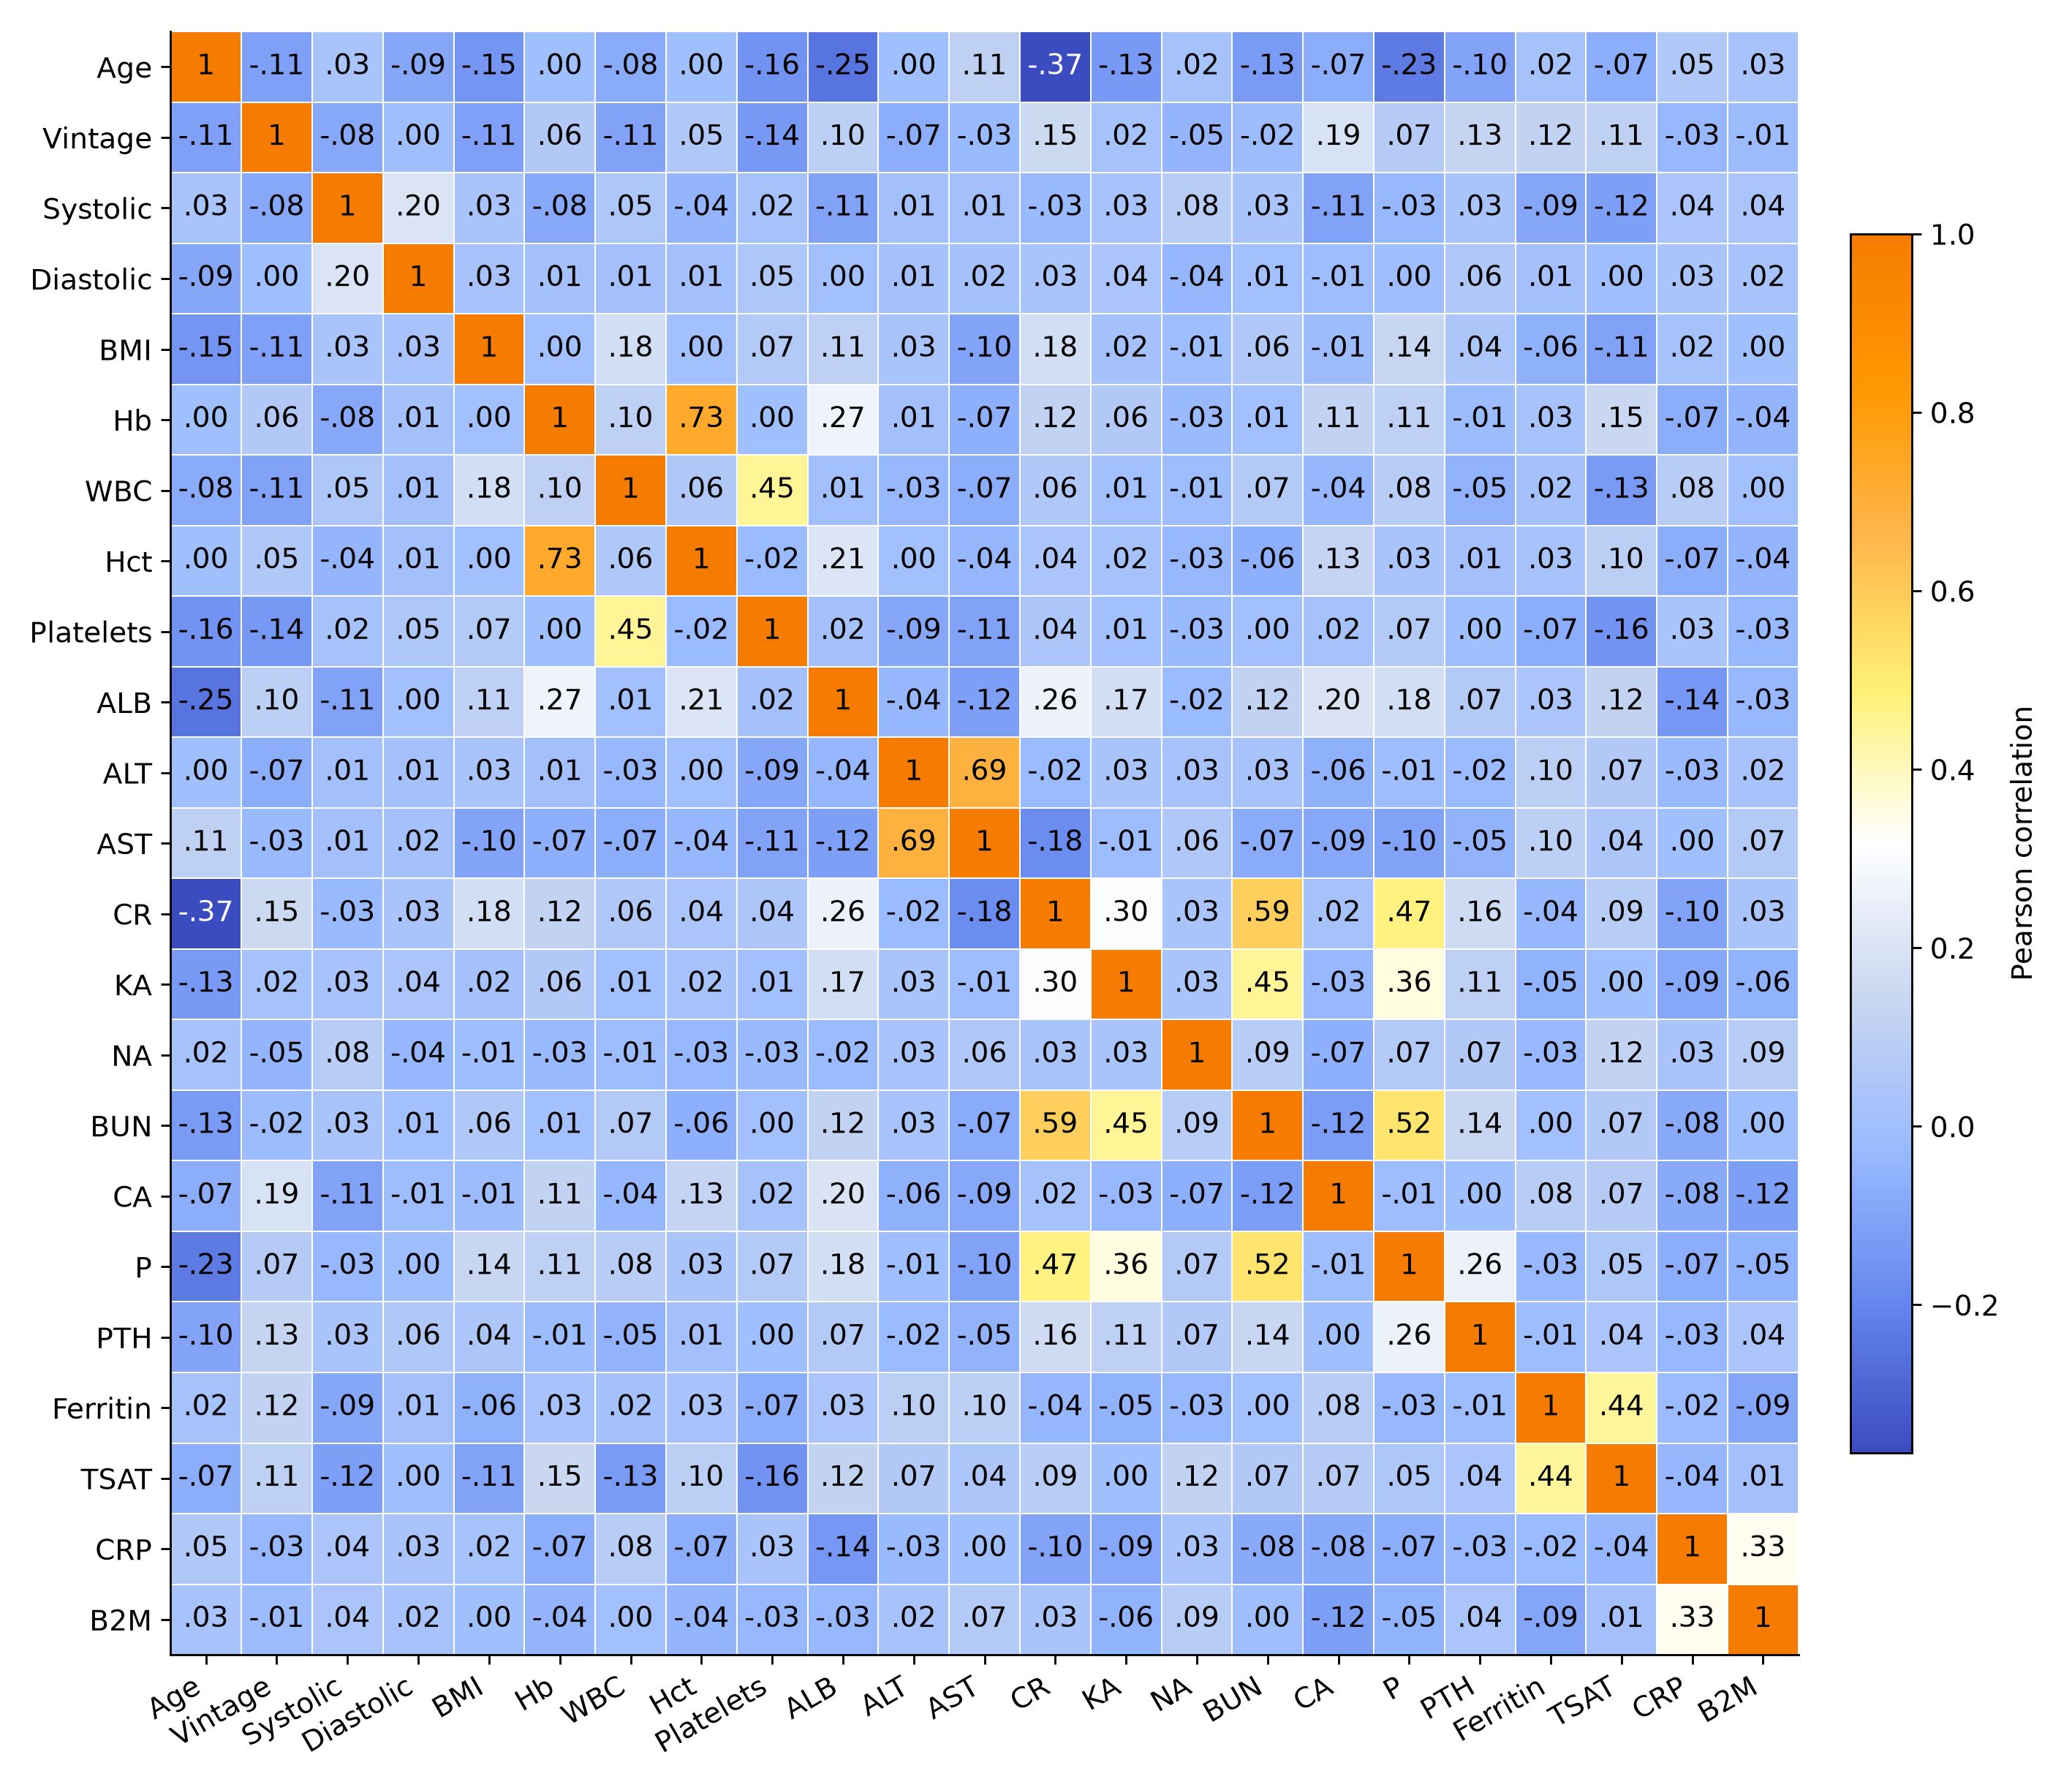

In [83]:
# Display Figure 2 from this analysis run.
figure_path = figures / "Figure2.png"
assert figure_path.is_file(), "Run the figure-generation cells above first."
display(Image(filename=str(figure_path), width=900, embed=True))


<a id="figure3"></a>

##### Figure 3. Model discrimination and AVF F1 scores

Training and internal-holdout ROC curves for the five models, followed by AVF F1 scores at threshold 0.5. Training performance is descriptive. Average precision and class-specific performance are reported in Table S3.


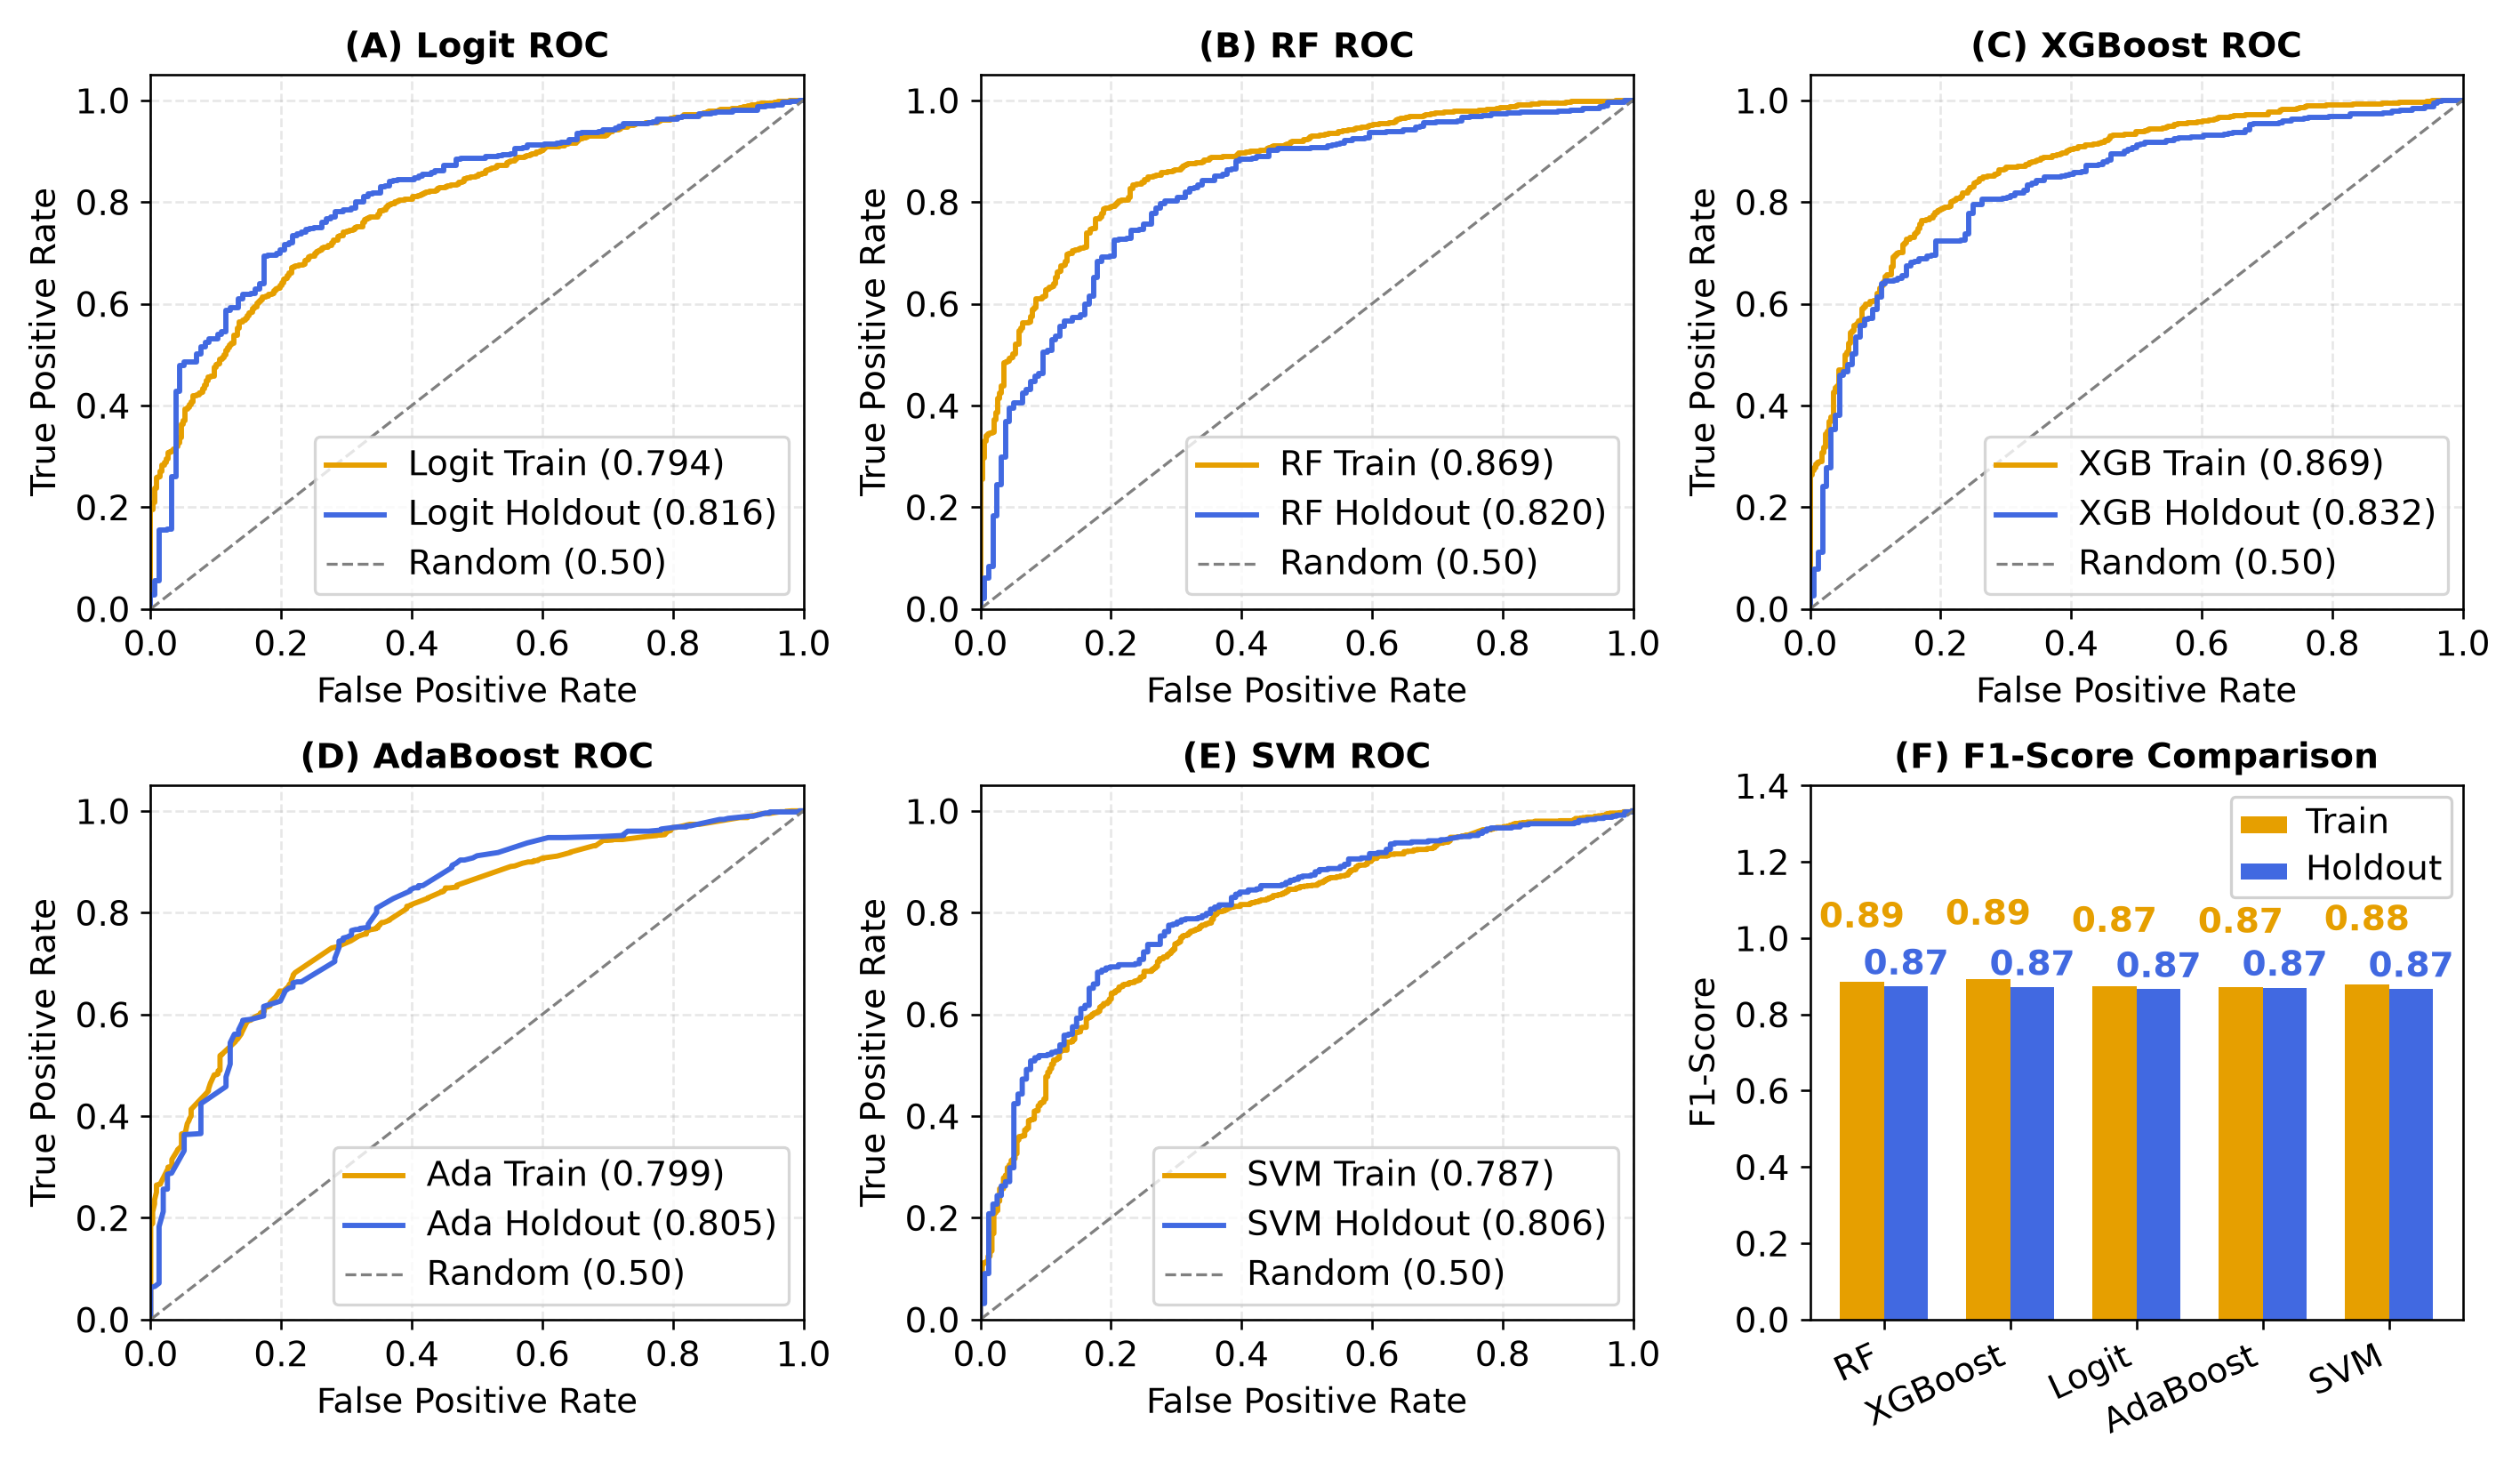

In [84]:
# Display Figure 3 from this analysis run.
figure_path = figures / "Figure3.png"
assert figure_path.is_file(), "Run the figure-generation cells above first."
display(Image(filename=str(figure_path), width=900, embed=True))


<a id="figure4"></a>

##### Figure 4. Model calibration

(A–E) Separate calibration panels for Logit, RF, XGBoost, AdaBoost, and SVM, with Brier scores and Wilson 95% intervals for observed AVF proportions. (F) Overlay of the same curves without intervals. All panels use the internal holdout. Calibration intercepts and slopes with bootstrap intervals are reported in Table S3.


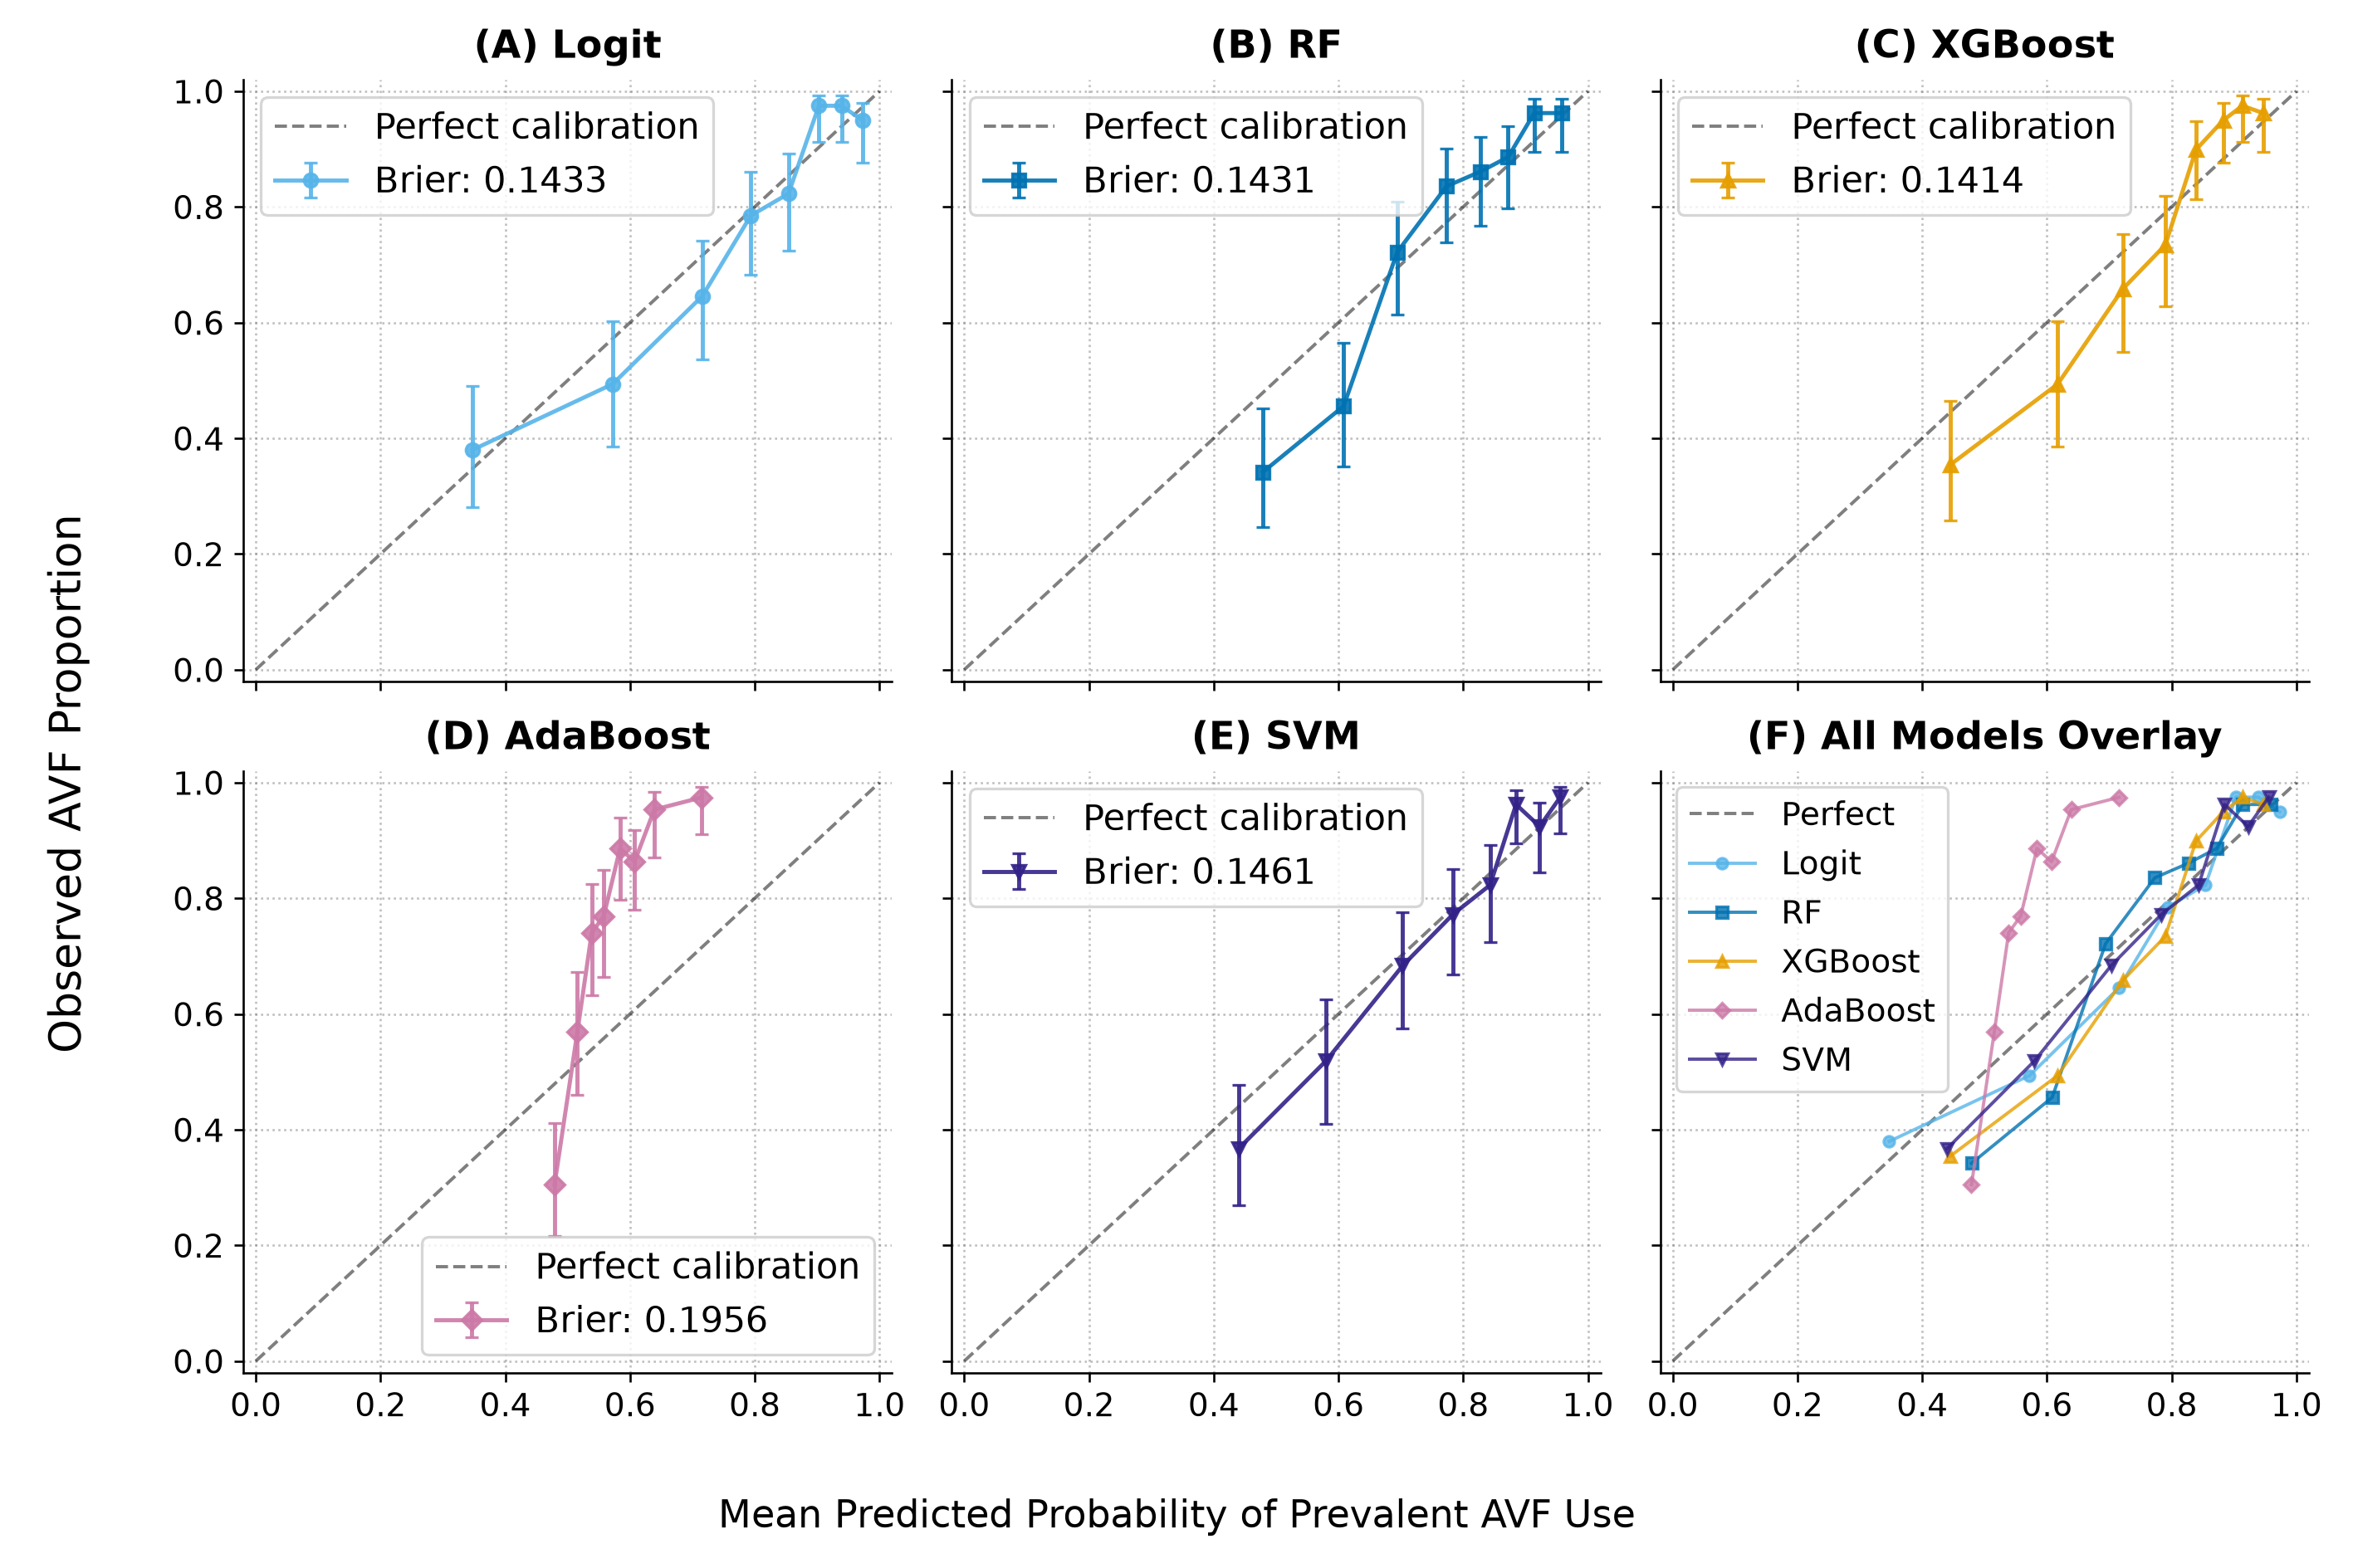

In [85]:
# Display Figure 4 from this analysis run.
figure_path = figures / "Figure4.png"
assert figure_path.is_file(), "Run the figure-generation cells above first."
display(Image(filename=str(figure_path), width=900, embed=True))


<a id="figure5"></a>

##### Figure 5. Random forest SHAP distribution

Grouped SHAP contributions across all holdout patients. Contributions describe the fitted model’s AVF probabilities.


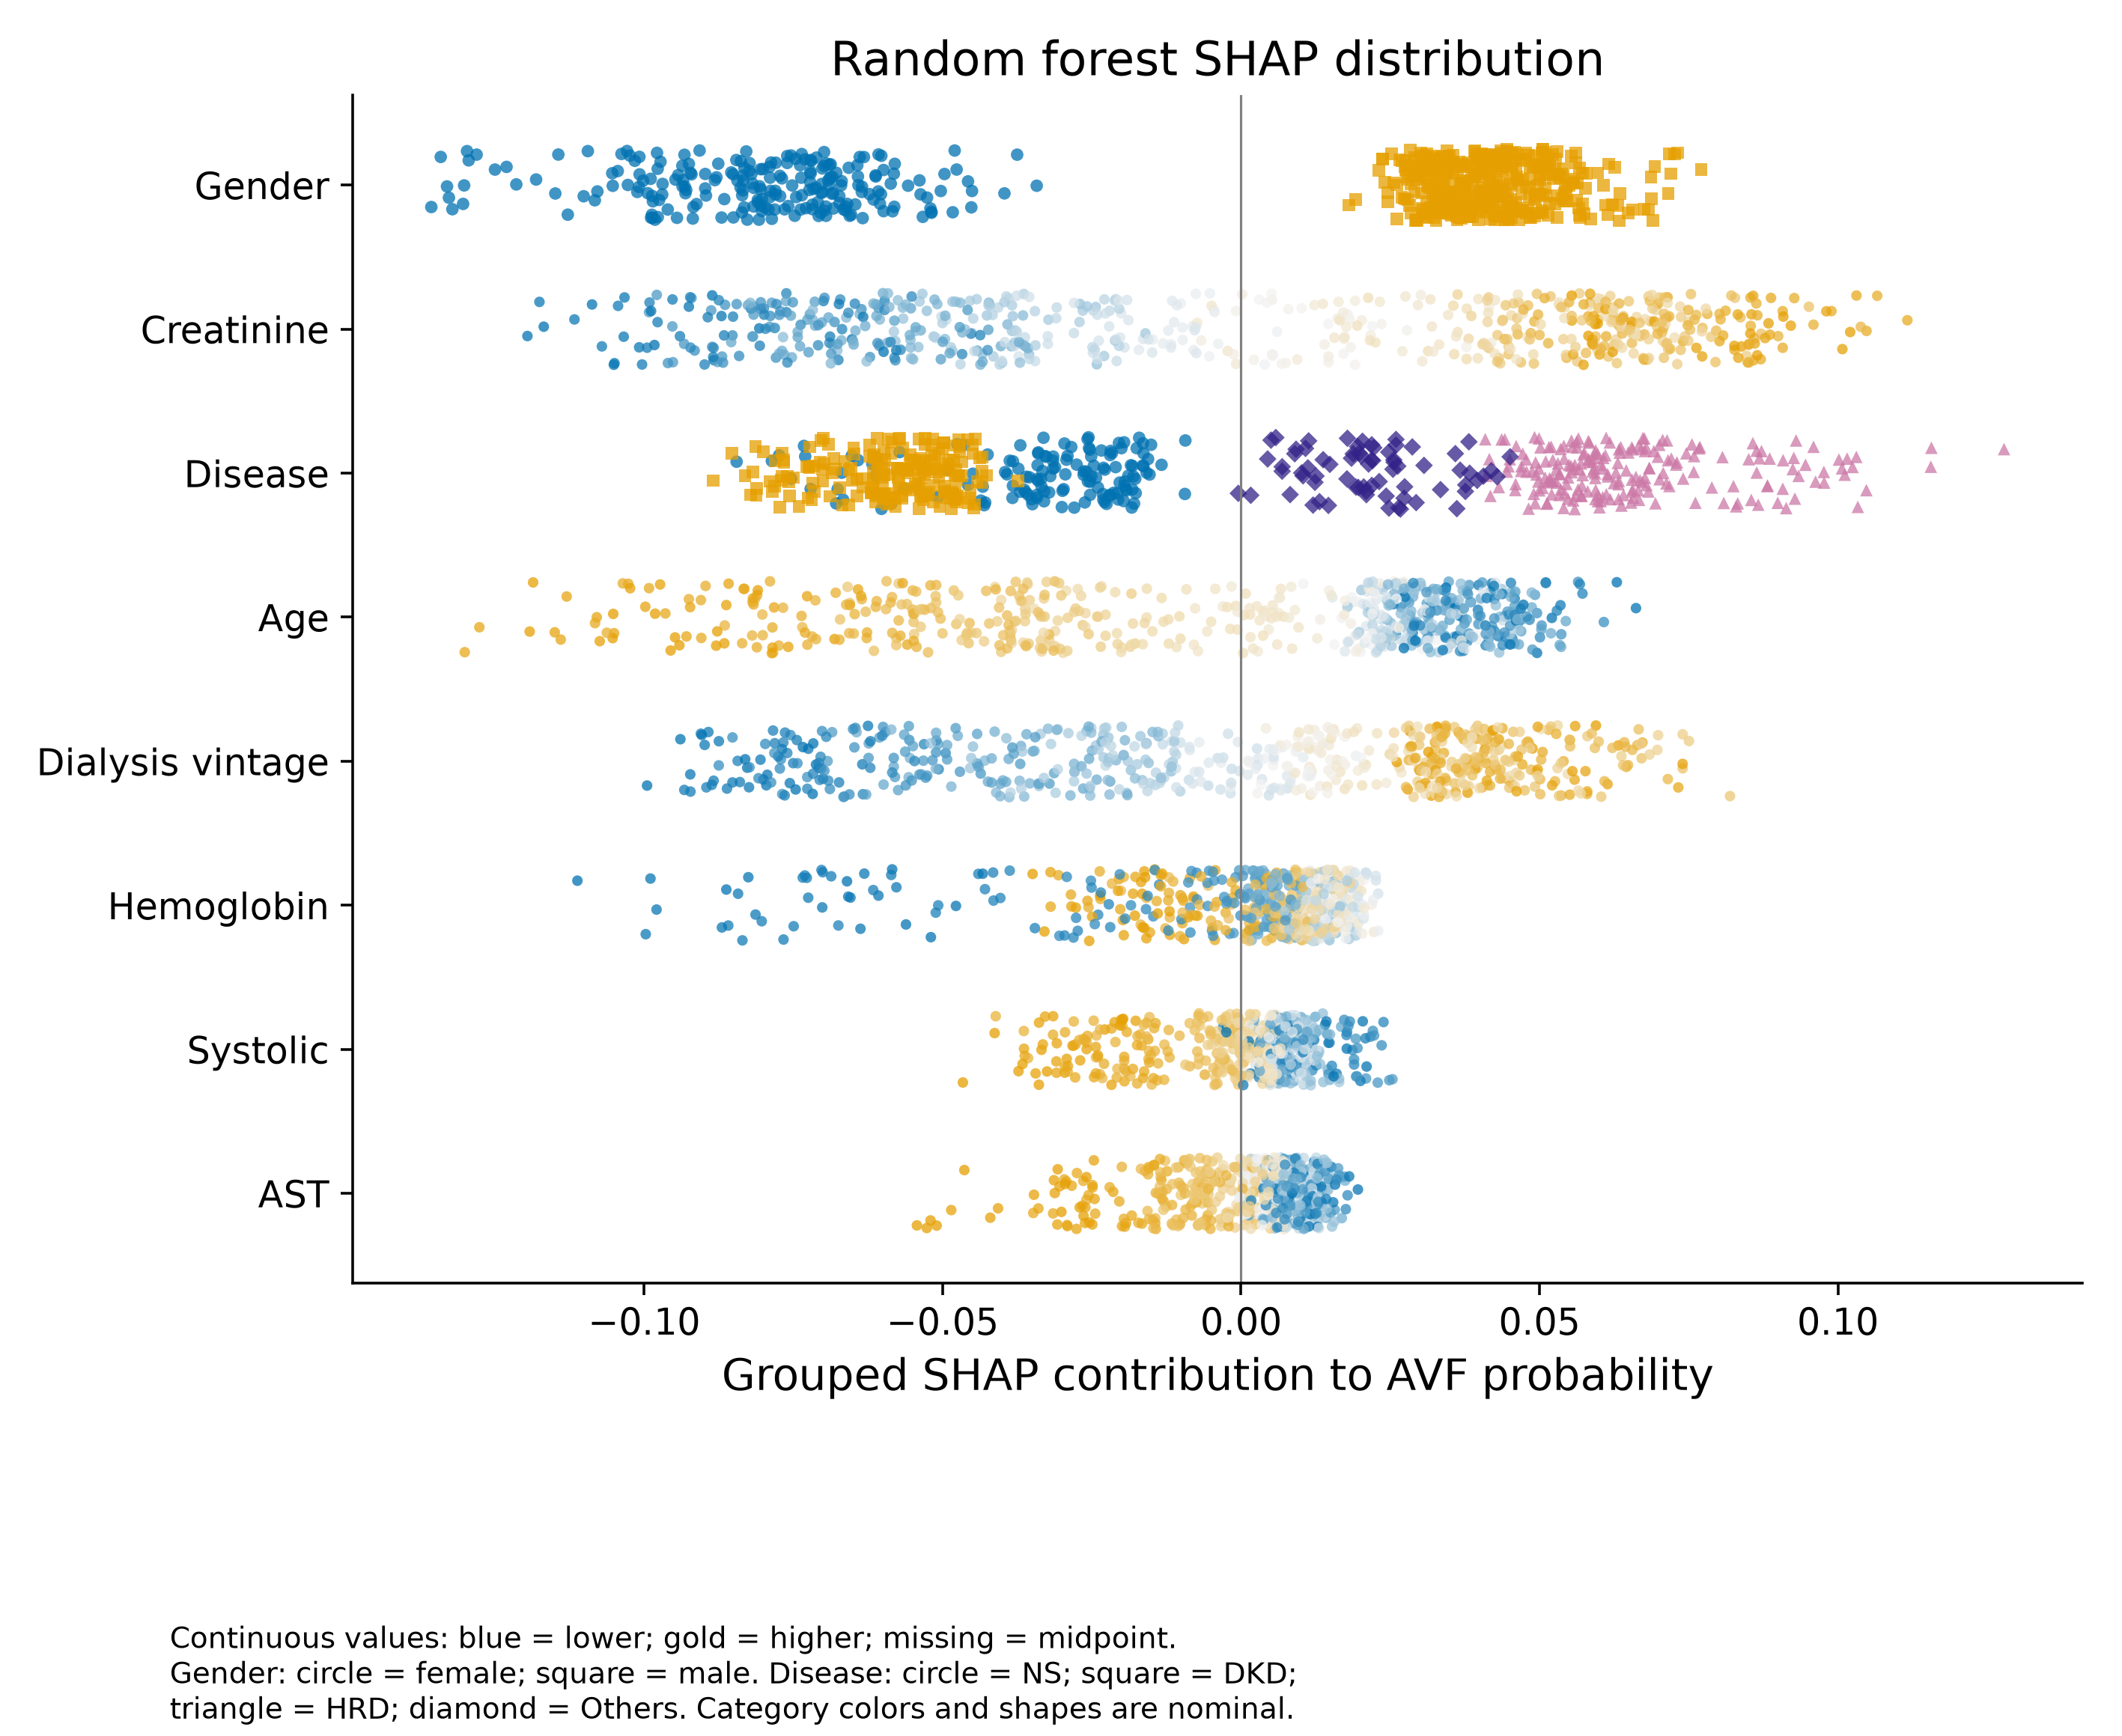

In [86]:
# Display Figure 5 from this analysis run.
figure_path = figures / "Figure5.png"
assert figure_path.is_file(), "Run the figure-generation cells above first."
display(Image(filename=str(figure_path), width=900, embed=True))


<a id="figure6"></a>

##### Figure 6. Exploratory predictive contributions and RF interactions

Paired AUC comparisons and leading RF interaction contributions. These are exploratory model findings and do not establish clinical interactions.


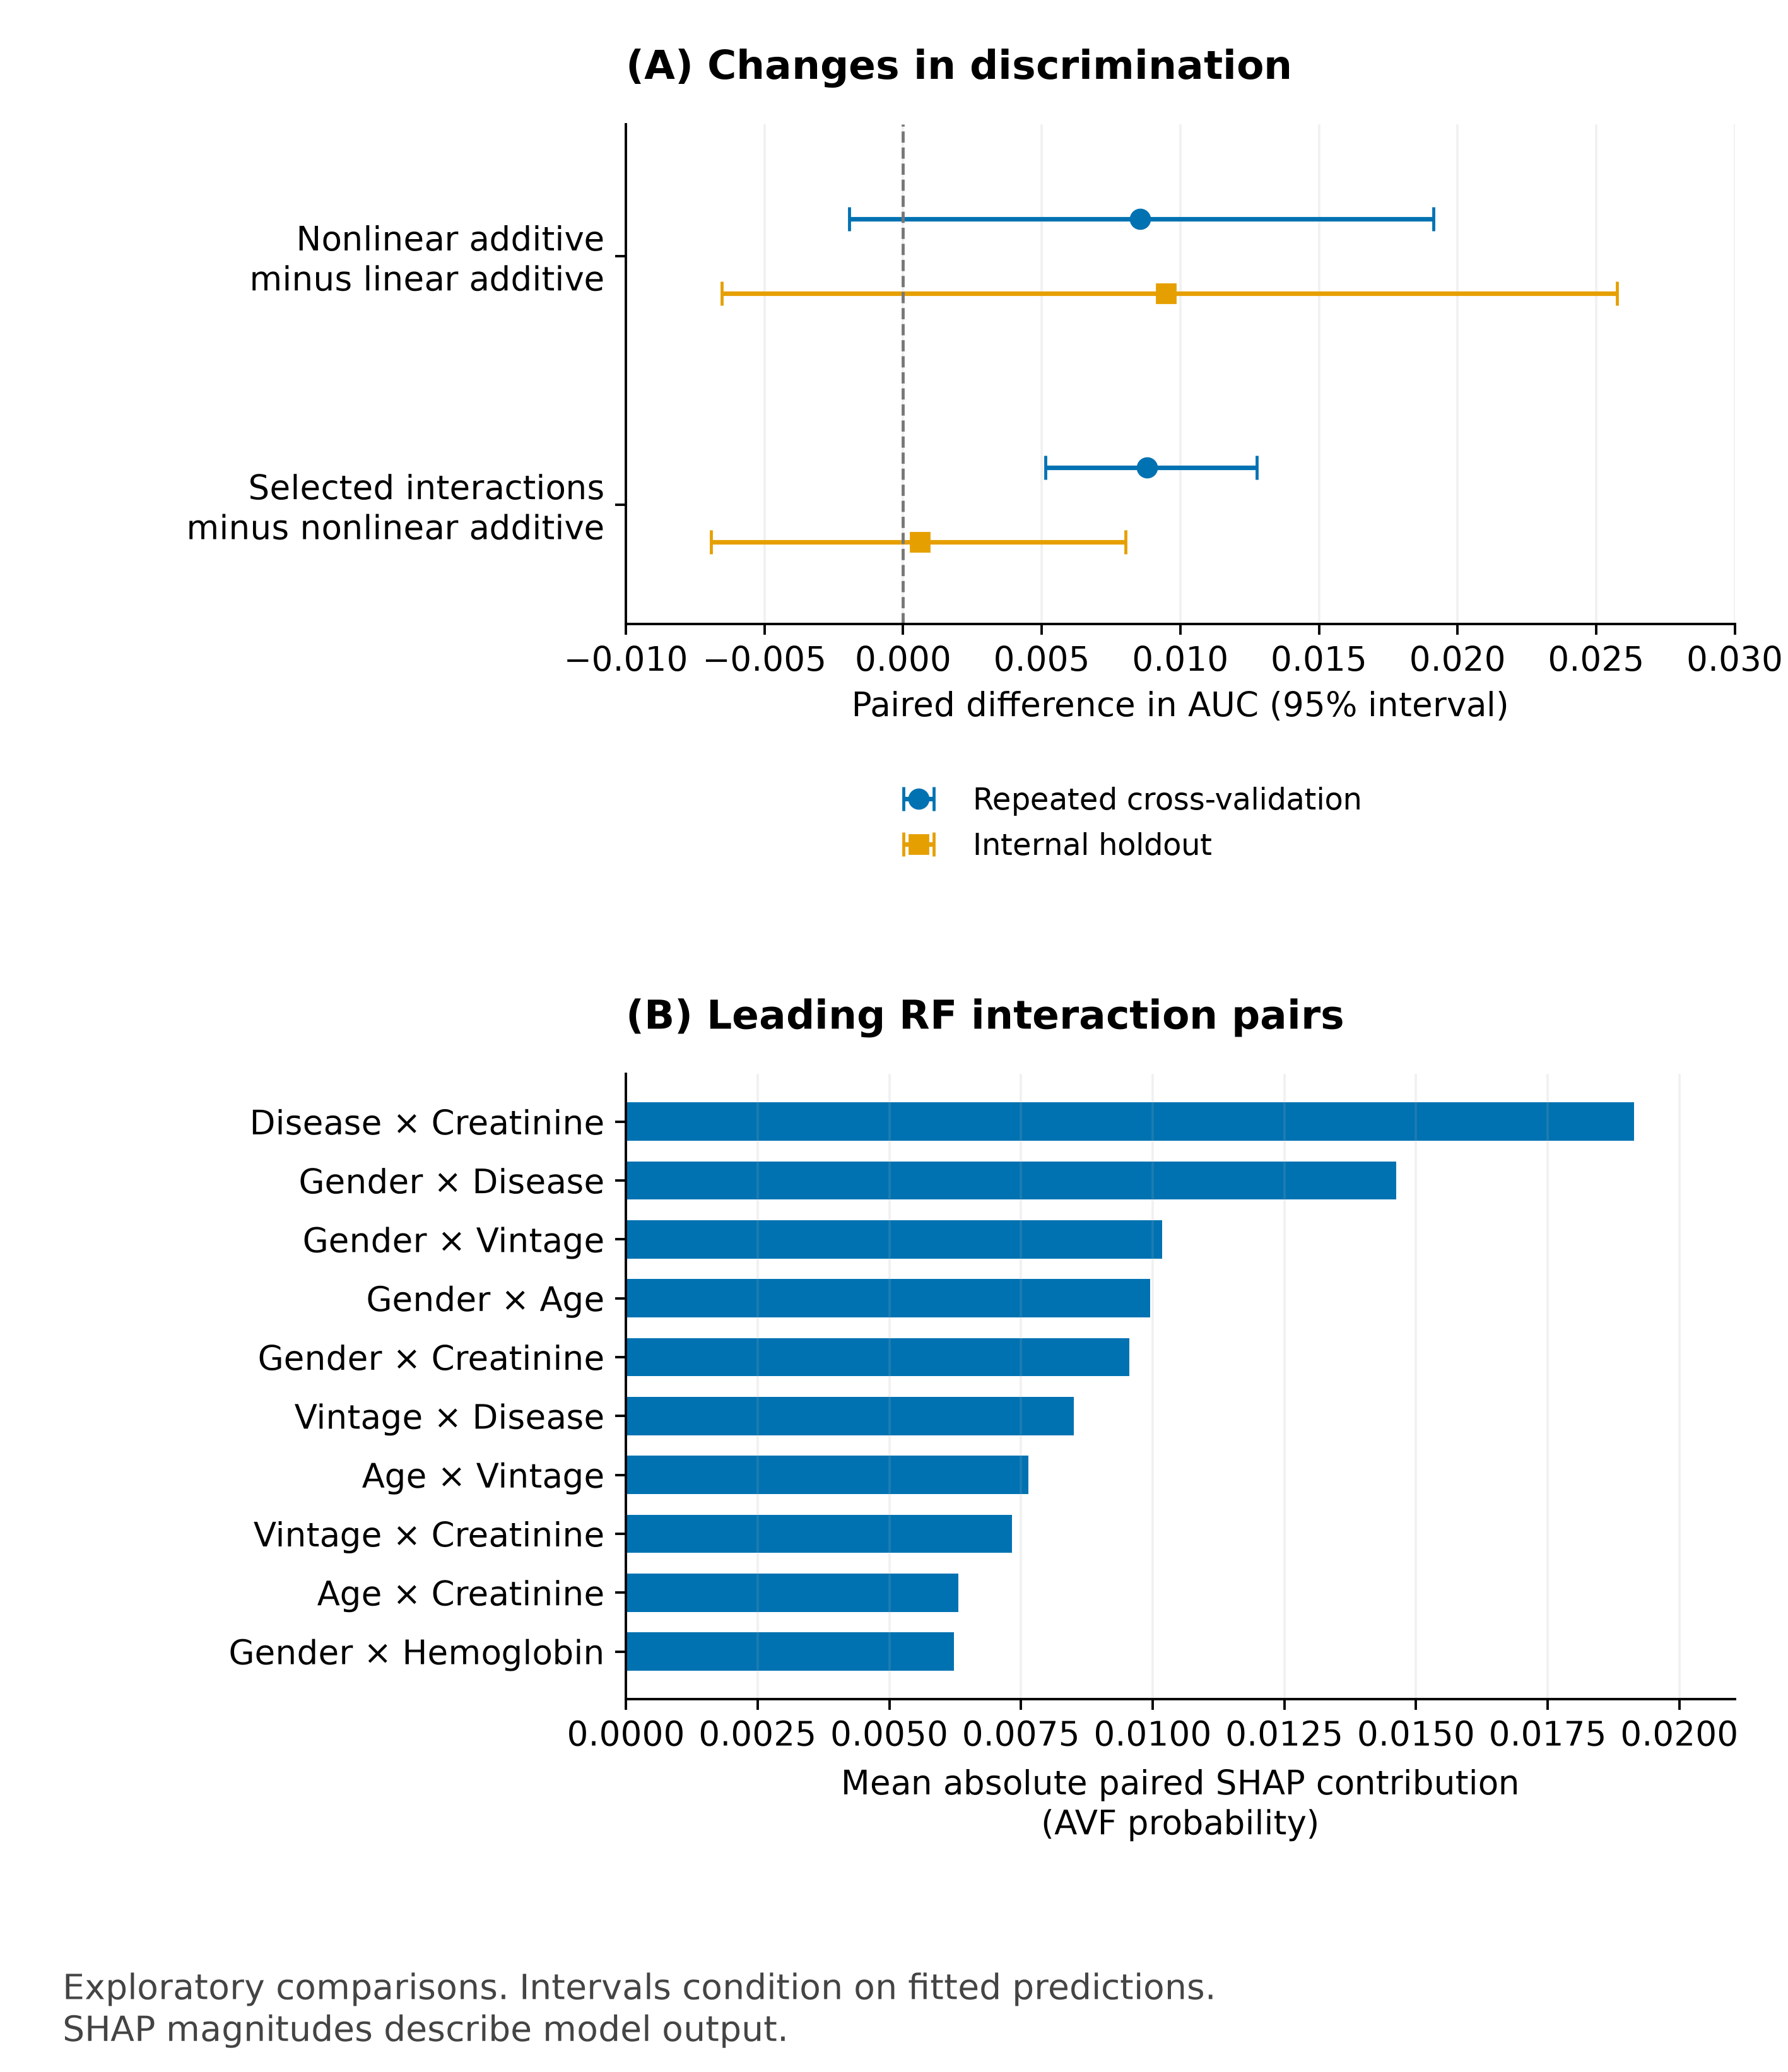

In [87]:
# Display Figure 6 from this analysis run.
figure_path = figures / "Figure6.png"
assert figure_path.is_file(), "Run the figure-generation cells above first."
display(Image(filename=str(figure_path), width=900, embed=True))


#### Supplementary figures


<a id="figures1"></a>

##### Figure S1. Random forest SHAP dependence patterns

Predictor values plotted against their SHAP contributions in the internal holdout.


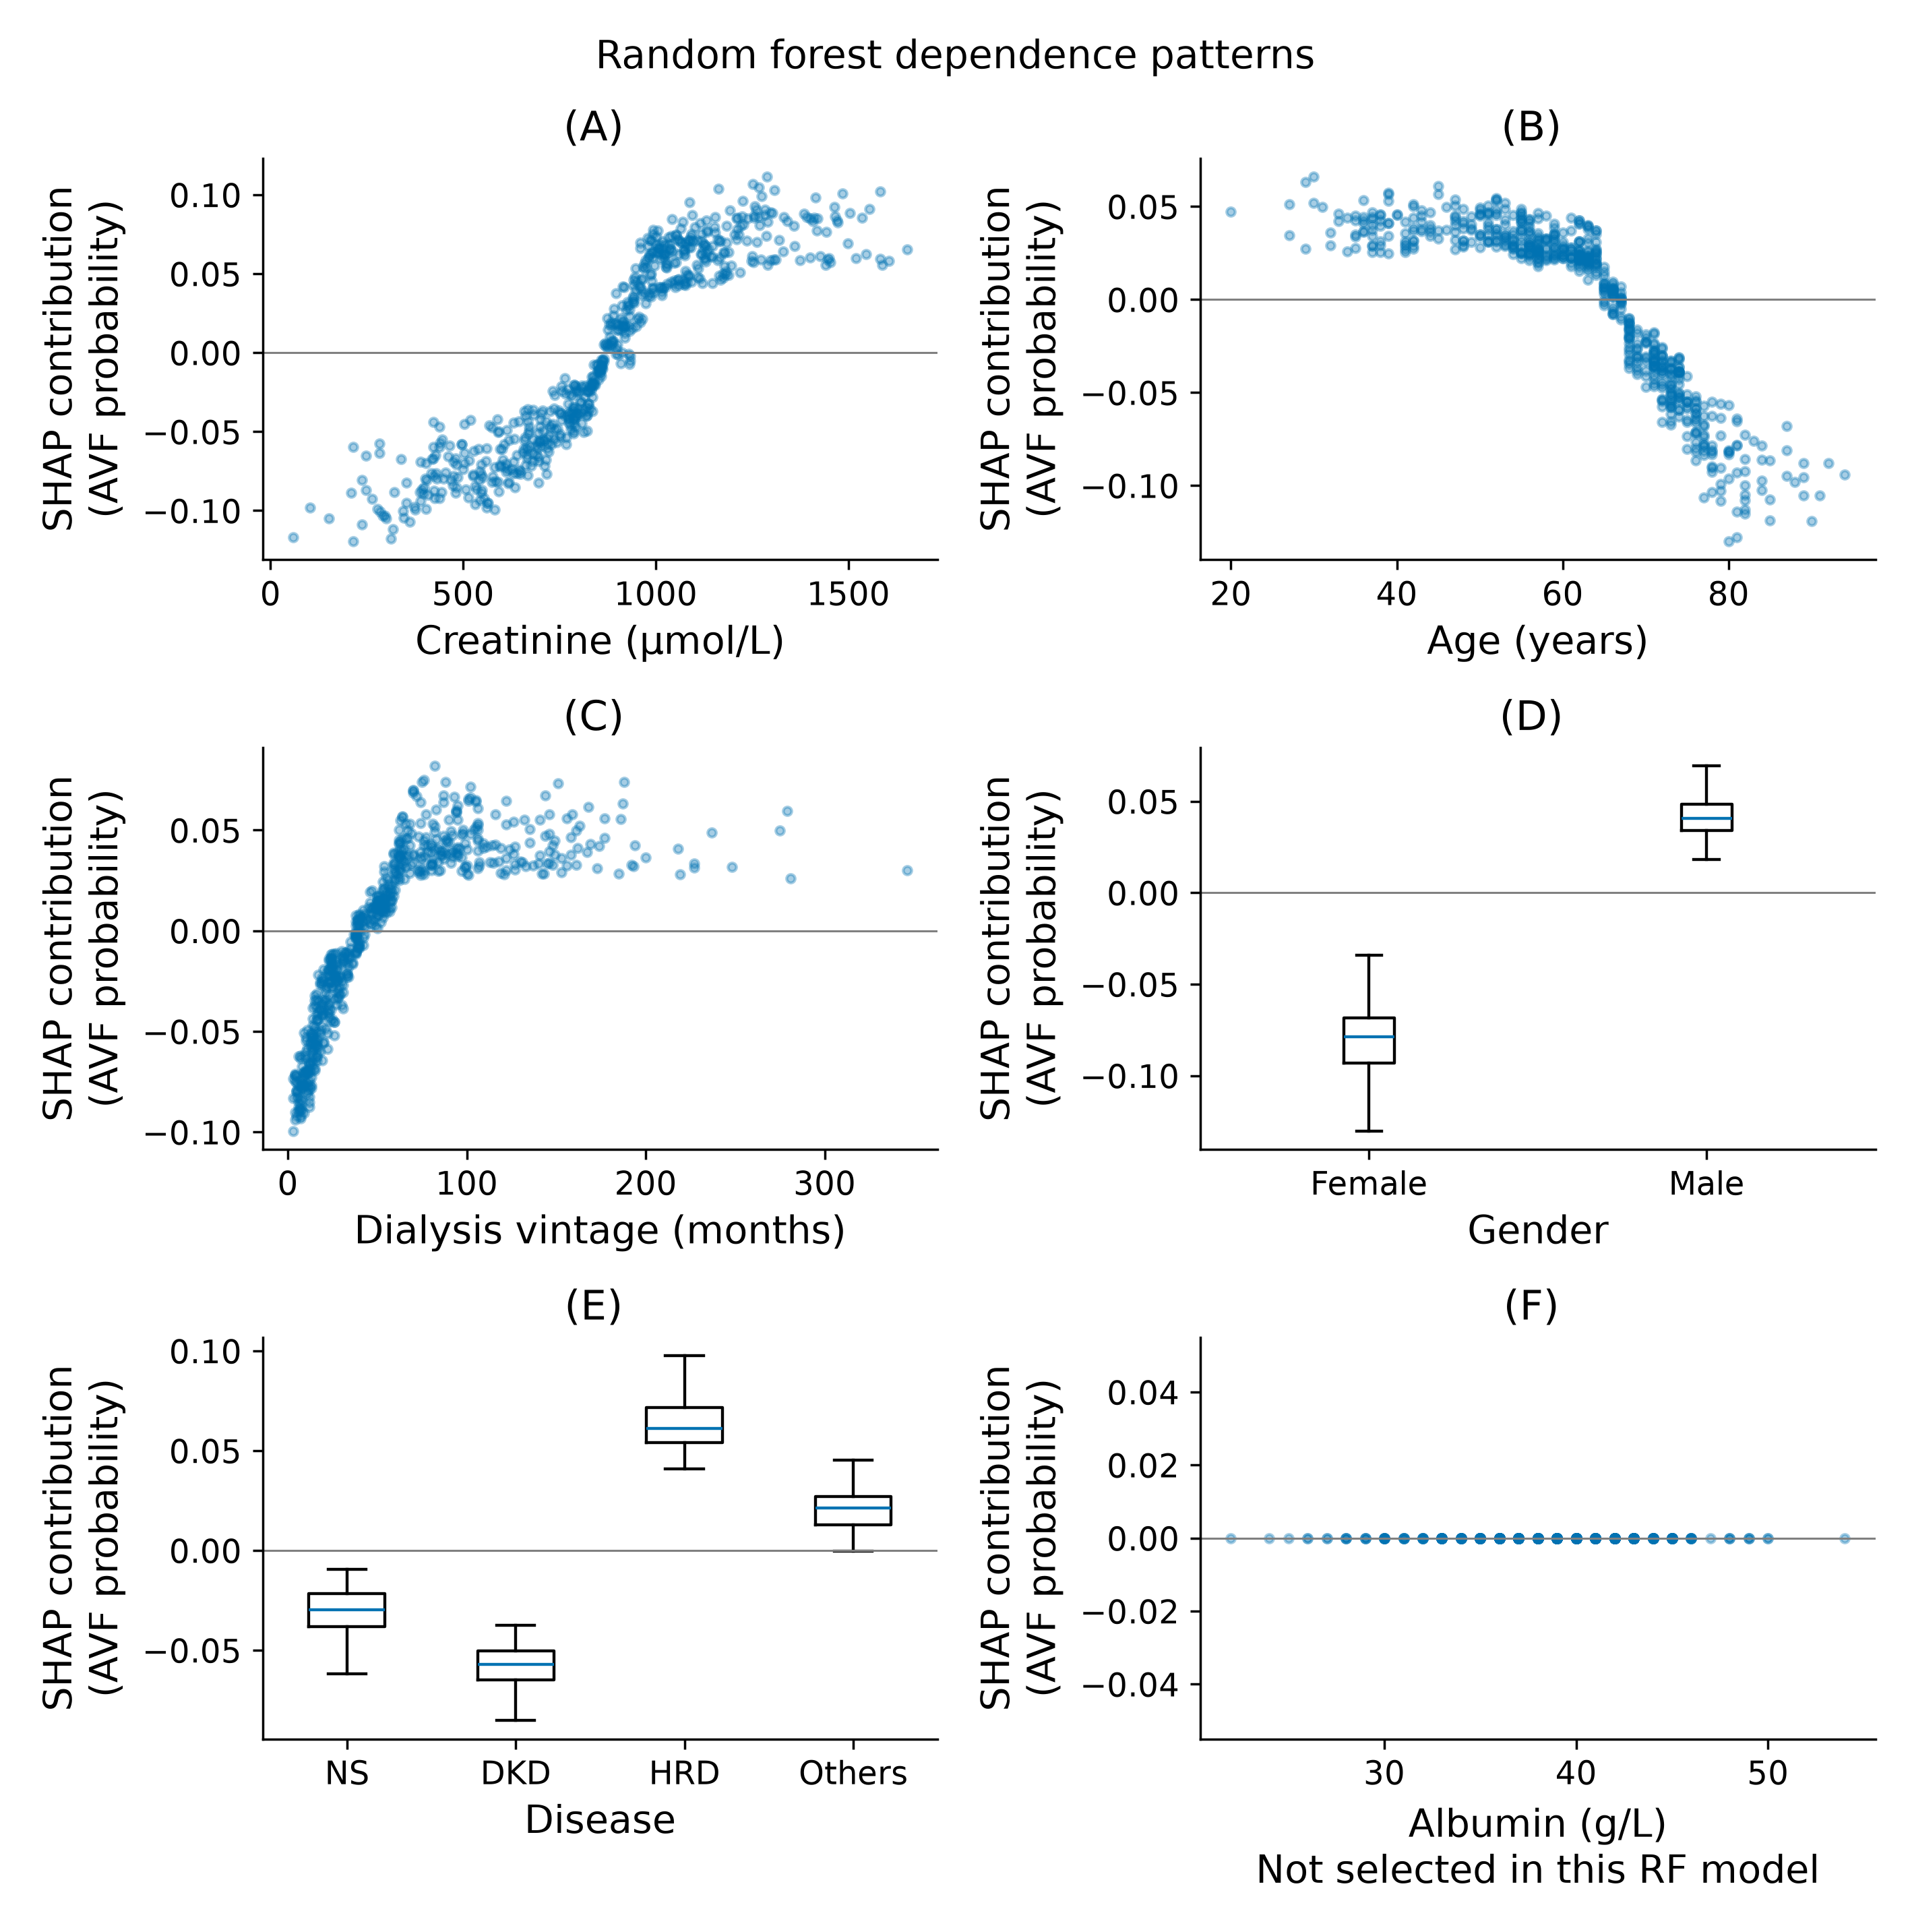

In [88]:
# Display Figure S1 from this analysis run.
figure_path = figures / "FigureS1.png"
assert figure_path.is_file(), "Run the figure-generation cells above first."
display(Image(filename=str(figure_path), width=900, embed=True))


<a id="figures2"></a>

##### Figure S2. Common probability-scale SHAP comparison

The five models are compared in AVF probability units using 160 sampled holdout patients.


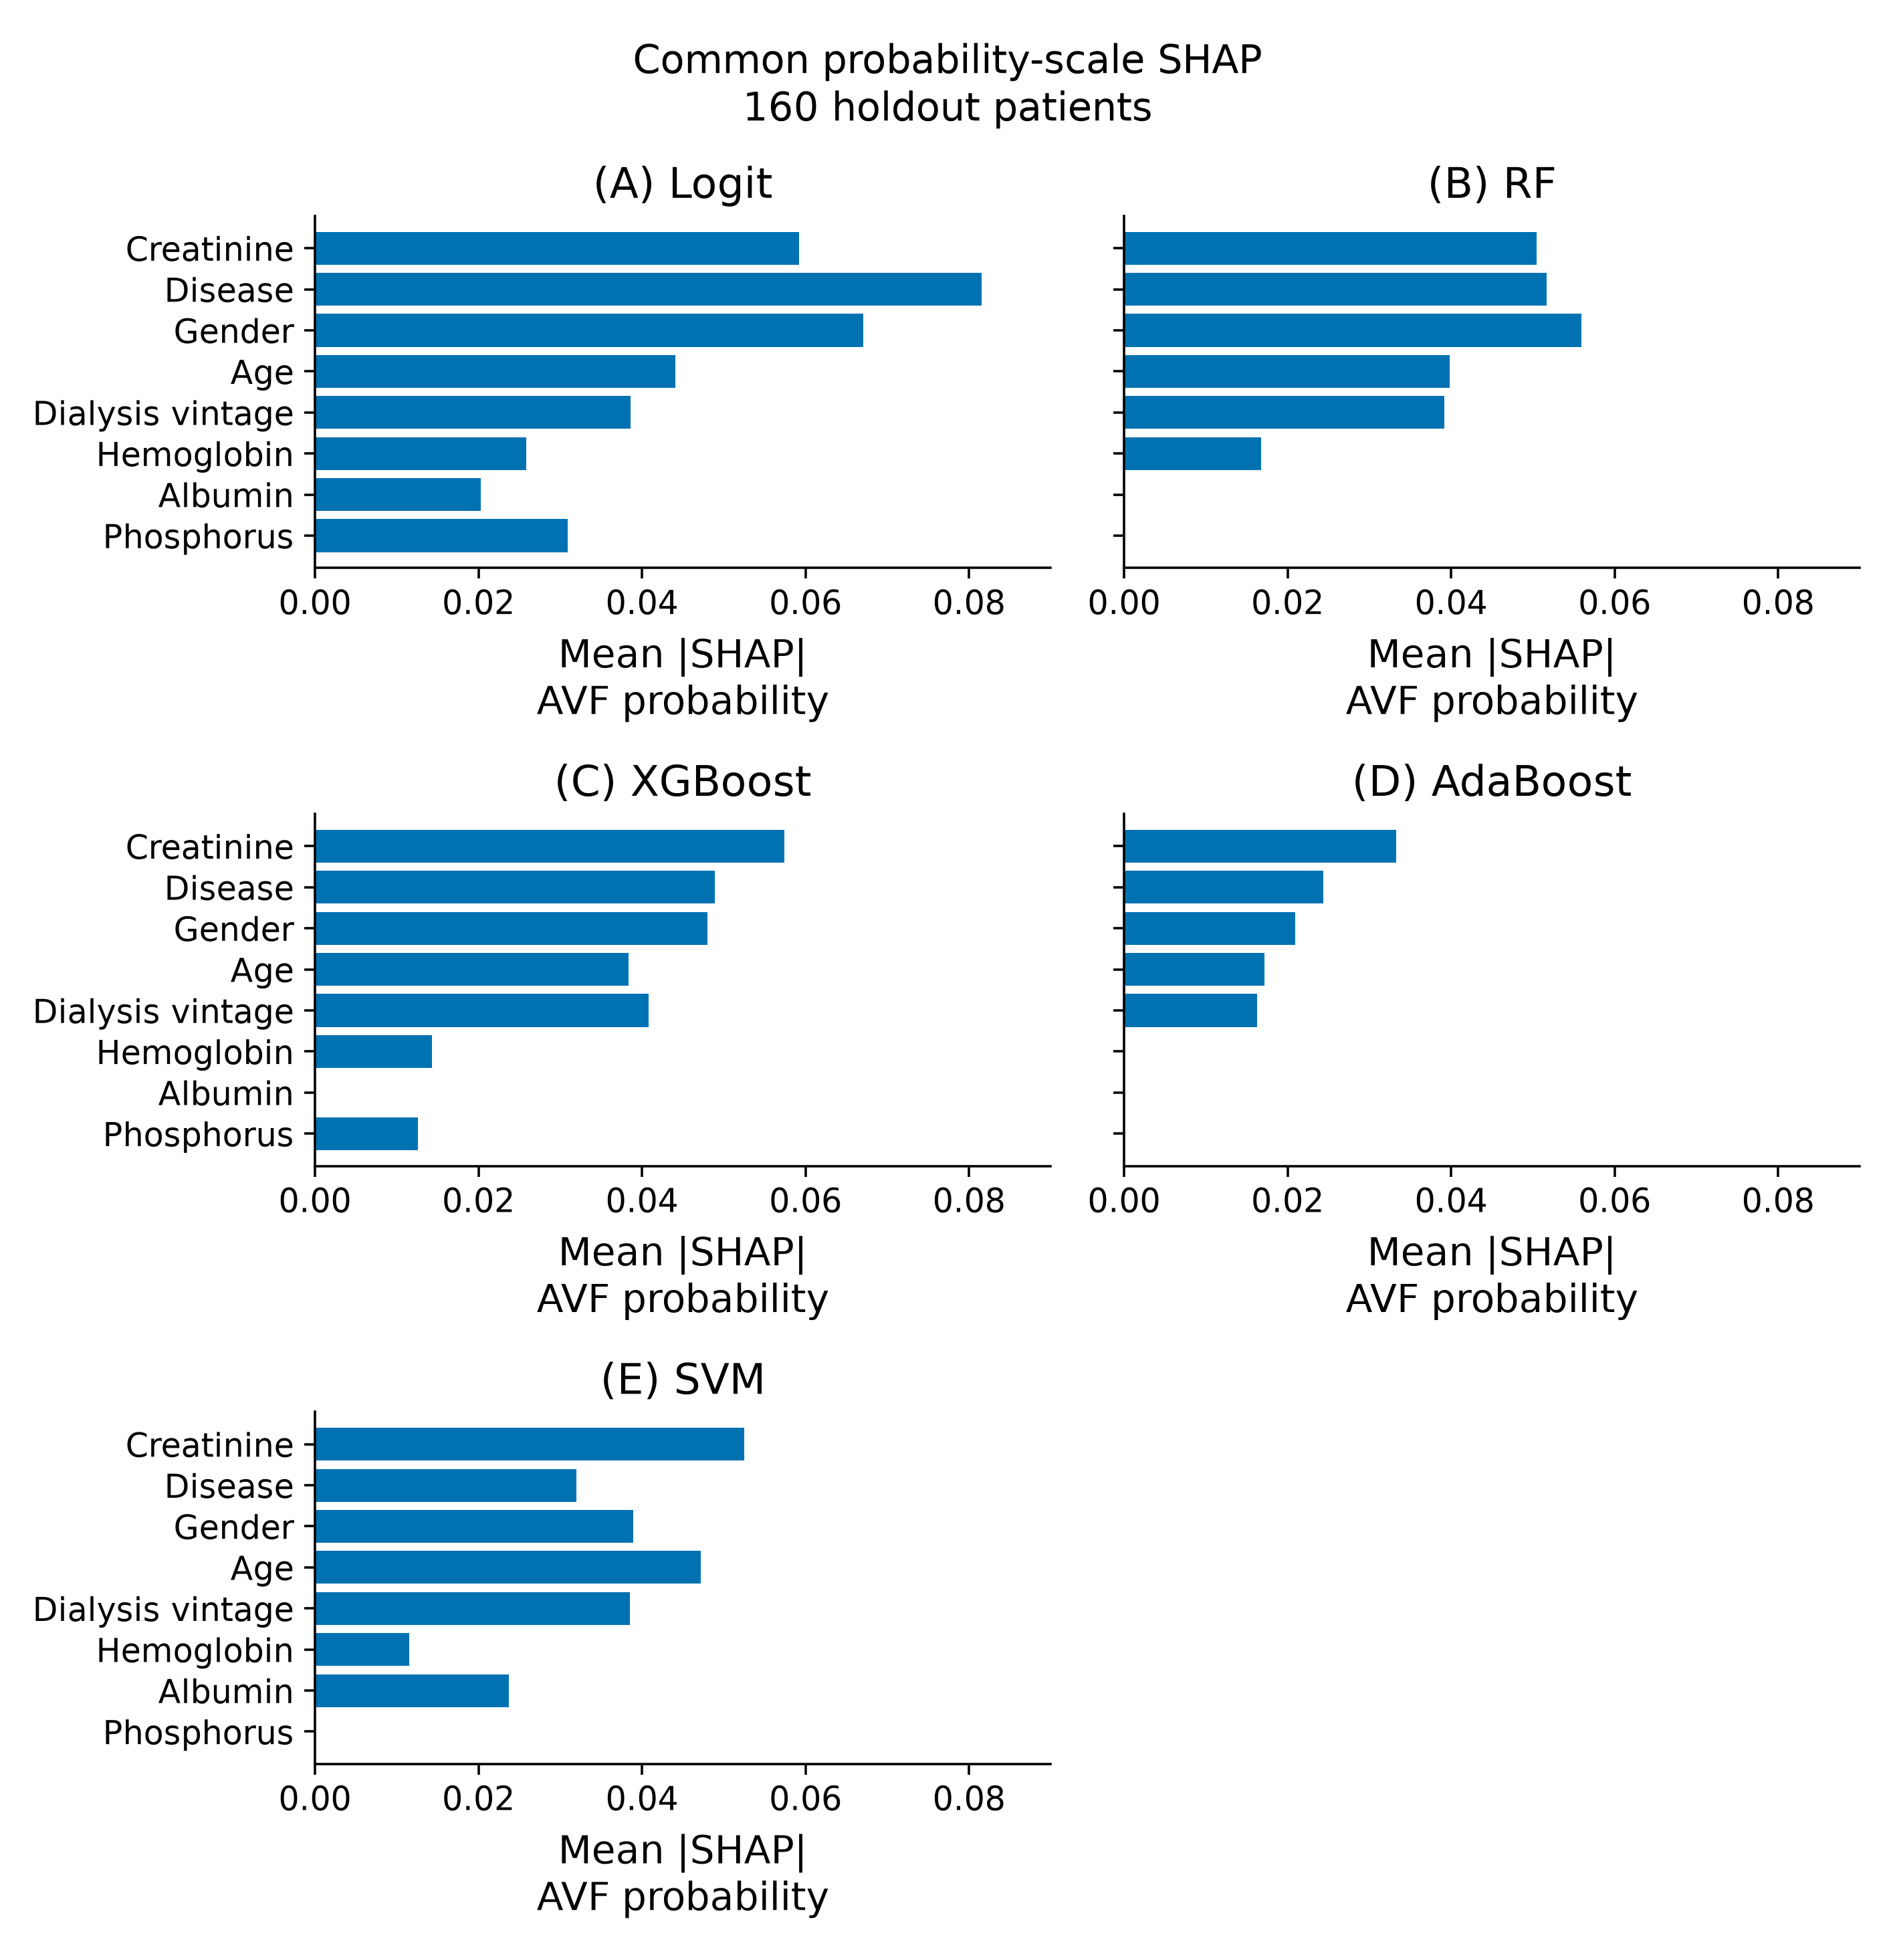

In [89]:
# Display Figure S2 from this analysis run.
figure_path = figures / "FigureS2.png"
assert figure_path.is_file(), "Run the figure-generation cells above first."
display(Image(filename=str(figure_path), width=900, embed=True))


## 14. Numerical checks

Check prediction agreement, SHAP additivity, grouping and symmetry, completeness of out-of-fold predictions, and matching nonlinear main-effect blocks. Calibration-bin counts and weighted mean probabilities are also checked. These checks assess computational consistency.


In [90]:
checks = []
for filename, n in [("native_checks.json", 5), ("common_checks.json", 15), ("cv_checks.json", 10), ("interaction_checks.json", 2)]:
    records = json.loads((e.OUT / filename).read_text())
    assert len(records) == n, (filename, len(records))
    errors = []
    for record in records:
        for key, value in record.items():
            if "error" in key:
                assert float(value) < 2e-5, (filename, key, value)
                errors.append(float(value))
    checks.append({"check": filename, "records": len(
        records), "max_error": max(errors, default=0)})
diagnostics = pd.read_csv(f6.OUT / "fit_diagnostics.csv")
assert len(diagnostics) == 48
design_checks = json.loads((f6.OUT / "checks.json").read_text())
assert design_checks["main_blocks_identical"] and design_checks["complete_oof_predictions"]
assert design_checks["convergence_warnings"] == 0
holdout = np.load(a.PRIVATE / "holdout_predictions.npz")
for name, g in pd.read_csv(a.OUT / "calibration_bins.csv").groupby("model"):
    assert g.n.sum() == len(a.te)
    overall = float(holdout[name].mean())
    assert np.isclose(np.average(g.mean_predicted_AVF_probability,
                      weights=g.n), overall, atol=1e-12)
report = {"completed": True, "dataset_file": str(DATA_CSV), 
          "elapsed_seconds": time.time() - STARTED, "fresh_run": True, "walkthrough_comparison": comparison_report["status"],
          "controlled_model_fits": 48, "all_shap_checks_passed": True, "checks": checks,
          "prior_dataset_benchmarks_used": False, "probability_summary_and_bins_verified": True}
(RUN_DIR / "output/reproduction_checks.json").write_text(json.dumps(report, indent=2))
display(pd.DataFrame(checks))
print("Numerical checks passed. Runtime (minutes):",
      round(report["elapsed_seconds"] / 60, 1))


,check,records,max_error
0,native_checks.json,5,2.622604e-06
1,common_checks.json,15,1.554312e-15
2,cv_checks.json,10,2.861023e-06
3,interaction_checks.json,2,6.785849e-07


Numerical checks passed. Runtime (minutes): 29.6


In [91]:
print("Analysis results")
display(pd.read_csv(a.OUT / "corrected_holdout_point_metrics.csv").round(4))
display(pd.read_csv(f6.OUT / "paired_differences.csv").query("metric=='AUC'").round(5))
print("Adjusted association tests:", json.loads(
    (a.OUT / "interaction_tests.json").read_text()))


Analysis results


,model,AUC,AP_AVF,AP_nonAVF,sensitivity,specificity,PPV,NPV,balanced_accuracy,F1_AVF,F1_nonAVF,macro_F1,Brier,calibration_intercept,calibration_slope
0,Logit,0.8159,0.9234,0.5548,0.9265,0.3462,0.8122,0.6067,0.6363,0.8656,0.4408,0.6532,0.1433,-0.0638,1.0210
1,RF,0.8200,0.9220,0.5813,0.9727,0.2179,0.7915,0.7234,0.5953,0.8728,0.3350,0.6039,0.1431,-0.0796,1.4847
2,XGBoost,0.8316,0.9305,0.5877,0.9622,0.2436,0.7951,0.6786,0.6029,0.8707,0.3585,0.6146,0.1414,-0.1051,1.4663
3,AdaBoost,0.8046,0.9179,0.5739,0.9517,0.2756,0.8004,0.6515,0.6137,0.8695,0.3874,0.6284,0.1956,0.8148,5.2786
4,SVM,0.8059,0.9212,0.5336,0.9496,0.2628,0.7972,0.6308,0.6062,0.8667,0.3710,0.6189,0.1461,-0.0708,1.2281
5,Training_prevalence_reference,0.5000,0.7532,0.2468,1.0000,0.0000,0.7532,NaN,0.5000,0.8592,0.0000,0.4296,0.1862,-0.0928,NaN


,evaluation,comparison,metric,difference,lo,hi
0,Repeated_CV,Nonlinear minus Linear,AUC,0.00855,-0.00194,0.01913
4,Repeated_CV,Interactions minus Nonlinear,AUC,0.00880,0.00514,0.01276
8,Repeated_CV,Interactions minus Linear,AUC,0.01734,0.00638,0.02794
12,Repeated_CV,RF minus Nonlinear,AUC,-0.00021,-0.01068,0.01011
16,Repeated_CV,RF minus Interactions,AUC,-0.00901,-0.01935,0.00127
20,Reused_holdout,Nonlinear minus Linear,AUC,0.00948,-0.00655,0.02576
24,Reused_holdout,Interactions minus Nonlinear,AUC,0.00059,-0.00694,0.00802
28,Reused_holdout,Interactions minus Linear,AUC,0.01007,-0.00534,0.02568
32,Reused_holdout,RF minus Nonlinear,AUC,-0.00384,-0.02416,0.01747
36,Reused_holdout,RF minus Interactions,AUC,-0.00443,-0.02428,0.01561


Adjusted association tests: {'linear_interaction_LR': 1.8102341903327215, 'linear_df': 3.0, 'linear_p': 0.6127103976658748, 'spline_interaction_LR': 11.286490356894546, 'spline_df': 9.0, 'spline_p': 0.25658152584362703, 'adjusted_design_rank': 8, 'adjusted_design_columns': 8, 'n': 2106, 'interpretation': 'Exploratory patient-independence analysis, no center adjustment or causal inference.'}


## 15. Interpretation

Figure 4 compares the mean estimated AVF probability within each calibration group with its observed AVF proportion. Calibration intercepts, slopes, and Brier scores complement these plots.

The controlled comparison is exploratory. The two interaction pairs were selected after examining prior SHAP results; penalty tuning does not erase this selection. Bootstrap intervals condition on fitted predictions and omit refitting, clustering, and selection uncertainty. Neither SHAP pairs nor controlled logistic contrasts demonstrate clinical effects or explain an RF advantage. Interpret the cross-validation and internal-holdout results together.

The current extract lacks center identifiers, access subtypes, and measurement dates. A separate source mapping and preparation audit are available. Center linkage, endpoint and measurement timing, final selection rules, and flagged hematocrit values still require verification. These data describe prevalent AVF use, not future maturation or failure.
